# Week 3：電氣量測與ADC基礎

日期：2026-09-23

> **完整備課版（含參考答案）**：本版將Discussion題目、完整解答與實測案例集中在同一本。
> 第13.5、13.6、13.8、13.9節為參考解答；學生發布前須另確認答案的公開範圍，不直接視為無答案學生版。

本週延續Week 2已完成的板卡、Upload、Serial、GPIO4按鈕輸入與GPIO5輸出命令，
開始回答一個新的問題：**我們看到的程式狀態或電表數字，如何成為可以支持判斷的
實體證據？**

共同實驗使用ESP32電源腳、GPIO5測試輸出、KY-018，以及必買電阻包中的1 kΩ與10 kΩ各一顆。
先從KY-018板上的固定電阻`R1`與光敏電阻建立概念，再親手搭兩顆固定電阻的分壓電路，
比較交換上下位置前後的電壓；不要求另外購買5 kΩ電阻。
DHT11、光線門檻、感測有效／無效分類與兩種感測器整合留到Week 4。

> **GPIO profile安全閘門**：本頁兩支程式目前以`-1`表示尚未公布的腳位。上課前
> 由教師依`docs/hardware/hardware_state.md`公布已通過實測的`PIN_TEST_OUTPUT`與`PIN_LIGHT`。
> 未公布所需GPIO時，不進行該GPIO的接線或Upload，只閱讀與Verify；不自行猜腳位。
> 已確認模組供電腳位後，單獨用電表量S相對GND不需要ADC profile；此時S不接GPIO。


## 一、Unit Overview

### 教學目標

完成本單元後，學生應能：

1. 選擇適合的萬用電表（multimeter）功能與量程（range），記錄電阻（resistance）或直流電壓（DC voltage），並註明量測位置與單位。
2. 用本單元實際量測的線路解釋電壓（voltage）、電流（current）、電阻、接地（ground）、閉合迴路（closed circuit）與短路（short circuit）。
3. 以接地腳位（GND）為參考點，量測3.3伏特供電腳位（3V3）、通用輸入輸出腳位（GPIO）的低邏輯準位（LOW）與高邏輯準位（HIGH）；觀察重設（reset）後的啟動命令，並辨認已驗證課程板卡上的5伏特外部輸入腳位（5Vin）。
4. 區分軟體輸出命令（output command）與實體電壓量測證據。
5. 上電前辨認課程光敏電阻模組（KY-018 photoresistor module）的供電、接地與訊號腳位，並透過逐步計算解釋其分壓（voltage division）行為。
6. 在遮光與室內光兩種條件下，重複收集類比數位轉換器（ADC）的原始讀值（raw reading），說明這些資料能證明與不能證明的事項。
7. 以操作條件、電表量程、量測位置、數值、單位、重複量測證據與明確限制，支持量測結論。
8. 使用1 kΩ與10 kΩ固定電阻（fixed resistor）各一顆建立分壓電路（voltage divider），預測並量測輸出，解釋交換上下方電阻位置的影響。

### 教學內容

本單元將電氣量測作為建立證據的過程。學生會用自己的萬用電表（multimeter）觀察線路，將電壓（voltage）、電流（current）、電阻（resistance）、接地（ground）、閉合迴路（closed circuit）與短路（short circuit）連結到實際結果。學生會比較KY-018模組上既有的固定電阻（fixed resistor）與光敏電阻（photoresistor），建立分開的接地（GND）及3.3伏特（3V3）量測點，區分指定板卡的5伏特外部輸入腳位（5Vin）與USB供電時的輸出，並查驗通用輸入輸出腳位（GPIO）的軟體狀態是否對應實體的低邏輯準位（LOW）與高邏輯準位（HIGH）電壓。接著以光敏電阻模組（KY-018 photoresistor module）作為會變動的類比訊號源（analog source），在遮光與室內光下比較訊號電壓與12位元類比數位轉換器（12-bit ADC）的原始讀值（raw reading），重複收集資料，而不直接將讀值視為伏特（volt）、勒克斯（lux）或已校正的光線狀態。收尾討論以實際線路及資料為依據，探討「數字較大是否一定代表較亮」。學生也會交換兩顆固定電阻的位置，比較預測與實測的輸出電壓，檢查自己對分壓（voltage division）的理解。

### 核心實驗流程

| 階段 | 開始前狀態 | 操作 | 完成條件 |
|---|---|---|---|
| [A. 電表準備](#w3-meter) | 電表未接電路 | 分辨插孔、功能與量程 | 能說出目前要量什麼及為何選此檔位 |
| [B. KY-018斷電電阻](#w3-resistance) | ESP32與模組均未供電 | 比較`R1`與光敏電阻路徑 | 能區分固定與隨光線改變的電阻 |
| [C. 電源測試點](#w3-test-points) | USB拔除 | 建立PGND、P3V3與TPO並查低阻抗錯接 | 三個測試點可追溯且不同功能點未持續蜂鳴 |
| [D. 電源與方向](#w3-supply) | 測試點通過斷電檢查 | 量3V3相對GND；辨認5Vin與IN-OUT | 電壓紀錄完整，且不把5Vin誤當USB 5V輸出 |
| [E. GPIO電壓](#w3-gpio) | GPIO5不接負載 | 自動切換LOW／HIGH，並觀察Reset後的啟動命令 | LOW／HIGH有電表證據；Reset有Serial命令證據 |
| [F1. KY-018訊號電壓](#w3-divider) | USB拔除且模組供電腳位已確認，S不接GPIO | 供電後用電表觀察室內光、遮光與移開遮光物 | 有S相對GND的三筆電壓與變化方向 |
| [F2. KY-018原始值](#w3-adc-concept) | 完成F1，USB拔除且ADC profile已公布 | 建立S測點，換上ADC程式後讀取raw | 遮光與室內光各有電壓、10筆raw與控制條件 |
| [G. Discussion](#w3-discussion) | 完成兩種光線的紀錄 | 回答「數字變大，就代表光比較亮嗎？」 | 用分壓接法、兩組資料及限制支持結論 |
| [H. 固定電阻分壓](#w3-resistor-practice) | USB拔除，拆除KY-018與GPIO線 | 1 kΩ與10 kΩ各一顆搭分壓，斷電交換上下位置再量測 | 有兩種配置的預測、實測及比例解釋；不再重收光線或ADC資料 |

### 章節定位

[器材與先備](#w3-materials)｜[安全](#w3-safety)｜[電壓、電流、電阻例子](#w3-concepts)｜[電表讀值](#w3-meter)

[KY-018電阻](#w3-resistance)｜[電源測點](#w3-test-points)｜[供電量測](#w3-supply)｜[GPIO程式與量測](#w3-gpio)

[光敏分壓與S電壓](#w3-divider)｜[ADC原理與接線](#w3-adc-concept)｜[ADC程式與採樣](#w3-adc-practice)

[Discussion與解析](#w3-discussion)｜[1 kΩ／10 kΩ實作](#w3-resistor-practice)｜[排錯](#w3-troubleshooting)｜[完成與復原](#w3-finish)｜[空白紀錄表](#w3-records)

A至H是依序接續的實驗，連結用於定位，不是任選順序。F1的「室內光→遮光→移開遮光物」
只有兩種光線條件；最後一步是觀察回到原條件，不是新增第三種亮光測試。
每次改線都依該階段的斷電步驟進行；紙上示例、參考答案與實測紀錄分別保存其性質。


<a id="w3-materials"></a>

## 二、器材、分組與前置條件

| 品項 | 數量 | 本週用途 |
|---|---:|---|
| YD-ESP32-S3 Type-A V1.5／ESP32-S3-WROOM-1 N16R8 | 1 | 電源腳、GPIO與ADC |
| 400孔麵包板 | 1 | 建立分開的量測點與共用接點 |
| 公對母、公對公及母對母杜邦線 | 各數條 | 依端點形式完成連線 |
| KY-018光敏電阻模組 | 1 | 可隨光線改變的類比訊號 |
| 必買電阻包中的1 kΩ與10 kΩ固定電阻 | 各1顆 | 第13.7節分壓接線與上下位置交換 |
| 具通斷、電阻及低壓直流電壓功能的數位萬用電表 | 每組1台 | 斷電檢查與上電量測 |
| USB資料線與已完成Week 2設定的筆電 | 各1 | 供電、Upload與Serial |
| 現有不導電、不透光的紙或布 | 1份 | 遮光；不能壓彎引腳或碰動接線 |

每組1～3人。每組使用自己的萬用電表；1人組可向其他組共用，但兩組必須分開
保存數值、照片與判讀。操作電表者、固定表筆者及記錄者可以輪替，任何人都必須
能說明黑表筆、紅表筆、檔位與測點的作用。1人操作不必另買夾具；第10.10節
說明先安置導線、再手持表筆，並將遮光與量測分開進行的方法。

本週不使用DHT11、RGB、蜂鳴器、SG90、4AA電池盒或網路功能。

進入條件：能完成Week 2的Verify、Upload與115200-baud Serial Monitor；知道改線、
通斷與電阻量測前先拔除ESP32端USB。若這些條件尚未成立，先回到
[Week 2教材](../Week_02_ESP32_Hardware_Basics/week2_main.ipynb)。

| Profile名稱 | 本頁目前值 | 上課時可使用的來源 |
|---|---:|---|
| `PIN_TEST_OUTPUT` | `-1` | 教師公布的指定板卡實測紀錄 |
| `PIN_LIGHT` | `-1` | 教師公布的指定板卡ADC實測紀錄 |


<a id="w3-safety"></a>

## 三、安全規則：先決定量什麼，再碰電路

### 三種量測不可混用

| 要量的量 | 電路是否供電 | 黑表筆 | 紅表筆 | 本週使用功能 |
|---|---|---|---|---|
| 通不通 | 完全斷電 | `COM` | `VΩmA` | 通斷蜂鳴／continuity |
| 電阻多大 | 完全斷電 | `COM` | `VΩmA` | `Ω`及合適量程 |
| 兩點電壓差 | 必須上電 | `COM` | `VΩmA` | 直流電壓`V⎓ 20` |

本週**不量電流**，紅表筆不插`10A`孔，也不把旋鈕轉到`A⎓`或mA檔。電流檔內部
阻抗很低；如果像量電壓一樣把兩支表筆跨接在3V3與GND，電表本身可能形成短路。
照片上的`10A`是電流插孔與上限標示，不是`10V`。

### 改線前的固定順序

1. 關閉Serial Monitor只會停止畫面，不會切斷USB電力。
2. 從ESP32端拔除USB。
3. 確認`PWR`燈熄滅。
4. 電表轉到`OFF`並移開表筆。
5. 才能插、拔或移動任何杜邦線、模組或電阻。

直流電壓量測必須上電時，黑表筆保持穩定接觸GND測試點，紅表筆一次只碰一個目標點。
穩定接觸不等於一定要使用夾具；可依第10.10節使用已分開安置的延長測點。
表筆尖端若可能滑到相鄰腳位，立即移開；需要調整導線時先拔USB，不勉強量測。


<a id="w3-concepts"></a>

## 四、從實物理解電壓、電流、電阻與GND

### 先分清三個問題：差多少、流多少、阻礙多少

| 要問的事情 | 物理量 | 常用符號 | 數字的單位 |
|---|---|---|---|
| 這兩個位置差多少電位？ | 電壓差 | V | V（volt，伏特） |
| 每秒有多少電荷通過這段路徑？ | 電流 | I | A（ampere，安培） |
| 這段路徑對電流的阻礙程度？ | 電阻 | R | Ω（ohm，歐姆） |

第一列的V可能是公式中的「電壓」符號，也可能是數字後的單位；`3.3 V`是在說
3.3伏特。電阻不是電流，Ω也不是伏特。電表一次選一種功能，不會同時告訴我們三者。
下文先用電壓尺建立兩點概念，再用一顆電阻練習如何算電流。

### 電壓`V`：推動電荷移動的兩點差異

`V`代表volt（伏特）。電表量到的不是「某一點自己有多少電壓」，而是紅表筆位置
相對黑表筆位置的電位差。電表顯示值的方向可以寫成：

```text
電表顯示值 = 紅表筆位置的電位 − 黑表筆位置的電位
```

例如黑表筆在0 V的GND、紅表筆在約3.2 V的GPIO時，顯示約`+3.2 V`。如果兩支
表筆的位置交換，計算會變成`0 V − 3.2 V`，所以顯示約`-3.2 V`。負號只表示目前
的量測方向與原先定義相反，不能單憑負號宣稱ESP32產生危險的負電壓。GPIO為LOW
時兩點都接近0 V，因此不論方向都可能顯示`0 V`；必須利用HIGH讀值才能檢查方向。

本週把黑表筆放在GND，所以`3.3 V`的完整意思是：

> 紅表筆所在的3V3測試點，比黑表筆所在的GND測試點高約3.3 V。

USB提供約5 V給開發板，板上的穩壓電路再建立約3.3 V供ESP32邏輯使用。BOARD-T01
的`5Vin`是外部5 V輸入；因`IN-OUT`焊盤目前開路，USB的5 V不會送到這個排針。
因此`5Vin`與`3V3`不只是數字不同，供電方向與板上電源路徑也不同。

### 地面、固定平台、電梯與尺

延續Week 2的比喻，本週把它放進實際量測：

```text
PGND／第3列：定義為0V的地面
P3V3／第6列：固定在約3.3V高度的平台
5Vin：目前沒有搭橋通往USB的外部5V入口，不建立第9列輸出測試點
TPO／第12列：GPIO5電梯，可由程式切換LOW或HIGH
電表：比較紅表筆位置與黑表筆位置高度差的尺
```

黑表筆放PGND、紅表筆放P3V3，目的是量固定電源平台比地面高多少；讀到接近
3.3V只支持「3V3電源接近預期」，不稱為GPIO的`HIGH`。黑表筆放PGND、紅表筆
放TPO時，接近0V才支持GPIO5為`LOW`，接近3.3V才支持GPIO5為`HIGH`。
這是在對照已知輸出命令與電壓；不能把任意中間值，例如1.65 V，自行叫作HIGH。
數位輸入的判讀另有晶片規格門檻，本週量S時則保留類比電壓，不強行分成兩類。

### 把「尺」放回a6、e6與a3、e3

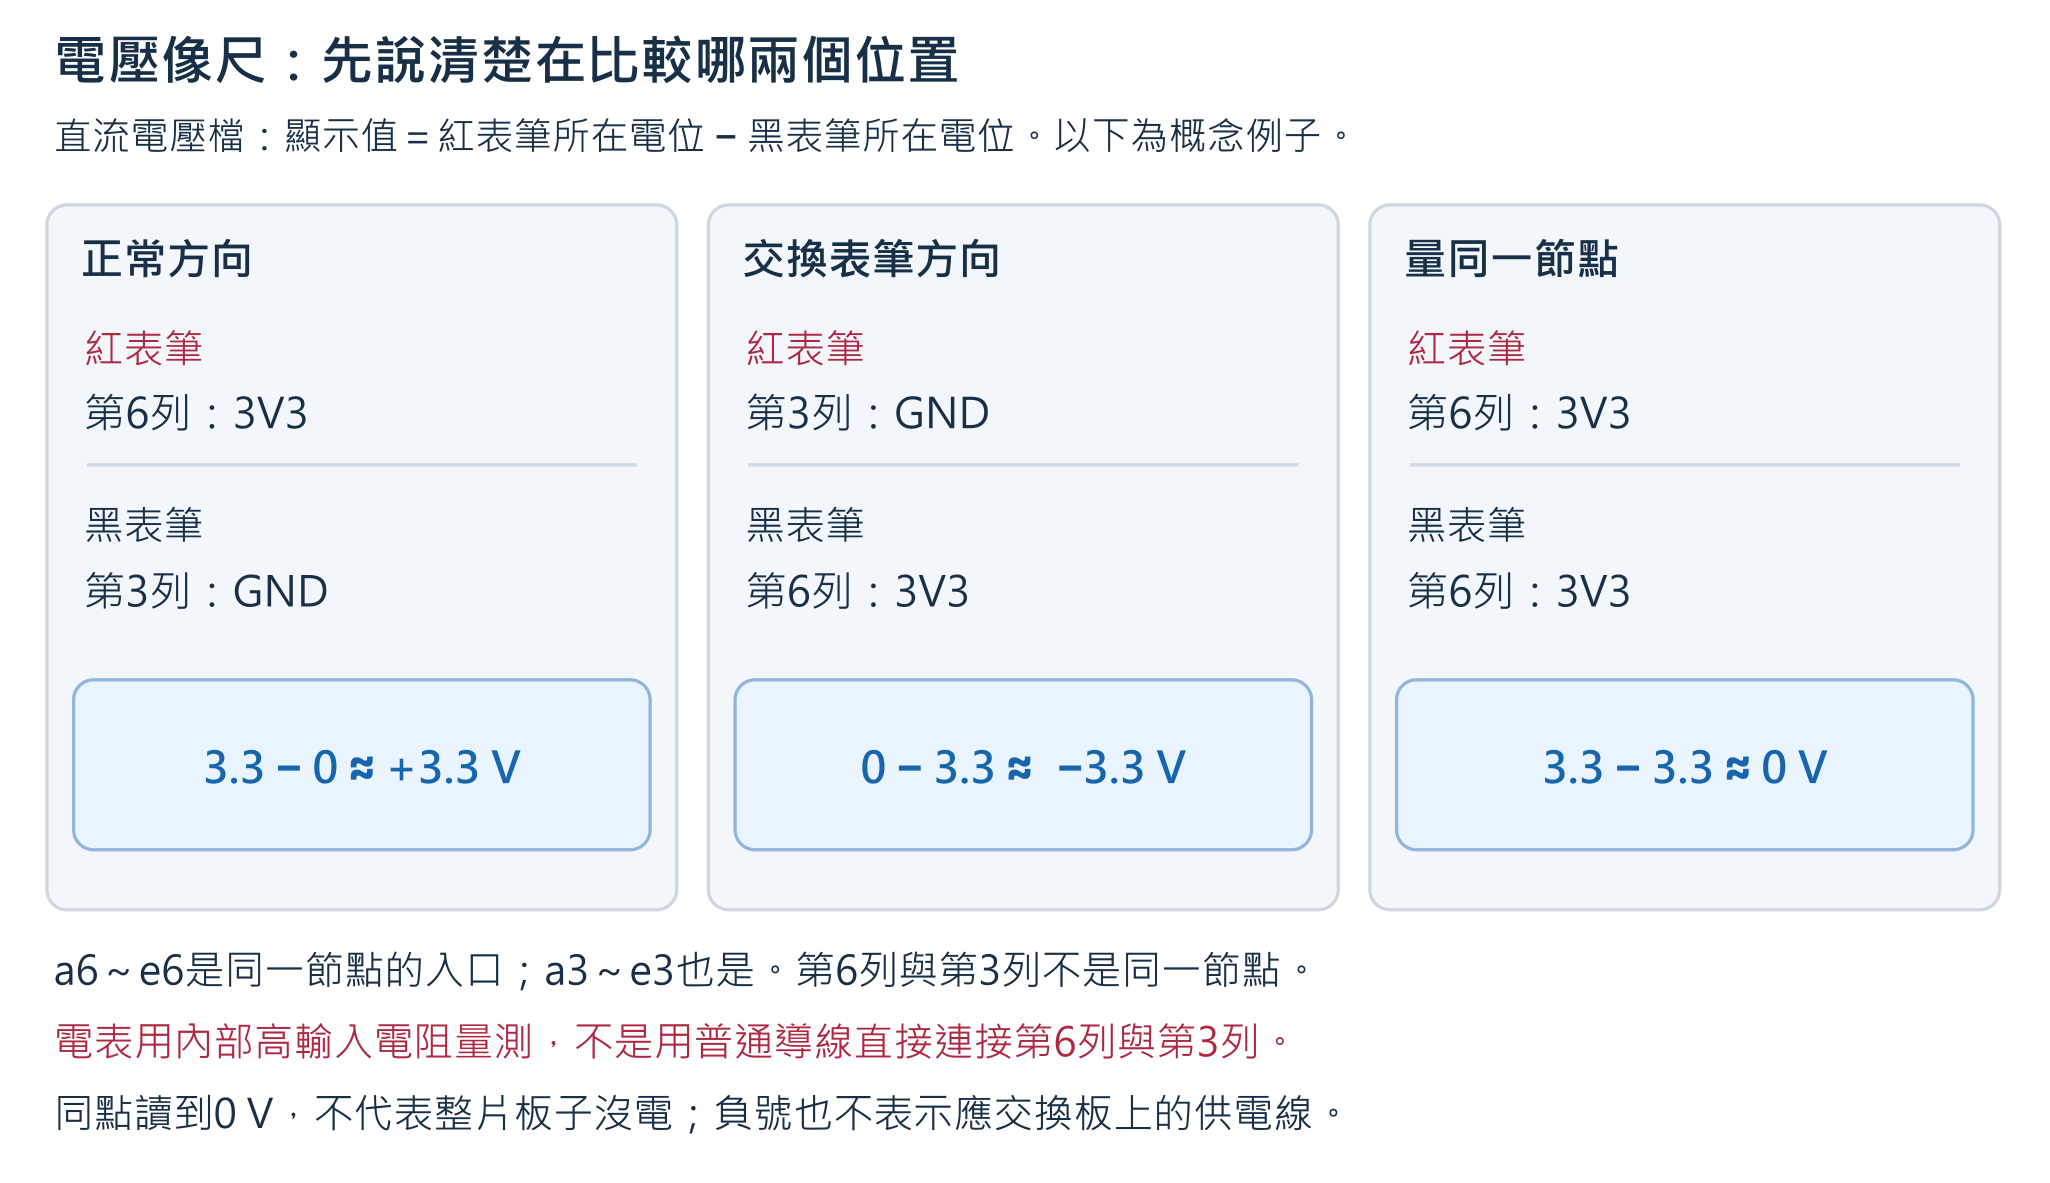

以第七節的接法為例，3V3先經紅線到a6，麵包板內部金屬片讓a6～e6相通，
白色延長線只是從e6再把同一個測點引出。GND則經棕線到a3，黑色延長線從e3引出。
電表紅表筆碰白線、黑表筆碰黑線，才是「3V3電位減GND電位」；
不是因為延長線叫白色或黑色就決定正負。

圖中的約3.3 V是說明用的預期值，不是要求實測一定等於3.300 V。
紅表筆碰GND、黑表筆碰3V3會得到負值，是尺反向量；
**不能因此交換板子的供電接線**。兩表筆量同一節點時接近0 V，
也不能單靠這個0 V推論整個電路沒有供電。

電表只有在**直流電壓檔**才使用此相減關係。切到Ω是在量電阻，
不是把「紅點電位減黑點電位」換一個單位。

### 一顆電阻的完整例子：電表讀值與計算電流是兩件事

**以下是理想紙上例子，不要求照圖新增接線，也不切到A檔。**
假設一顆1 kΩ固定電阻兩端相差3.0 V，想知道流過這顆電阻的電流。

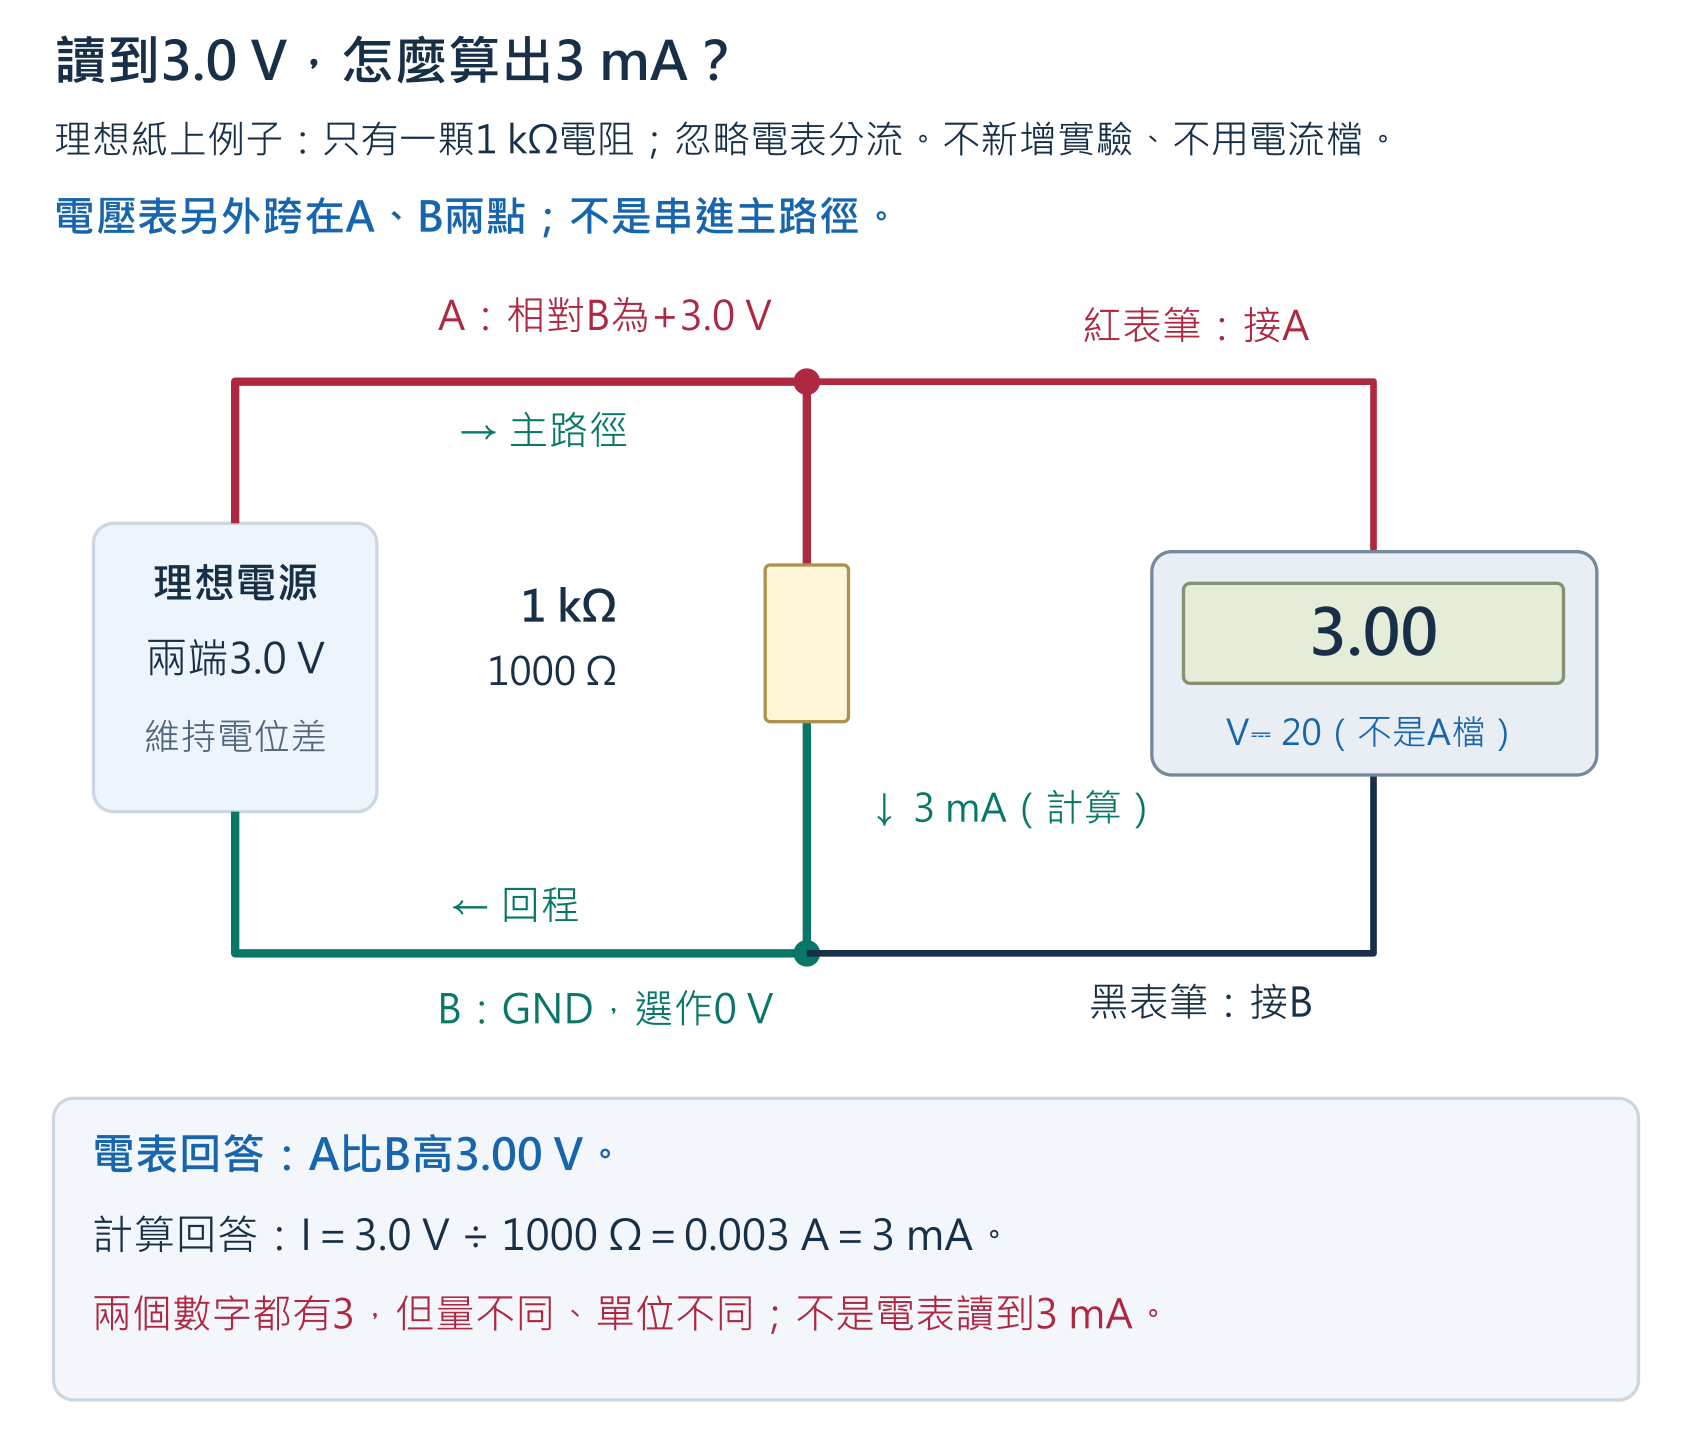

圖中實線表示電氣連接，圓點表示同一個接點，黃色長方形代表電阻；
這是電路關係圖，不是元件外觀或麵包板孔位圖。A、B是此圖自訂名稱，不是GPIO腳號。

先沿圖分別找兩條路徑：左側電源、上方導線、電阻、下方回程構成主要負載迴路；
電表則**另外跨在電阻的兩端**，以高電阻量測電路比較兩點。這種跨接叫
**並聯（parallel）**。不是先流進紅表筆，才准許主電路的電流流過電阻。
這個簡化模型忽略電表的微小分流；即使不接電表，完整的電阻負載路徑仍存在。

| 步驟 | 代入什麼 | 為什麼 |
|---|---|---|
| 1. 找已知 | 同一顆電阻的兩端電壓差3.0 V，阻值1 kΩ | 不能用別處的電壓或另一顆電阻 |
| 2. 統一單位 | 1 kΩ＝1000 Ω | 用V除以Ω，得到A |
| 3. 找未知 | I＝V÷R＝3.0÷1000＝0.003 A | 要算的是流過電阻的電流 |
| 4. 改用較好讀的單位 | 0.003 A×1000＝3 mA | 1 A＝1000 mA；同一電流、不同單位 |
| 5. 回算檢查 | 0.003 A×1000 Ω＝3.0 V | 回到原本的兩端電壓差 |

電表在V檔顯示的3.0是**3.0 V電壓差**；算出的3 mA是**模型電流**。
數字剛好都有3，不表示電表量到了3 mA，也不是3.0 V與1000 Ω相加。
歐姆定律的關係與用法見[Fluke官方說明](https://www.fluke.com/en-us/learn/blog/electrical/what-is-ohms-law)；
本例只用固定電阻模型，不把LED、馬達或整片ESP32都當成固定電阻。

接著一次改一個條件，先預測方向再看計算：

| 保持不變 | 只改變 | 計算結果 | 能解釋什麼 |
|---|---|---|---|
| 兩端3.0 V | 電阻由1 kΩ增為10 kΩ | 3.0÷10000＝0.0003 A＝0.3 mA | 同電壓下，電阻大10倍，電流小10倍 |
| 電阻1 kΩ | 兩端差由3.0 V降為1.5 V | 1.5÷1000＝0.0015 A＝1.5 mA | 同電阻下，電壓差減半，電流減半 |

若只知道電表讀0.52 V、卻不知道它跨在哪兩點與對應阻值，就**不能直接求出電流**。
「光敏S相對GND為0.52 V」和「電阻10 kΩ兩端為0.52 V」是不同的已知條件。

### 電流`I`：每段時間通過路徑的電荷量

在本週的電阻負載中，**傳統電流方向**由較高電位流向較低電位；這是電路分析的
約定方向，不是金屬中電子移動的方向。不能把這句話套成整個迴路每一段都只會
往低電位走：電源內部靠能量供應維持兩端差異，才能持續推動外部負載中的電流。

**封閉迴路**是能從電源一端經負載，再沿回程回到電源另一端的完整路徑。
**串聯（series）**是元件前後接在同一條路徑，中間沒有額外分支。
例如「3V3→兩顆串聯電阻→GND→板上供電電路」；最後一段已在板內，
不是要學生再用一條線把3V3與GND直接接起來。少了這個外部負載的回程，
原來的串聯電流就無法持續；但不代表整片ESP32都沒電，USB仍可讓板上的其他電路工作。

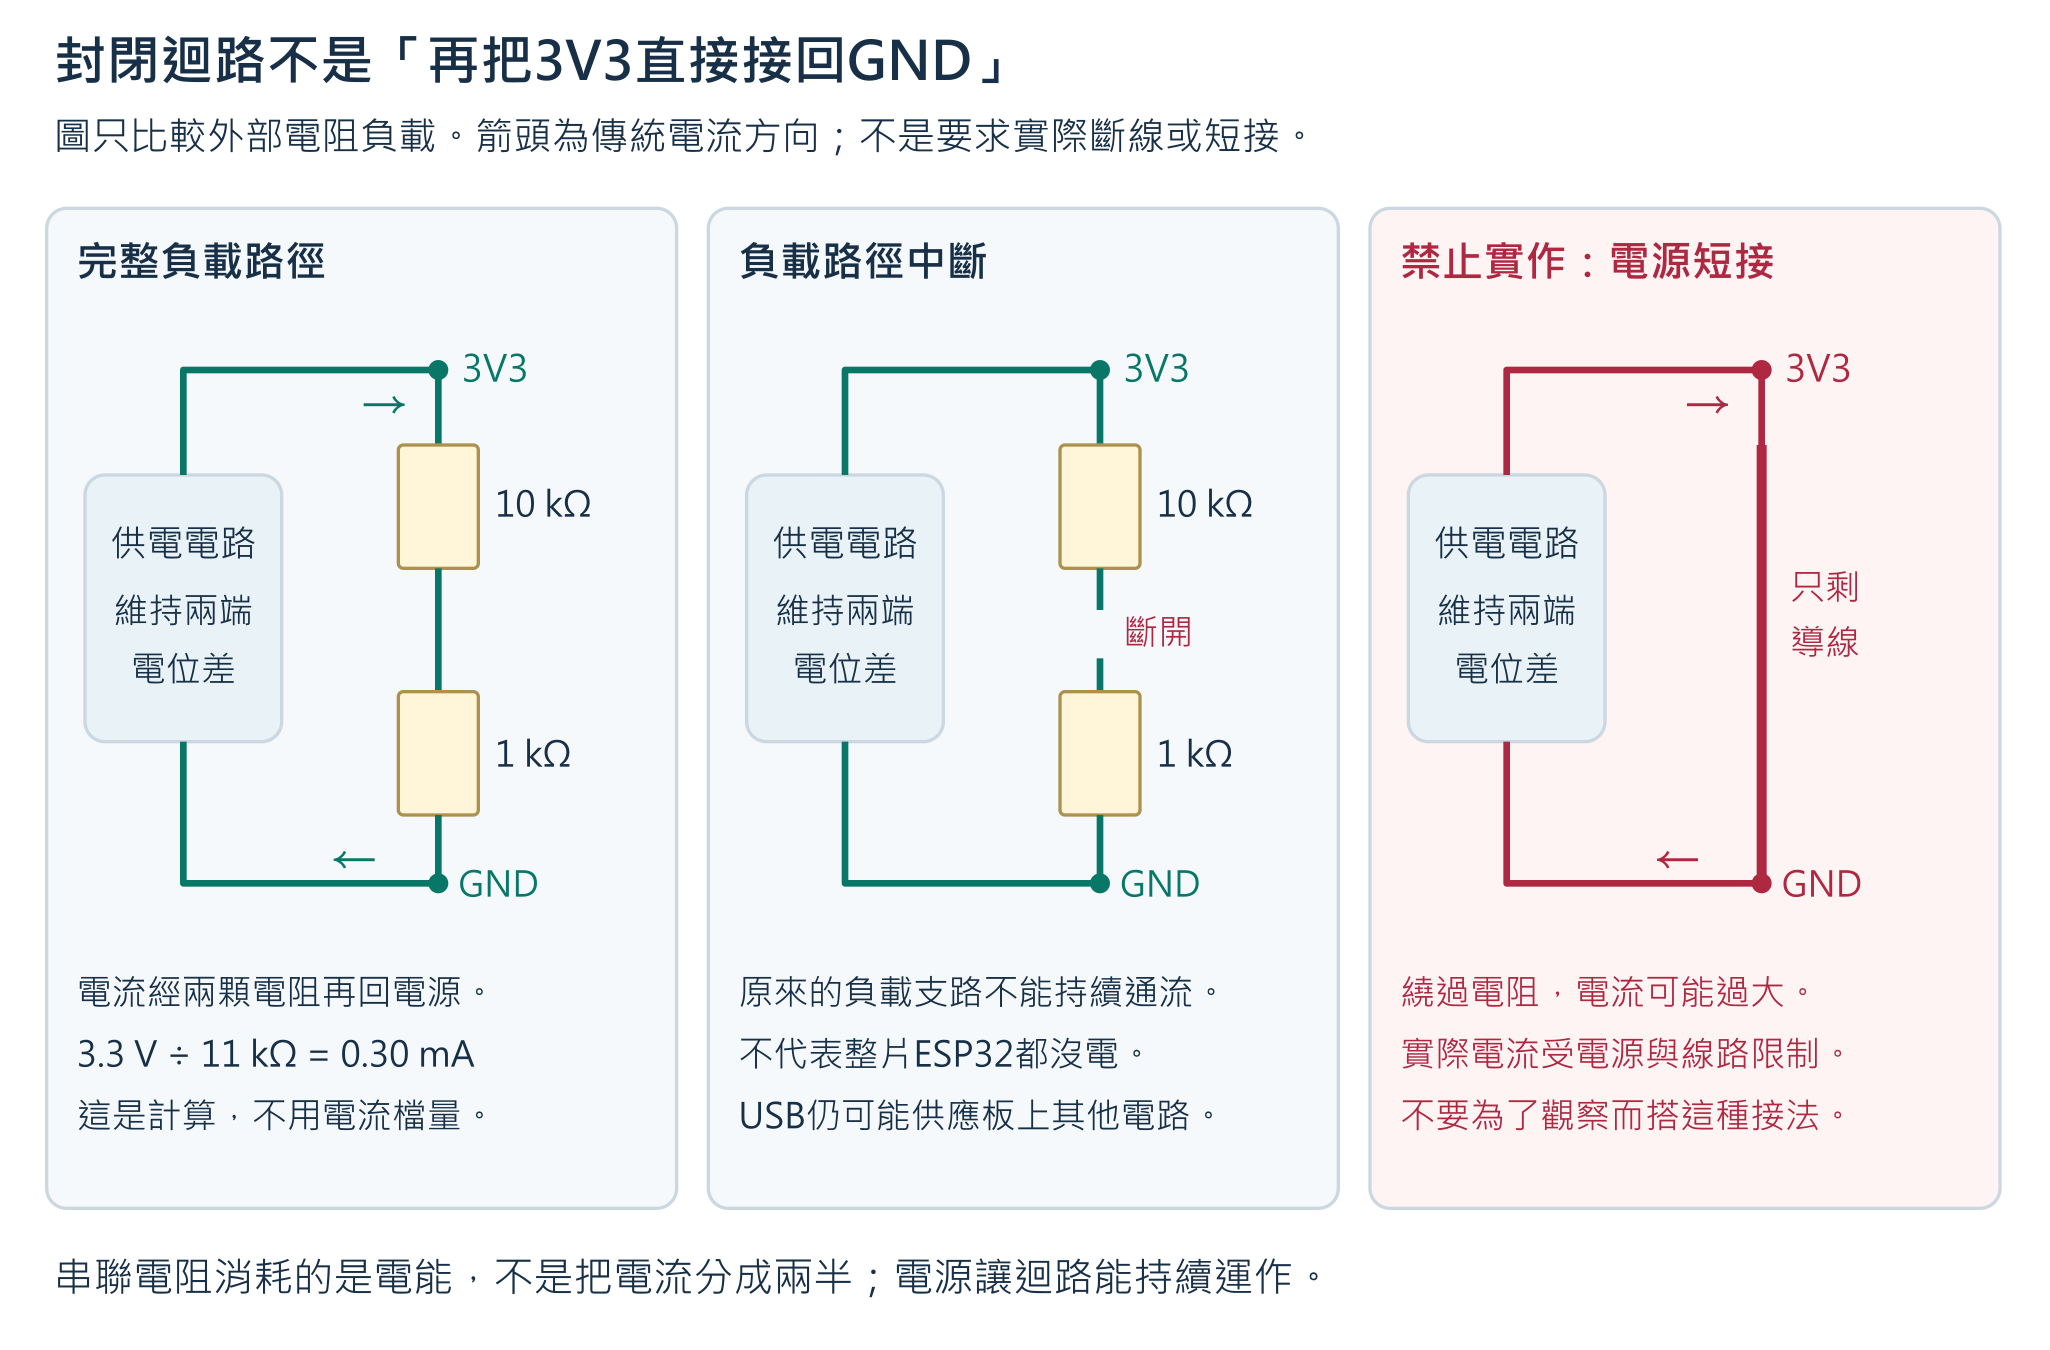

圖中箭頭只示意外部負載的傳統電流方向，不是速度或實測電流。
串聯中沒有分支時，前後流過的電流相同；電阻把電能轉成熱，
不是把一部分電流「吃掉」。本圖只用來判讀，不新增斷線或短接實驗。

### 從一顆電阻，過渡到兩顆串聯電阻

上圖正常路徑的10 kΩ與1 kΩ前後相接，總電阻為10000＋1000＝11000 Ω；
3.3 V是整條路徑的兩端差，必須除以**總電阻**：
3.3÷11000＝0.0003 A＝0.3 mA。不能只拿其中1 kΩ當分母來求整條串聯電流。
第十節才接著計算每顆電阻兩端各分到多少電壓。

若供電與GND間的路徑接近0 Ω，理想公式會要求非常大的電流；實際電流雖受USB、
穩壓器、導線與晶片限制，仍可能造成過熱、重啟或損壞。圖中紅色禁止欄只作反例。

**流量大不一定好。** 致動器需要足夠電流才能工作，但導線、GPIO與元件都有安全
上限。設計目標是讓電流走預定路徑並保持在元件可承受範圍，而不是越大越好。

### 短路：不該存在的低阻抗路徑

短路是原本不應直接相通的兩點之間，出現非預期的低阻抗路徑。例如3V3與GND被
普通導線直接相連，電流可能繞過原本的電阻負載；不同GPIO輸出誤接在一起也可能有問題。
「兩個獨立測試點沒有蜂鳴」只表示電表目前沒有量到低阻抗連接；「兩點持續蜂鳴」
也不一定立刻代表危險，因為它們可能原本就應相連。判斷短路必須先知道這兩點在
設計上是否應導通。

### 紅、藍線與正負號只是標示

紅色杜邦線不會自己產生正電，藍色線也不會自己產生負電。麵包板紅色`+`與藍色
`−`只是方便辨認的印刷線；只有接上3V3或GND後，該列才具有對應電氣功能。GND在
本課通常作0 V參考，但它不是宇宙中的絕對零電位，也不表示所有地方都帶「負電」。


<a id="w3-meter"></a>

## 五、讀懂A830L的插孔、顏色、符號與數字

### 先用實物找位置

下圖是本課A830L原始實拍，當時旋鈕在OFF。不是要把它維持OFF量測，也不是新量測結果。
LCD是液晶顯示幕；本照片上方灰綠色區域就是讀數的位置。

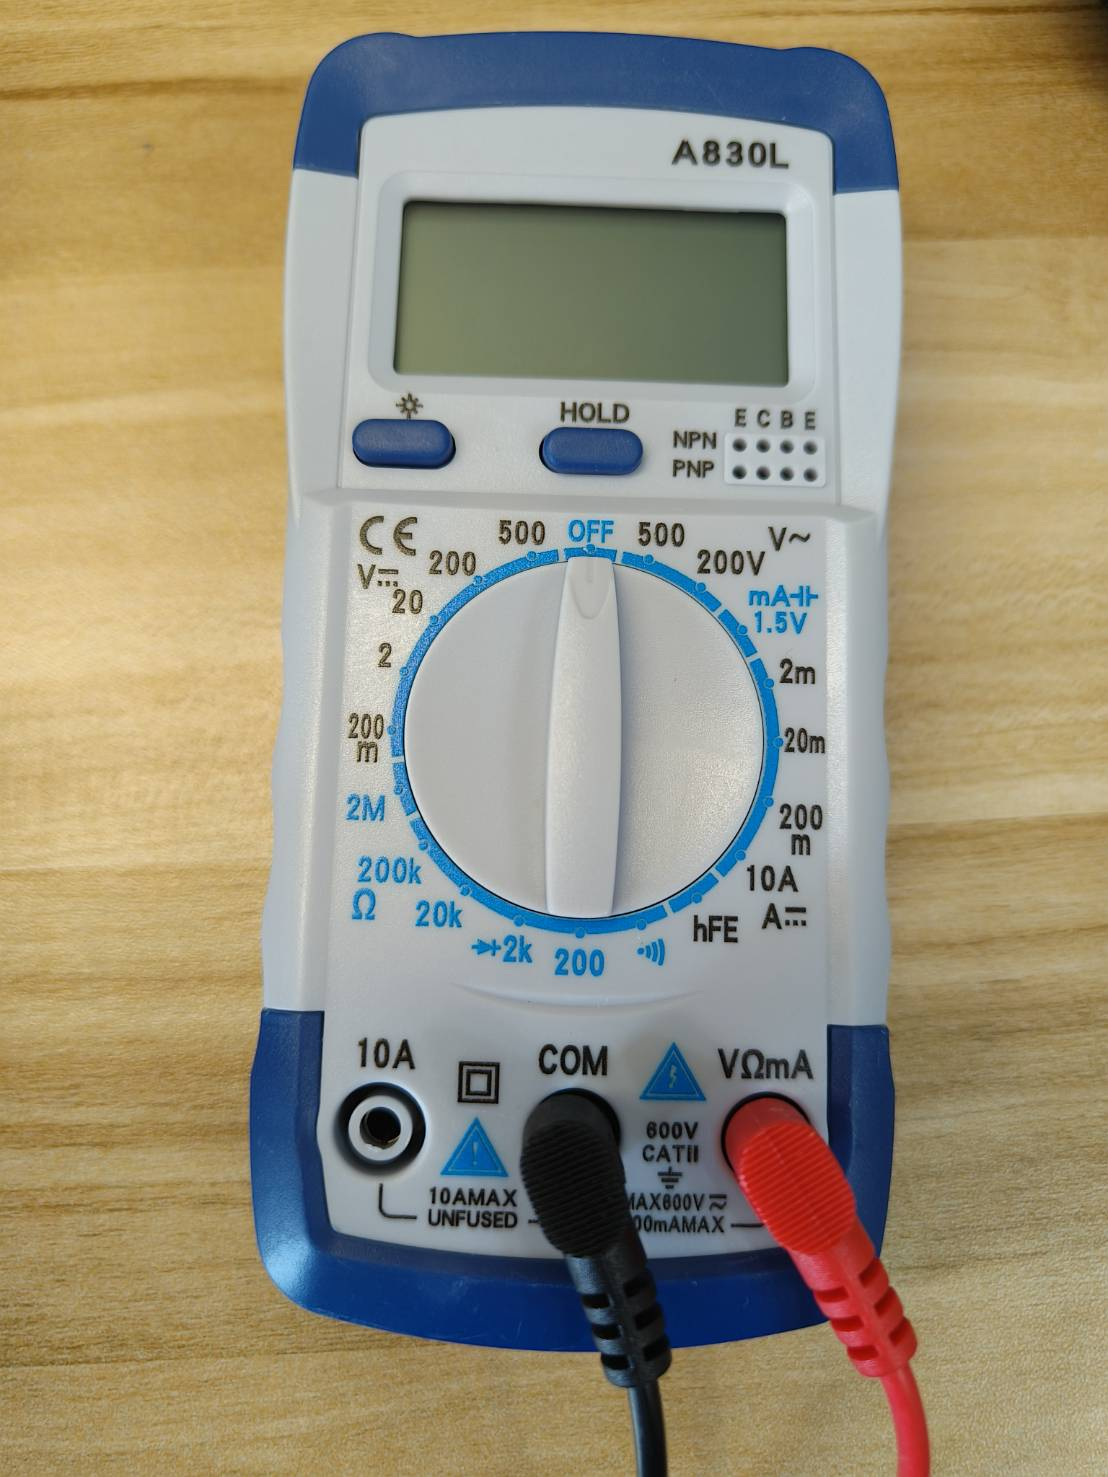

在這張照片上：直流V區在旋鈕左上方，選其中的`20`才是本週低壓直流電壓檔；
Ω區在左下至下方，`20k`、`200k`是不同電阻量程；
聲波符號在下方偏右，表示通斷功能。旋鈕尖端對準所選定位點，不看另一端。
不同型號只依自己的功能符號與說明書，不照抄鐘面方向。
面板右側的交流V、電流A與hFE本週都不操作。

### 插孔

- 黑表筆固定插`COM`。`COM`是common（共同參考端），本週量電壓時接GND。
- 紅表筆固定插`VΩmA`。本週的通斷、電阻與直流電壓都使用這個插孔。
- `10A`孔保持空置；它沒有保險絲保護的標示，且本週不量電流。

### 藍色與黑色印刷不代表正負電

A830L面板用藍色與黑色協助區分印刷區域，但這不是所有電表共用的標準，也不表示
正電與負電。必須看`V⎓`、`V~`、`Ω`、蜂鳴符號、`A⎓`及數值單位決定功能。

### `200`、`2k`與`20k`是量程

旋鈕在`Ω 200`時，`200`表示這個檔位用來顯示約200 Ω以內的電阻，不是電表會送出
200 Ω，也不是固定答案。`2k`與`20k`分別是約2,000 Ω與20,000 Ω的量程。

量程太低時，A830L可能在最左側顯示固定的`1`，表示超出目前量程或開路；這不是
1 Ω。量程合適且兩表筆尖端直接接觸時，常見讀值是`0.x Ω`，包含表筆、接觸與導線
電阻，不必恰好是0.0 Ω。


### 小數點、kΩ與MΩ必須一起讀

`kΩ`讀作「千歐姆」，`1 kΩ = 1,000 Ω`；`MΩ`是百萬歐姆，
`1 MΩ = 1,000,000 Ω`。Ω是電阻單位，V是電壓單位，兩者不能互換。
本課A830L在`20kΩ`與`200kΩ`檔以kΩ尺度讀數，但顯示的小數位數不同；
其他機型須依自己的顯示單位與說明書確認，不只照抄本表。

下表是讀表換算例子，不是要求每個模組都得到這些數字：

| Ω量程 | 完整畫面例子 | 電阻換算 |
|---|---:|---:|
| 20k | 14.00 | 14 kΩ = 14,000 Ω |
| 20k | 4.80 | 4.8 kΩ = 4,800 Ω |
| 20k | 1.90 | 1.9 kΩ = 1,900 Ω |
| 20k | 5.00 | 5 kΩ = 5,000 Ω |
| 20k | 10.00 | 10 kΩ = 10,000 Ω |
| 200k | 0.1 | 0.1 kΩ = 100 Ω |
| 200k | 0.6 | 0.6 kΩ = 600 Ω |

只記「14」或「10」可能漏掉小數點，不能自行補成14.00或10.00，更不能猜成
14 Ω或14 V。記錄旋鈕的完整刻度、螢幕小數點與單位；看不清楚就保留原始回報，
標示尚未完成換算。`200kΩ`與`200Ω`也不是同一個檔位。

電阻檔量的是兩個測點間的電阻，不使用「兩支表筆位置的電位相減」來解釋讀值。
那個相減關係只用於電壓量測；電阻讀值也不是GPIO的HIGH／LOW。

### 每筆數字都寫成五欄，不只說「14」或「0.6」

先說電路有沒有外部供電，再記「檔位、兩個測點、完整畫面、單位、判讀」。
以下是不同情境的**讀表例子**，不是要求重做四次量測：

| 檔位與電路狀態 | 兩個測點 | 完整畫面 | 換算後 | 判讀 |
|---|---|---:|---|---|
| Ω 200，外部斷電 | 穩定相碰的表筆尖端 | 0.6 | 0.6 Ω | 短接通路電阻很小；不是完全0 Ω |
| Ω 200k，模組獨立斷電 | 模組S與− | 0.6 | 0.6 kΩ＝600 Ω | 依本表kΩ尺度讀；不是0.6 Ω |
| V⎓ 20，模組正確供電 | 紅S、黑GND | 0.60 | 0.60 V | S比GND高0.60 V；不是電阻 |
| Ω 20k，模組獨立斷電 | 模組S與− | 最左側單獨1 | 不填阻值 | 超量程或開路提示，先查接觸與量程 |

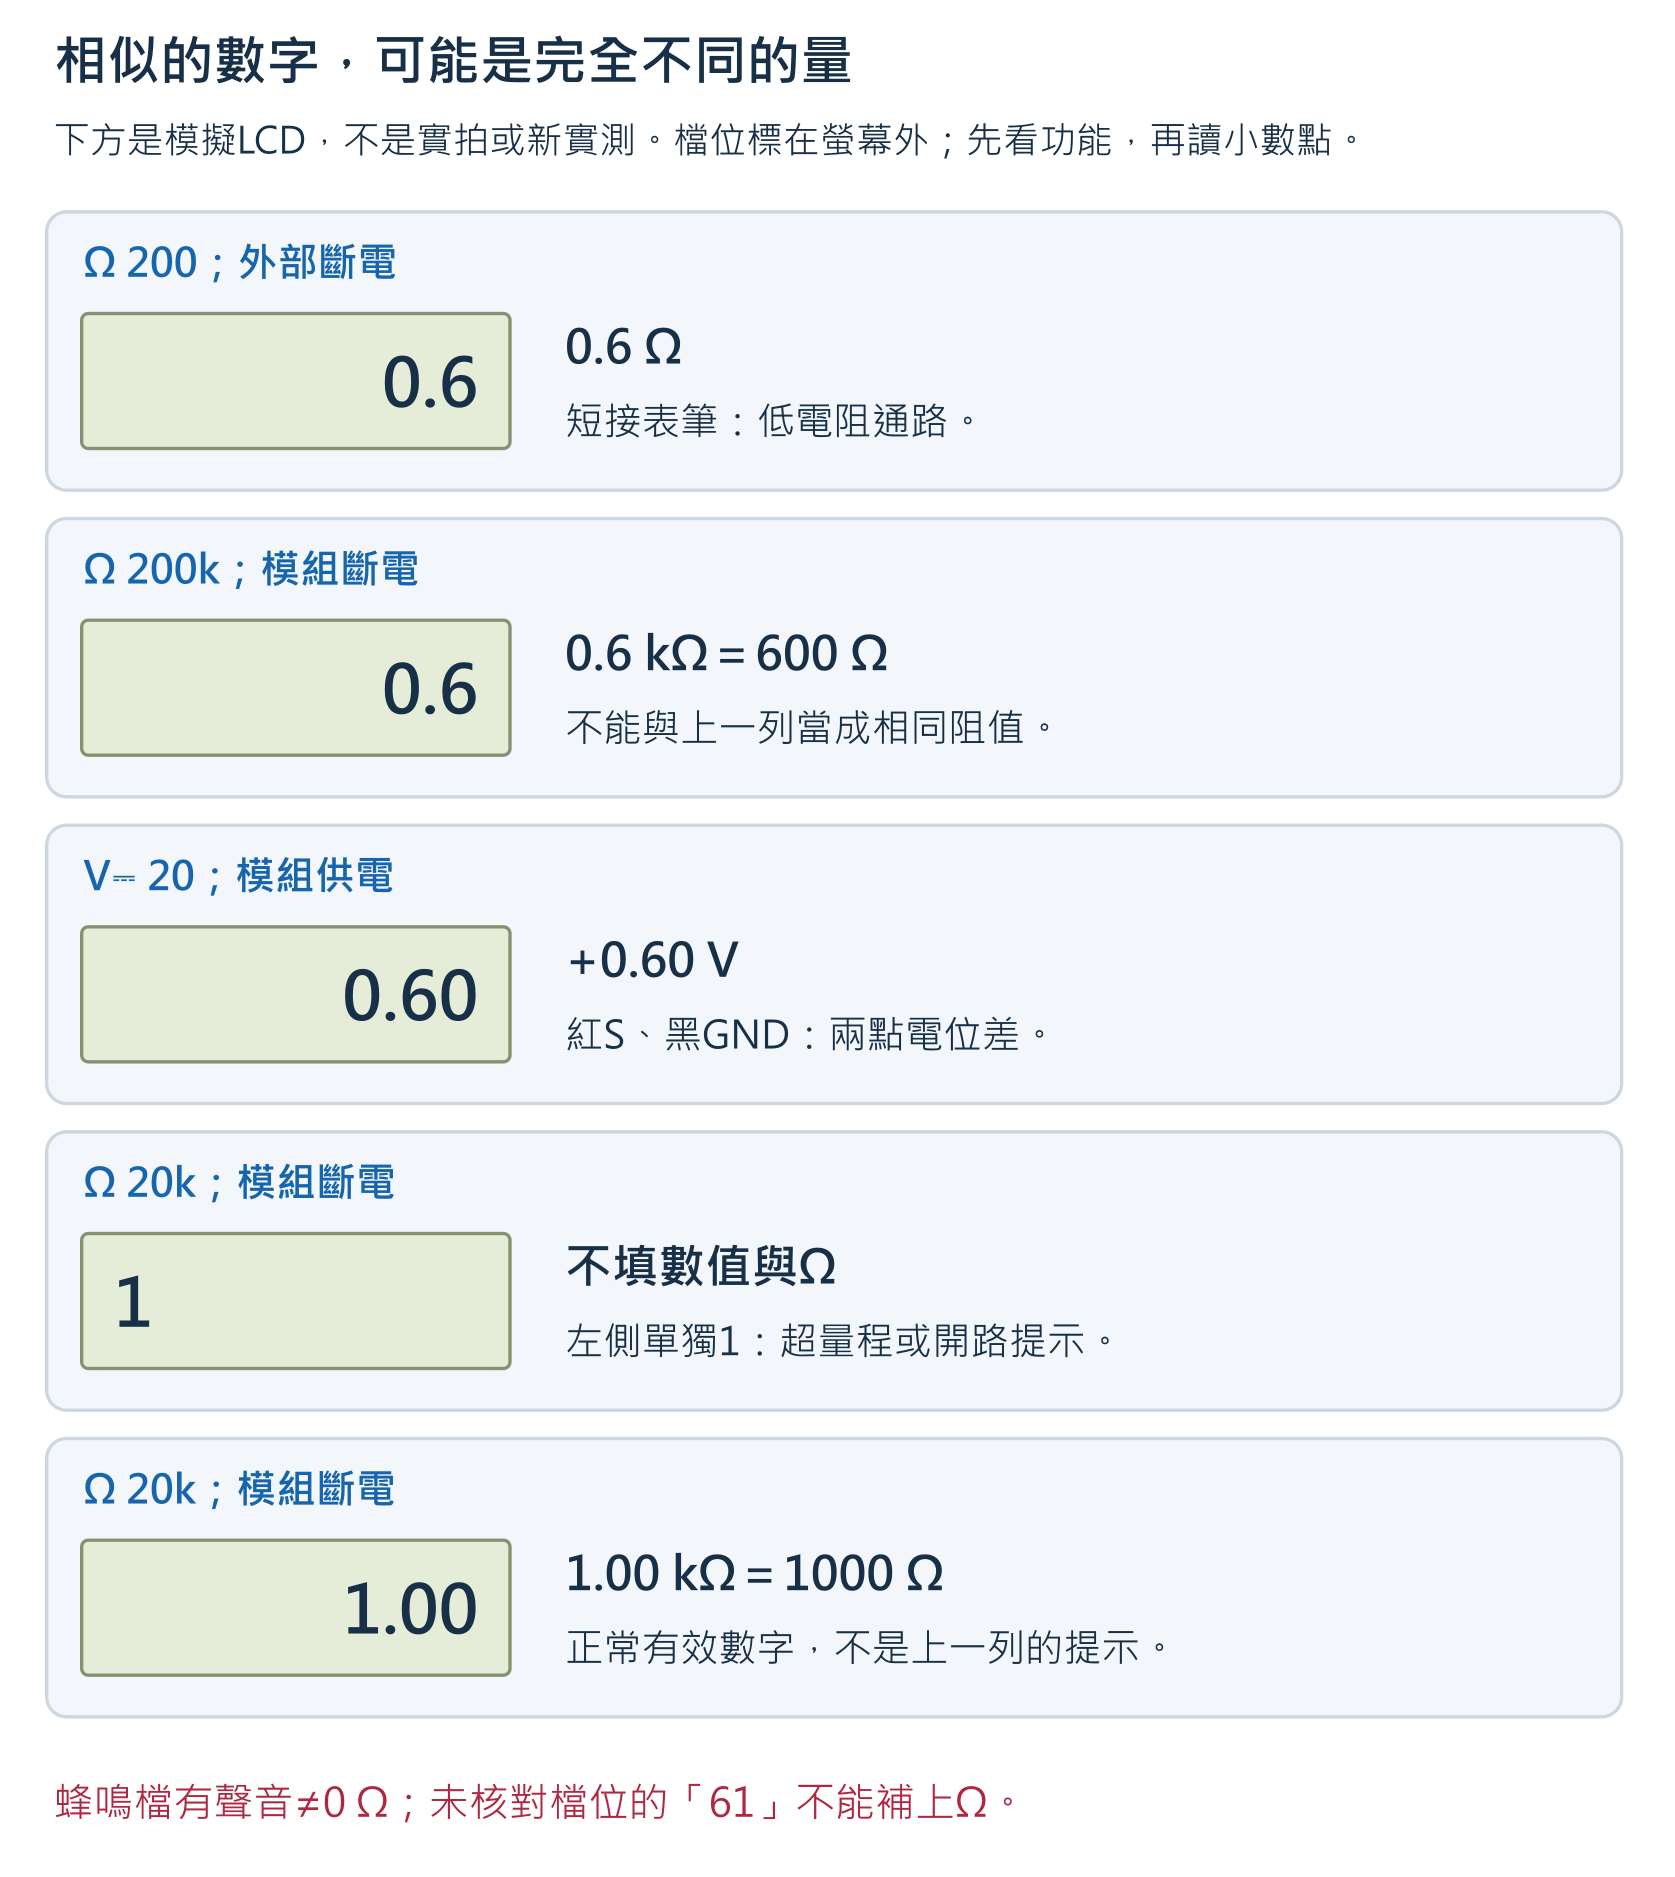

讀第一列時可完整說：「在沒有USB或電池接到待測物的情況下，電表選Ω 200，
兩表筆尖端穩定接觸，顯示0.6，因此目前通路約0.6 Ω。」
讀第三列時則是：「模組正確供電，電表選V⎓ 20，紅S黑GND，
顯示0.60，所以S相對GND為+0.60 V。」兩句用了不同功能，不可混用。

遇到0.6的第一個問題不是「高不高」，而是「哪一檔、哪兩點」。
在導線短接情境，0.6 Ω可能合理；用Ω 200k得到600 Ω卻不是同樣的低電阻證據。
量S得到0.60 V，只能先描述兩點差，不能說光照度是0.60、GPIO必為HIGH或電流是0.60 A。
電流要知道相應電路與阻值才能計算；本週不接電流檔實測。

### 遮光後顯示單獨的1，不等於電阻變成1 Ω

最左側單獨的`1`是狀態提示，與正常排列的`1.00`不同。可能是阻值超出目前
量程，也可能是表筆鬆開、導線接觸不良或被測路徑開路。不能把`0.6 → 1`
當成連續的兩個有效電阻值，也不能直接斷定模組故障。

例如，在20kΩ檔量光敏路徑，室內光讀到4.80，遮光後顯示單獨的1，
移開遮光物又回到約4.80。這個往返變化支持光敏反應，也使遮光超量程成為
合理解釋；仍須避免遮光物碰動導線而同時改變接觸。

安全檢查順序如下：

1. 被測模組維持完全斷電，表筆接點保持穩定，只移開遮光物，觀察讀值是否恢復。
2. 若恢復，且要知道遮光後的阻值，先移開兩支表筆，再把Ω量程由20k改為200k。
3. 重新接觸原本兩個測點，以相同方式遮光，記錄新量程與完整畫面。
4. 若仍顯示單獨的1，先檢查接觸；確認後才能再評估2MΩ量程。若始終無法取得
   穩定讀值，保持斷電，記錄「超量程或開路尚未分清」，不要填一個推測值。

換量程不會把元件電阻變大或變小。例如同一個100 Ω電阻，在20k檔約顯示0.10，
在200k檔約顯示0.1，代表相同阻值但可辨認的小數位不同。相反地，
20k檔的4.80與200k檔的0.1並不等值：前者約4,800 Ω，後者約100 Ω。
若宣稱是在相同條件下量得，必須核對測點、光線、接觸與原始畫面；
不能用「只是換檔」解釋差異，也不能因此宣稱換檔驗證通過。

### 通斷測試是正式技術用語

continuity test通常翻成**通斷測試**或**導通測試**。蜂鳴表示儀表偵測到符合其
導通判定條件的路徑；它有門檻，不等於0 Ω，也不是所有電表都相同。
[Fluke通斷測試說明](https://www.fluke.com/en-us/learn/blog/digital-multimeters/how-to-test-for-continuity)
支持斷電測試、確認接觸與依儀表判讀的原則，不是這支A830L的專屬規格書。

例如先前只回報「有聲音、61」或「30～80、198」，若未同時確認旋鈕、完整小數點
及顯示單位，便只能記為原始畫面回報，**不能逕自加上Ω或V**。
要量出電阻，保持被測物斷電，先移開表筆，選明確的Ω量程後再量；
第五節的20k／200k換算表不直接套用到未確認模式的蜂鳴畫面。

沒聲音也不是「已證明絕對不通」：可能是阻值高於蜂鳴門檻，也可能是表筆沒碰好。
先把表筆與電路分開相碰，確認電表與接觸可用，再核對預定路徑。
最左側單獨的1仍須配合檔位判讀，不能當成GPIO的`HIGH`。

**三個例子：** 同列a6與e6本來就該通，有聲音是預期；
未接元件的第3列與第6列本來分開，沒有聲音是預期；
若原本分開的電源與GND測點卻持續蜂鳴，先維持斷電查線，不先上電試。
這些例子是在判斷「是否符合原來設計」，不是把有聲音一律叫短路。


<a id="w3-resistance"></a>

## 六、實驗一：用KY-018辨認固定電阻與光敏電阻

### 6.1 先說明要找什麼，再開始量

本實驗不是追求10、14或其他指定數字，而是找出兩種現象：

- **固定電阻**：阻值大致固定，改變光線不應造成明顯變化。
- **光敏電阻**：光越強，阻值通常越小；光越弱，阻值通常越大。

[Joy-IT KY-018官方說明](https://sensorkit.joy-it.net/en/sensors/ky-018)介紹了光敏電阻
與10 kΩ固定電阻的分壓結構。這是來源支持的參考設計，不代表同名相容模組的
每個腳位、阻值或功能都已通過實測。本實驗不需要另買散裝電阻；萬用電表負責量測，
真正位於電路中的元件是模組上的固定電阻與光敏電阻，電表不能取代它們。

開始前：ESP32端USB已拔除，KY-018未接ESP32、麵包板或任何外部電源；黑表筆在
`COM`，紅表筆在`VΩmA`。電阻檔由電表自身提供小測試訊號，因此不需要USB供電，
也不能拿電阻檔量已供電的模組。

### 6.2 三組測點的數字各代表什麼

先找模組上方的光敏元件與三根排針。本課參考實物在光敏元件朝上、排針朝下時，
左側排針旁有獨立的`S`，右側有`-`，中間排針沒有清楚獨立標示。
本節暫時把未標示的中間排針叫作`M`；這是方便紀錄的自訂名稱，不是板上文字，
也不代表已確認它是電源腳。先依下方實拍確認文字的位置，再拿表筆量測。

下列是本課教師實物照片。照片可用來辨認元件種類，但腳位仍以自己手上的絲印為準；
不可把照片左右位置或杜邦線顏色當作腳位證據。

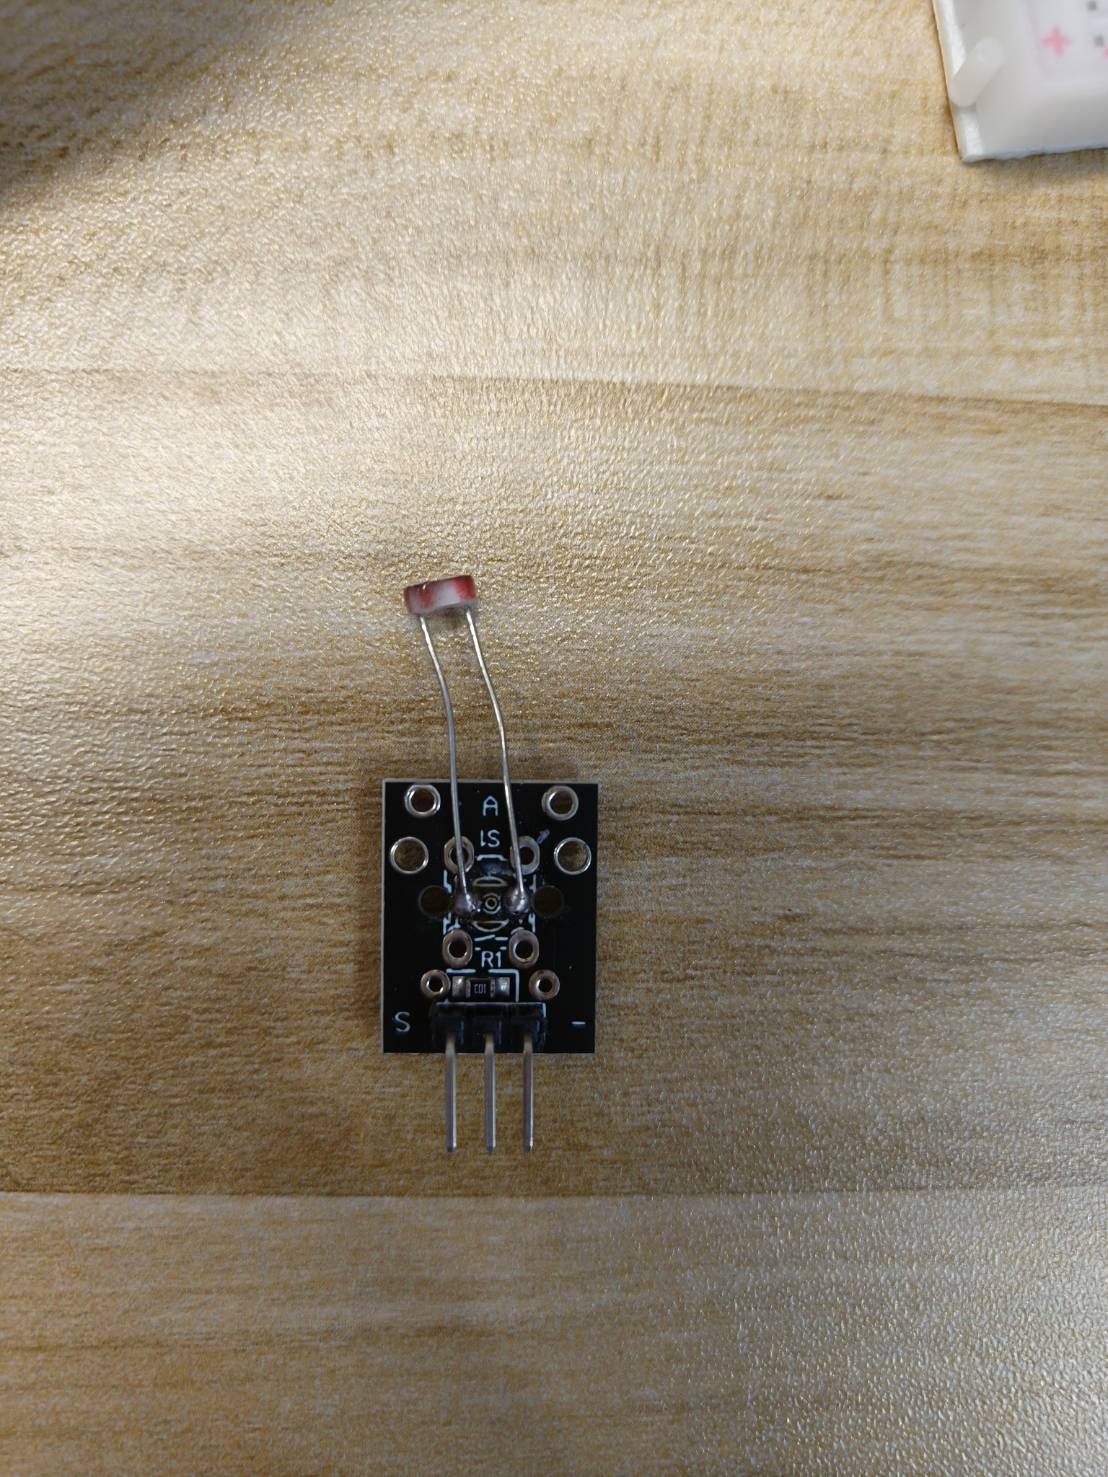

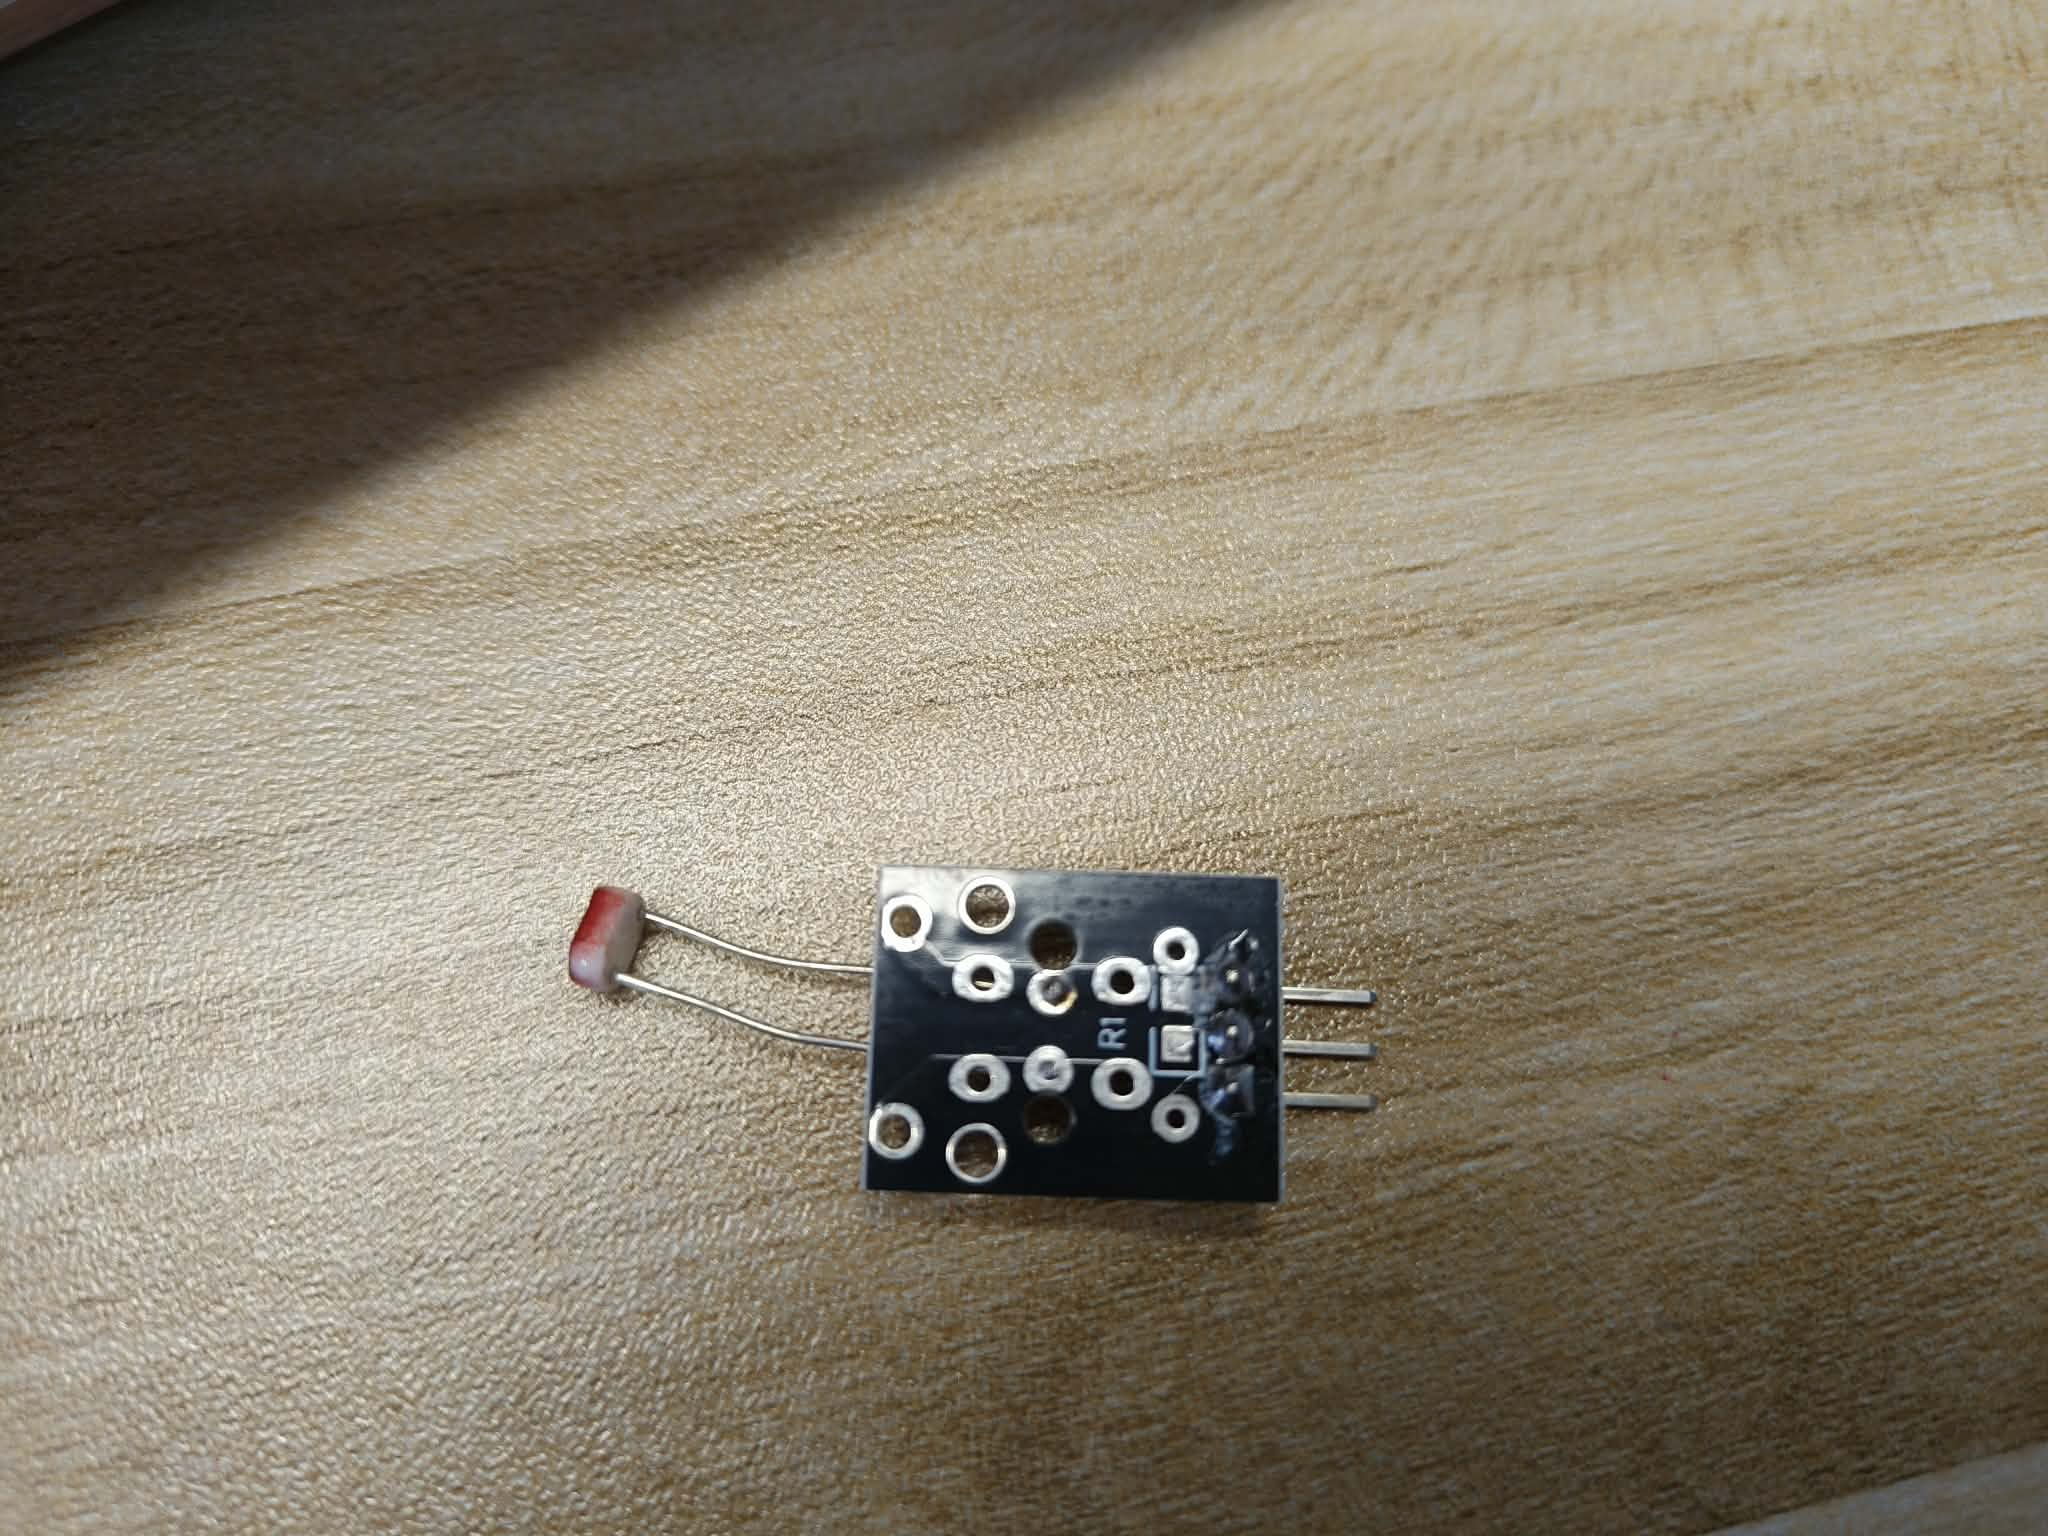

#### 先讀實物，再量三組路徑

1. 保持USB拔除、`PWR`熄滅，模組沒有接電源。
2. 找到圓形或扁圓形、有蛇形紋路的光敏電阻。
3. 找到三根排針旁的絲印。這片實物在排針朝下時，左下角可見單獨的`S`，右下角
   可見單獨的`-`；中間排針旁沒有清楚的`+`。
4. 照片中央確實可讀到`A`、`S1`與`R1`。它們位於元件與焊點之間，不在中間排針
   旁；因此不能把三者當成中間排針的名稱。`R1`通常表示第1顆固定電阻，但只靠
   這張照片還不能確定`A`與`S1`各自的設計用途。排針功能要看緊鄰排針的獨立
   絲印、官方電路說明與斷電量測，不能只由中央文字猜測。
5. 拍一張同時看見元件與排針絲印的照片。
6. 任何一腳看不清楚時保持斷電，先用來源與斷電量測確認電路關係；不靠網路購物圖
   或『剩下的一腳』直接猜測後通電。

| 測點 | 電表量到的量 |
|---|---|
| S與− | S腳到−腳之間整條路徑的電阻 |
| S與M | S腳到未標示中間腳之間整條路徑的電阻 |
| M與− | 未標示中間腳到−腳之間整條路徑的電阻 |

杜邦線只是把腳位延伸到容易碰觸的位置。測「兩條線」不是分別量每條線，
而是量線頭所連到的兩個模組端點；顏色不決定其中是否有固定電阻或光敏電阻。
也不能先把S與−指定成固定電阻，再要求測量結果符合這個猜測。

### 6.3 兩個較小阻值為什麼可能相加

**以下是教學假設，不是學生模組的既定接線答案。** 假設只有兩顆電阻前後
串聯，中間沒有其他外接路徑，而且結構如下：

```text
M ── 固定電阻 ── S ── 光敏電阻 ── −
```

「串聯」表示沿同一條路徑依序經過兩顆電阻。量M到−會經過兩顆；
量M到S或S到−各只經過其中一顆。因此在相同光線下：

```text
M到−的總電阻 = M到S的電阻 + S到−的電阻
```

例如下表的理想假設值：

| 測點 | 室內光 | 遮光後 | 判讀理由 |
|---|---:|---:|---|
| S與M | 10 kΩ | 10 kΩ | 不隨光線明顯改變，符合固定電阻特性 |
| S與− | 5 kΩ | 30 kΩ | 遮光後增加，符合光敏電阻特性 |
| M與− | 15 kΩ | 40 kΩ | 依序經過兩顆，分別等於10＋5及10＋30 |

這個例子的**電路中間接點是S，不是外觀位置居中的M排針**。
若改成另一種接法，中間接點也可能不同；不能只照字母或線色決定誰加誰。
兩個較小值相加接近最大值，只適用於已確認的簡單兩電阻串聯模型；
有其他元件、外接線路或變動的光線時，不能直接套用。

真正量測前，先預測：哪一組可能大致固定、哪一組可能隨光線改變，以及理由。
實測用來檢查預測，不把上表的假設值抄進自己的結果。

### 6.4 斷電量三組路徑

1. 電表先選`Ω 200`，讓兩支表筆尖端穩定相碰。正常應接近0 Ω，可能顯示0.x Ω，
   其中包含表筆與接觸電阻；若持續顯示單獨的1，先檢查插孔、旋鈕與接觸，不量模組。
2. 移開表筆，電表轉OFF。在S、M、−三根排針各套一條公對母線，三個公針端
   分開固定。模組仍未接麵包板、ESP32或電源。逐條從絲印追到公針端並記錄對應；
   不用兩手同時捏住兩個金屬端，否則人體可能形成額外的電阻路徑。
3. 電表選`Ω 20k`。先量S與−：黑表筆碰−端的延長線，紅表筆碰S端延長線，
   M端保持隔離。等讀值穩定，記錄一般室內光下的量程、小數點與單位。
4. 一人操作時先移開並放下表筆，安放不導電、不透光的紙片或布料遮住光敏元件，
   再回到同一對測點量測。不要一邊拿兩支表筆，一邊拉衣服或搬模組。
   遮光物保持穩定、不壓彎金屬腳、不碰排針、不拉動線材；記下接觸曾中斷，
   不把先後取得的數字當成完全同步量測。
5. 只移開遮光物，觀察數字是否回到原本附近。目的是只改變光線，區分光敏反應
   與接觸中斷；不是只要數字跳動就算成功。若顯示單獨的1，依第五節的安全順序
   排除接觸與超量程，不把1填成電阻值。
6. 移開表筆，再量S與M；黑表筆碰M端，紅表筆碰S端，−端保持隔離。
   同樣比較室內光、遮光及恢復室內光。若約10 kΩ且明暗大致不變，才支持
   這組量到固定電阻；不要求畫面恰好10.00。
7. 移開表筆，再量M與−；黑表筆碰−端，紅表筆碰M端，S端保持隔離。
   比較相同光線條件下的讀值，檢查是否接近前兩組的和。
8. 要比較總和時，盡量保持模組位置、光源角度與遮光方式相同，比較前面依序取得的三組。
   單一電表不能同時量三組；記錄量測順序與光線變動，不將不同輪次混算成精密驗證。
9. 移開兩支表筆、電表轉OFF。將結果填入附錄C的量測紀錄。
   接點未分清、結果仍矛盾或腳位無法追溯時，維持斷電，不試接3V3。

### 6.5 實際觀察案例：支持某個接法，不等於精密驗證完成

下表整理一次引導量測的回報，依當時20kΩ量程換算為近似值。
數字不是同步取得，光線與遮光程度也沒有量化；這是判讀案例，不是標準答案。

| 測點 | 一般光 | 暗光 | 可支持的有限結論 |
|---|---:|---:|---|
| S與− | 約1.9 kΩ | 約5 kΩ | 阻值隨變暗而增加，支持光敏路徑 |
| S與M | 都接近10 kΩ | 都接近10 kΩ | 明暗大致不變，支持固定電阻路徑 |
| M與− | 約11 kΩ | 約14 kΩ | 最大路徑也隨光線改變，支持串聯總和的方向 |

但一般光下`1.9＋10＝11.9`，不等於11；暗光下`5＋10＝15`，不等於14。
不能把不同時間的數字說成精確相加已通過。光線與接觸變化是待檢查的可能原因，
不是已證明的原因。需要精確核對時，先固定條件重測，再依儀表與元件規格討論誤差，
不自行設定「差一點就算通過」的門檻。

同一過程曾先回報14、13，未確認完整小數點，這兩筆不能用來認定固定阻值。
另有20k與200k讀值不一致的回報，仍須保留待核對，不用後續合理趨勢覆蓋異常紀錄。
這些斷電結果不代表KY-018供電後的訊號電壓或ESP32的ADC已經通過。

完成條件：有三組路徑的量程、完整讀值與明暗／恢復條件，能用觀察支持固定或
光敏路徑的判斷，說明相加關係的成立條件，並保留不吻合處。自己的模組若與案例
不同，保持斷電交由教師核對，不把案例的端點對應直接當成通電許可。


<a id="w3-test-points"></a>

## 七、實驗二：建立PGND、P3V3與TPO

PGND、P3V3與TPO是本實驗自訂的三個test point（測試點）標籤，不是麵包板原廠功能：

- `PGND`：接到ESP32實物絲印`GND`，作黑表筆共同參考。
- `P3V3`：接到實物絲印`3V3`。
- `TPO`：接到教師正式公布的GPIO測試輸出。

`5Vin`則是板上的實際絲印，不是本課自訂測試點。BOARD-T01目前只辨認這個外部
5 V輸入腳，不建立USB 5 V輸出測試點，也不把它加入下面三條線。

**為什麼選左下GND，不用另一側的GND？** 本接法固定選用已核對的左下GND，
是為了讓追線與照片有一致位置，不是因為左右會產生不同種類的地。若兩根排針
在確切板卡電路中同屬GND，而且斷電量測確認相通，它們就是同一共同參考節點。
但不能只憑相近位置，把未看清絲印的排針當成GND；本次仍依接線表操作。
模組−與電表黑表筆之後都接到第3列，是讓它們共用同一GND，
不是一定要再從ESP32拉第二條GND線，也不是有兩個不同的零點。

本課使用下列固定接線，使初次操作及故障排查具有相同座標。線色是本實驗的
辨認約定，不會自行產生電壓或決定正負：

| 線色 | 公對母線的母頭套在ESP32 | 公頭插入麵包板 | 同一測試節點 | 名稱 |
|---|---|---|---|---|
| 棕色 | 左排下方、緊鄰`5Vin`的`GND` | `a3` | `a3～e3` | `PGND` |
| 紅色 | 左排最上方第一個`3V3` | `a6` | `a6～e6` | `P3V3` |
| 黃色 | profile指定的GPIO測試輸出腳 | `a12` | `a12～e12` | `TPO` |

三條線接好時只是把板上的三個腳位延伸到較容易接觸的位置。PGND、P3V3與TPO
仍是彼此分開的節點；沒有用普通導線互相橋接，也沒有因為線插進麵包板就自動形成
負載電路。電表切到直流V檔並跨在其中兩點時，才會經由電表內部建立高電阻的微小量測路徑；
這段說明不適用於Ω或電流檔。

ESP32保持在麵包板旁，不把本體直接壓入這片400孔麵包板。公對母線的母頭套在
ESP32排針，公頭插入表中座標。同一列`a～e`由麵包板內部金屬片相連，因此
`a6`接到3V3後，`b6～e6`都是同一個P3V3測試節點，不是五段串聯路徑。例如
3V3的實際路徑是`ESP32 3V3→紅色線→a6`，而`a6～e6`是同一塊內部金屬接點。
跨過中央溝槽後的`f6～j6`則是另一個節點，不會因列號同為6就自動相連。

### 先結束Week 2線路，不沿用舊列號猜功能

現在先拔USB、確認PWR熄滅、電表OFF。若麵包板上仍有Week 2按鈕，
先取下按鈕與舊公對公跨接線，再把舊GPIO、GND公對母線的兩端移開。
這是換成新實驗，不是讓新舊線路同時接上。

| 前一週 | 本週重新建立 | 不變的是什麼 |
|---|---|---|
| 第22列TPG | 第3列PGND | 都選定為GND參考，但不是同一個實體列 |
| 第20列TPO | 第12列TPO | 都是測試輸出延伸點；列號改了 |
| 第27／29列按鈕 | 此階段沒有按鈕 | 不把舊按鈕接線留作本週負載 |
| 沒有接3V3到麵包板 | 第6列P3V3 | 新增已核對的3V3電源測點 |

開始下一步時，麵包板只剩空板，KY-018仍獨立斷電；ESP32在板旁，排針沒有接舊線。
已收納乾淨者直接核對此起始狀態，不必重接上一週線路。

### 步驟1：斷電建立測試點

1. USB保持拔除，`PWR`燈熄滅，電表轉`OFF`。
2. 依上表先把三條線的公頭插入`a3`、`a6`與`a12`。
3. 再把母頭逐一套到ESP32的`GND`、`3V3`與profile指定的GPIO測試輸出腳。
4. 每接一條線，就用手指從ESP32絲印沿線走到測試點，再反向走一次。
5. 找到板上的`5Vin`與`IN-OUT`絲印，但不要接線、焊接或橋接`IN-OUT`焊盤。

### 先做表筆容易碰到的延長端

仍不接USB。先用公對公線把測點移到桌面，避免一人拿表筆時滑到相鄰孔或排針：

| 公對公線一端 | 另一端的安排 | 之後哪支表筆碰它 |
|---|---|---|
| 黑線插e3 | 外露公針端標PGND，平放於不導電桌面 | 黑表筆 |
| 白線插e6 | 外露公針端標P3V3，與PGND分開 | 量3V3時紅表筆 |
| 另選線插e12，記下線色 | 外露公針端標TPO，與其餘兩端分開 | 量GPIO時紅表筆 |

「固定完成」是線頭不會滾動、互碰或拉動板子；不是徒手握住金屬尖端。
只握表筆的絕緣部位，讓表筆碰延長線外露公針，**不把粗表筆塞進麵包板孔洞**。
換列孔或套母頭屬於改線，必須拔USB；上電時只依步驟移開／接觸已分開的測試端。

### 步驟2：斷電通斷檢查

1. 電表轉到通斷檔，先碰兩表筆確認蜂鳴器能工作。
2. 逐條確認`ESP32腳位 ↔ 對應測試點`有蜂鳴。這是應該相連的路徑，例如
   `GND→棕色線→a3～e3`。
3. 再檢查三組不同節點：`PGND ↔ P3V3`、`PGND ↔ TPO`、`P3V3 ↔ TPO`，
   各自記下有無持續蜂鳴；最後一組用來檢查GPIO測點是否誤接到電源。
4. 這些不同功能測試點不應出現**持續**蜂鳴或穩定接近0 Ω。接到板上電容時可能有
   短暫聲音後消失；先等顯示穩定。若持續蜂鳴，表示電表在原本應分開的兩個功能點
   之間找到低阻抗路徑。若直接上電，這條路徑可能讓大量電流繞過正常負載，因此
   保持斷電並逐線拆查。
5. 通過後將旋鈕轉回`OFF`並移開表筆。

這一步只能排除目前量得到的低阻抗錯接，不能證明P3V3真的有3.3 V、TPO真的能
輸出HIGH，也不能證明上電後一定安全；下一個實驗才量電壓。


<a id="w3-supply"></a>

## 八、實驗三：量測3V3並辨認5Vin的方向

### 步驟1：選擇直流電壓功能

1. 黑表筆仍在`COM`，紅表筆仍在`VΩmA`。
2. 旋鈕轉到直流電壓`V⎓ 20`。`20`表示這一檔可量到的上限約20 V，不表示
   電表會送出20 V，也不表示目前電路具有20 V。
3. 黑表筆碰第七節已固定的PGND黑色延長端；先不要讓紅表筆碰任何位置。
   三個延長端仍彼此分開。要重新插孔或改線時，回到USB拔除狀態。

#### 電表跨接量測，不等於用普通導線相連

量P3V3時的完整實體路徑是：

```text
ESP32 3V3 → 紅色公對母線 → a6～e6 → 白色公對公延長端 → 紅表筆
→ 電表內部的高電阻量測電路 → 黑表筆 → 黑色公對公延長端 → e3～a3
→ 棕色公對母線 → ESP32 GND
```

電表像一把比較平台與地面高度差的尺；它的高內阻只允許極小量測電流。將紅、
黑表筆分別放在P3V3與PGND是量測。若改用普通杜邦線直接橋接第6列與第3列，
就是把3V3以低阻抗路徑接到GND，屬於短路，禁止操作。

| 黑表筆 | 紅表筆 | 預期讀值 | 正確判讀 |
|---|---|---:|---|
| PGND／第3列 | P3V3／第6列 | 約3.3V | 3V3電源量測，不是GPIO狀態 |
| PGND／第3列 | TPO／第12列 | 接近0V | GPIO5為`LOW` |
| PGND／第3列 | TPO／第12列 | 接近3.3V | GPIO5為`HIGH` |
| 普通導線橋接第3列與第6列 | 不適用 | 禁止 | 3V3直接接GND的短路 |

### 步驟2：上電與安全觀察

1. 接回板背標示`COM`的USB接頭。
2. 觀察`PWR`是否亮起，並在前五秒確認沒有異常發熱、煙、焦味或聲音。
3. 有異常立即拔除ESP32端USB；沒有異常才開始量測。

### 步驟3：取得P3V3完整電壓證據

1. 紅表筆只碰`P3V3`，等讀值穩定，記錄正負號、數值與`V`。
2. `P3V3`通常接近3.3 V。線材、USB供電、接觸品質及儀表誤差會讓讀值不同，
   應保存實測值，不把預期值抄進結果欄。
3. 若出現負號，先移開紅表筆，再核對黑表筆是否真的在PGND；負號通常表示表筆
   參考方向相反，不是板子產生「危險的負電」。
4. 若讀值接近0 V或明顯偏離預期，先移開表筆並拔USB，才追查接線。

本步驟只碰已在斷電時準備好的延長端，不新增導線。`e3`與`b3`在本麵包板上
電氣等效，因為都位於`a3～e3`；`f3`則在溝槽另一側，不等效。
若延長端鬆脫，先移開表筆並拔USB，才重新固定，不帶電插線。

### 為什麼本板不從5Vin量USB的5 V

`5Vin`中的`in`表示輸入，而且它不是名稱相近的GPIO5。BOARD-T01的`IN-OUT`焊盤
目前保持開路，因此USB VBus
不會送到`5Vin`排針；它不能當成USB供電時的5 V輸出。把它想成一扇只供外部5 V
進入的門，而`IN-OUT`是目前沒有搭橋的通道。浮接時量到的小電壓不代表可用電源。
本實驗不焊接`IN-OUT`，也不從`5Vin`對外供電。不同板型的5 V腳位方向可能不同，
必須依確切電路與實測判斷，不能只依`5V`字樣推定。

完整紀錄範例的句型是：

> USB供電、A830L使用`V⎓ 20`檔，黑表筆在PGND、紅表筆在P3V3，實測為____ V。

這個句子同時交代條件、儀表功能、參考點、目標點、數值與單位。完成後先移開紅
表筆，再移開黑表筆，最後拔除USB並把電表轉`OFF`。

<a id="w3-gpio"></a>

## 九、實驗四：用電表驗證GPIO5的LOW／HIGH並觀察Reset命令

本實驗要回答：程式寫出HIGH或LOW時，實際輸出端相對GND是否真的出現對應電壓？
Week 2已看過輸出命令，這次增加的是電表證據，不是再看一次相同log。
先預測「紅筆在TPO、黑筆在PGND」時LOW與HIGH應接近多少V；若紅黑交換，
哪個讀值的正負號會改變？完成量測後用兩端位置解釋，不把負號直接叫作故障。

下方程式每10秒自動切換一次輸出，避免單人同時拿表筆與按按鈕。`TPO`只接電表，
不接LED、蜂鳴器、舵機或其他負載。

### 先讀懂程式

- `PIN_TEST_OUTPUT`是方便閱讀的名稱；正式profile未通過前保持`-1`。
- `profileReady()`只以非負數檢查是否已填腳位，阻止`-1`時啟用硬體；
  它不會判定填入值是否適合本板、是否已公布或接線是否正確。
- `pinMode(..., OUTPUT)`把指定GPIO設為數位輸出。
- `digitalWrite(..., LOW/HIGH)`命令輸出邏輯LOW或HIGH；這是軟體命令，仍要電表證明
  實體電壓。
- `PHASE_DURATION_MS=10000`代表每個狀態維持10,000 ms，也就是10秒。
- `millis()`取得開機後經過的毫秒數；程式用時間差切換，不用長時間`delay()`阻塞。
- `cycle`是第幾組LOW／HIGH循環。程式從一組LOW開始，切到HIGH時仍屬同一組；
  再次回到LOW時才進入下一個cycle。
- `phase`是程式目前已送出的GPIO命令，`HIGH`或`LOW`不是電表讀值。
- `expected_voltage`是程式根據命令寫出的預期文字，不是測量結果。
- `measure_now=true`表示這10秒可以讀表，不表示程式已經替學生量到電壓。

例如：

```text
cycle=16 phase=HIGH expected_voltage=near_3.3V measure_now=true
```

這行只表示第16組循環目前命令GPIO輸出HIGH，程式預期相對GND接近3.3 V，並留出
量測時間。是否真的接近3.3 V，仍要由電表數字支持。

### 把程式的一次切換講完整

`setup()`在每次重新啟動後執行一次；`loop()`則不斷重複。
`outputHigh`是`bool`（布林值），只存`true`或`false`，不是電壓數字。
`outputHigh = !outputHigh`把目前值反轉：false變true，true變false。
`outputHigh ? HIGH : LOW`的意思是「若為true就選HIGH，否則選LOW」。

假設這一段LOW從開機500 ms開始，現在是9500 ms，時間差只有9000 ms，
還沒滿10,000 ms，所以`return`結束這一次loop，先不切換；Arduino稍後會再呼叫loop。
到10500 ms，時間差到10,000 ms，程式更新起始時間、反轉狀態、送出HIGH，
再印phase。這是解釋程式的假設時間，不是新實測log。

`const`表示執行中不修改的設定；`unsigned long`讓毫秒計數用非負整數保存，
但不是無限大的計時器。本課程式以`now − 起始時間`的無號差值判斷短間隔，
不以`now == 某一時刻`等待剛好相等，避免loop沒在那一毫秒執行就漏掉切換。

### 完整GPIO量測程式

下面一格是Arduino C++；在Arduino IDE開啟第九節步驟1指定的同一支`.ino`。
它不是Python，在一般Python notebook按執行，不會完成ESP32的Verify或Upload。
先保持USB拔除；依後面的上傳與量測步驟改變電源狀態。


In [ ]:
// Fill in only the GPIO value published in the verified course hardware profile.
// Keep -1 when no verified profile is available.
const int PIN_TEST_OUTPUT = -1;
const unsigned long PHASE_DURATION_MS = 10000;

bool outputHigh = false;
unsigned long phaseStartedMs = 0;
unsigned long cycleNumber = 1;

bool profileReady() {
  return PIN_TEST_OUTPUT >= 0;
}

void reportPhase() {
  Serial.printf(
    "cycle=%lu phase=%s expected_voltage=%s measure_now=true\n",
    cycleNumber,
    outputHigh ? "HIGH" : "LOW",
    outputHigh ? "near_3.3V" : "near_0V"
  );
}

void setup() {
  Serial.begin(115200);
  delay(500);

  if (!profileReady()) {
    Serial.println("week=3 status=blocked reason=gpio_profile_missing");
    return;
  }

  pinMode(PIN_TEST_OUTPUT, OUTPUT);
  digitalWrite(PIN_TEST_OUTPUT, LOW);
  outputHigh = false;
  phaseStartedMs = millis();

  Serial.printf(
    "week=3 pin_test_output=%d startup=LOW phase_duration_ms=%lu\n",
    PIN_TEST_OUTPUT,
    PHASE_DURATION_MS
  );
  reportPhase();
}

void loop() {
  if (!profileReady()) return;

  unsigned long now = millis();
  if (now - phaseStartedMs < PHASE_DURATION_MS) return;

  phaseStartedMs = now;
  outputHigh = !outputHigh;
  digitalWrite(PIN_TEST_OUTPUT, outputHigh ? HIGH : LOW);
  if (!outputHigh) cycleNumber++;
  reportPhase();
}


### 步驟1：準備與上傳

1. USB保持拔除，以通斷檔重查`profile指定的GPIO測試輸出腳 ↔ TPO`導通，以及`TPO ↔ PGND`不持續
   蜂鳴；完成後電表轉`OFF`。
2. 開啟[`week03_gpio_voltage_cycle.ino`](../../examples/week03_gpio_voltage_cycle/week03_gpio_voltage_cycle.ino)。
3. 將`PIN_TEST_OUTPUT=-1`改成教師正式公布的profile值；未公布時保持`-1`。
4. 在`Tools → Board`選`ESP32S3 Dev Module`，核對Week 2使用的Flash Size 16 MB、
   OPI PSRAM、USB CDC On Boot Disabled與Upload Speed 115200，儲存sketch。
   點左上角勾號`Verify`。沒有編譯錯誤才往下；此時只是電腦完成編譯，不證明GPIO電壓。
5. 移開表筆、電表OFF，確認測試端互不碰觸，接回板背標示COM的USB接頭。
   PWR應亮且無異味、煙或異常發熱；若異常立刻拔USB。到`Tools → Port`
   選這次接板後出現的COM埠，不固定照抄COM8，也不要求埠名稱一定含CH343。
6. 關閉Serial Monitor，點右箭頭`Upload`。寫入與校驗成功後，
   到`Tools → Serial Monitor`選115200 baud。若錯過開場，短按RST重看；
   應依序看到`startup=LOW`、`phase=LOW`，約10秒後看到`phase=HIGH`。
   若上傳失敗，先停在埠與USB排查；不能拿舊程式的log當成新程式結果。

### 步驟2：量測LOW與HIGH

1. 電表轉`V⎓ 20`，黑表筆碰第七節的e3／PGND延長端，紅表筆碰e12／TPO延長端。
   先沿線確認測點，不能只靠線色或左右位置。已供電時只碰延長端，不插拔麵包板導線。
2. Serial顯示`phase=LOW`時記錄一次；正常應接近0 V。若來不及讀完就切換phase，
   不追著畫面移動表筆，保持接點並等待下一次LOW。
3. Serial顯示`phase=HIGH`時記錄一次；正常應接近3.3 V。
4. 重複直到LOW與HIGH各有三筆。每一筆都要同時抄下cycle、phase及電表值。
5. 若LOW約0 V而HIGH約`-3.2 V`，大小顯示兩點相差約3.2 V，但負號表示量測
   方向相反。LOW的`0 V`不能辨認方向，因為`0−0`仍是0。先移開表筆、拔USB，
   逐線確認黑表筆端通往PGND、紅表筆端通往TPO，再重新量HIGH；不要交換板上的
   3V3或GND供電線。
6. 若Serial與電壓不一致，先移開紅表筆並拔USB，再核對TPO、PGND、程式與profile。

### 步驟3：Reset後只觀察啟動命令

1. 等到`phase=HIGH`並記錄一筆後，移開兩支表筆並讓金屬端彼此分開。
2. 短按板上`RST`，等待Serial重新出現`startup=LOW`與`phase=LOW`，保存這兩行。
3. 本步不再重複量一次0 V。一般LOW已用電表量過；Reset在Week 3只用來觀察
   程式重新進入`setup()`後首先送出的命令。

Serial結果只證明程式重新進入`setup()`後已命令LOW，**不能證明Reset到`setup()`之間
從未出現短暫脈衝**。要主張整個啟動瞬間都安全，需要示波器或邏輯分析儀等更高
時間解析度的證據；本週不作這項主張。

完成條件：LOW與HIGH各三筆都有cycle、phase、測點、檔位、數值與單位，並保存
Reset後的`startup=LOW` Serial文字；能說明Serial是命令證據，電表是實體電壓證據。


<a id="w3-divider"></a>

## 十、KY-018分壓：理解並量測S相對GND的電壓

前一節控制GPIO輸出，這一節改看光線如何改變模組S的電壓；不是再找一次同一個模組。
第六節的辨認與斷電電阻紀錄是此處的前提。先讀分壓例子，再按第10.9節轉換接線；
任何改線前都先拔除USB，S暫不接ESP32的GPIO。此階段由電表讀S，下一階段才加入ADC。

KY-018上的photoresistor（光敏電阻）會隨光線改變電阻，模組把這個變化轉成訊號
電壓。ESP32的ADC會把訊號電壓轉成數字。

第六節已用原始實拍辨認S、未標示中間腳M及−，並量過三組電阻路徑；
此處不再重拍或重做。先核對自己的紀錄，接點仍未分清時保持斷電，不進入供電步驟。

| 實物絲印 | 目前判定功能 | 之後連接到 | 證據 |
|---|---|---|---|
| 左側獨立`S` | Signal，訊號 | 先只讓電表讀取；第十一、十二節才接已公布的ADC輸入 | 實物近照及第六節電阻路徑 |
| 中間沒有清楚獨立絲印，暫稱M | 供電端；不是電氣中點S | 核對自己模組電路後接P3V3 | KY018-T01斷電量測支持M—固定電阻—S；不能由外觀直接推廣 |
| 右側獨立`-` | 共同參考與回程 | 核對後接PGND | 實物近照及S—光敏電阻—−的量測關係 |


### 10.1 分壓先看元件與位置，不靠線色理解

分壓（voltage divider）是利用串聯電阻，在供電端與GND之間形成一個中間電壓。
先不接USB，也不改線。以下只作概念與紙上計算：假設已核對的電路是固定電阻
接在供電端與S之間，光敏電阻接在S與GND之間。

```text
供電端：相對GND為3.3 V
    │
固定電阻
    │
S：兩顆電阻的交接點，也是訊號測量點
    │
光敏電阻
    │
GND：選作0 V參考點
```

這張圖只表示電路關係，不是元件的外觀位置。S的「中間」指兩顆電阻在此相接，
不表示S是三根排針外觀居中的那一根。分壓是分配**各段的電壓差**，不是把電流
分成兩半；在沒有其他分流路徑的串聯電路中，流過兩顆電阻的電流相同。

量「S相對GND」是在比較這兩個位置的電位。回想前面的尺：GND是0 V基準，
供電端在3.3 V，而S的位置由兩顆電阻的比例決定。電表是比較位置的工具，
不會自己在S建立一個新的電源。

### 10.2 例子一：兩顆10 kΩ為什麼各分到1.65 V

**以下所有分壓數字都是理想條件下的計算例子，不是已量到的電壓。**
假設供電恰好3.3 V、固定電阻10 kΩ、光敏電阻此時也是10 kΩ，
S沒有接其他會分流的電路，先忽略電表對電路的微小影響。

不能寫成「3.3 V＋10 kΩ＝1.65 V」。V是電壓單位，kΩ是電阻單位，
兩者不能直接相加；只知道電源3.3 V與一顆10 kΩ，也不足以決定中間點電壓。
此處會平均分配，是因為**兩顆相同電阻串聯，流過相同電流**。

使用歐姆定律：
[電壓差＝電流×電阻；電流＝電壓差÷電阻](https://www.fluke.com/en-us/learn/blog/electrical/what-is-ohms-law)。
先讀下面的文字，再依序代入數字；不能省略另一顆電阻。

**第一步：算完整路徑的總電阻。**

```text
10 kΩ = 10,000 Ω
總電阻 = 10,000 Ω + 10,000 Ω = 20,000 Ω
```

**第二步：算流過整條串聯路徑的電流。**

```text
電流 = 供電端到GND的總電壓差 ÷ 總電阻
     = 3.3 V ÷ 20,000 Ω
     = 0.000165 A
```

A是ampere（安培），電流的單位；0.000165 A也就是0.165 mA，
其中mA是毫安培，1 mA = 0.001 A。兩顆電阻前後相接，電流沒有在中間分流，
所以流過每一顆的都是0.000165 A，不會流過第一顆後就剩下一半。

**第三步：分別算兩顆電阻兩端的電壓差。**

```text
固定電阻兩端電壓差 = 0.000165 A × 10,000 Ω = 1.65 V
光敏電阻兩端電壓差 = 0.000165 A × 10,000 Ω = 1.65 V
兩段電壓差相加     = 1.65 V + 1.65 V = 3.3 V
```

光敏電阻下端接GND，兩端相差1.65 V，因此上端S相對GND為1.65 V：

```text
供電端：3.3 V
    │
固定電阻10 kΩ：兩端差 = 3.3 V − 1.65 V = 1.65 V
    │
S：1.65 V
    │
光敏電阻10 kΩ：兩端差 = 1.65 V − 0 V = 1.65 V
    │
GND：0 V
```

「S相對GND為1.65 V」與「固定電阻兩端差1.65 V」在本例數字相同，
但測量的兩個位置不同：前者比較S與GND，後者比較供電端與S。
不是電壓流過電阻後被吃掉，而是沿不同位置比較得到不同的電位差。

以上電流是**計算值，不是實測值**。本週不切到A／mA檔、不換到10A插孔，
也不要求用電表量這個電流。

### 10.3 例子二：光敏電阻變成20 kΩ

固定電阻仍是10 kΩ，供電仍是3.3 V，只假設光線變暗使光敏電阻變成20 kΩ。
沿用剛才三步：

```text
總電阻 = 10,000 + 20,000 = 30,000 Ω
電流 = 3.3 ÷ 30,000 = 0.000110 A
固定電阻兩端差 = 0.000110 × 10,000 = 1.10 V
光敏電阻兩端差 = 0.000110 × 20,000 = 2.20 V
S相對GND = 2.20 V
檢查：1.10 V + 2.20 V = 3.30 V
```

電阻比例是1：2，所以兩段電壓差也是1：2。固定電阻與光敏電阻流過的電流仍然
相同，但現在整條路徑的電流比上一個例子小。電源沒有從3.3 V升高，改變的是
S相對GND的電壓：由1.65 V升到2.20 V。

### 10.4 例子三：光敏電阻變成1 kΩ

固定電阻仍是10 kΩ，假設變亮使光敏電阻降到1 kΩ：

```text
總電阻 = 10,000 + 1,000 = 11,000 Ω
電流 = 3.3 ÷ 11,000 = 0.000300 A
固定電阻兩端差 = 0.000300 × 10,000 = 3.00 V
光敏電阻兩端差 = 0.000300 × 1,000 = 0.30 V
S相對GND = 0.30 V
檢查：3.00 V + 0.30 V = 3.30 V
```

可將以上計算整理成分壓式；先理解完整路徑，再使用簡式：

```text
S相對GND的電壓
= 供電電壓 × 光敏電阻 ÷（固定電阻 + 光敏電阻）
```

分子用光敏電阻，是因為此接法量的是它兩端的電壓，不是因為任何「光敏模組」
都能照抄這個分子。固定電阻與光敏電阻若上下對調，訊號變化方向也會改變。
本接法下光敏電阻越大，S電壓越高；光敏電阻越小，S電壓越低。
這是電路條件下的預測，之後仍要以實際訊號電壓確認。

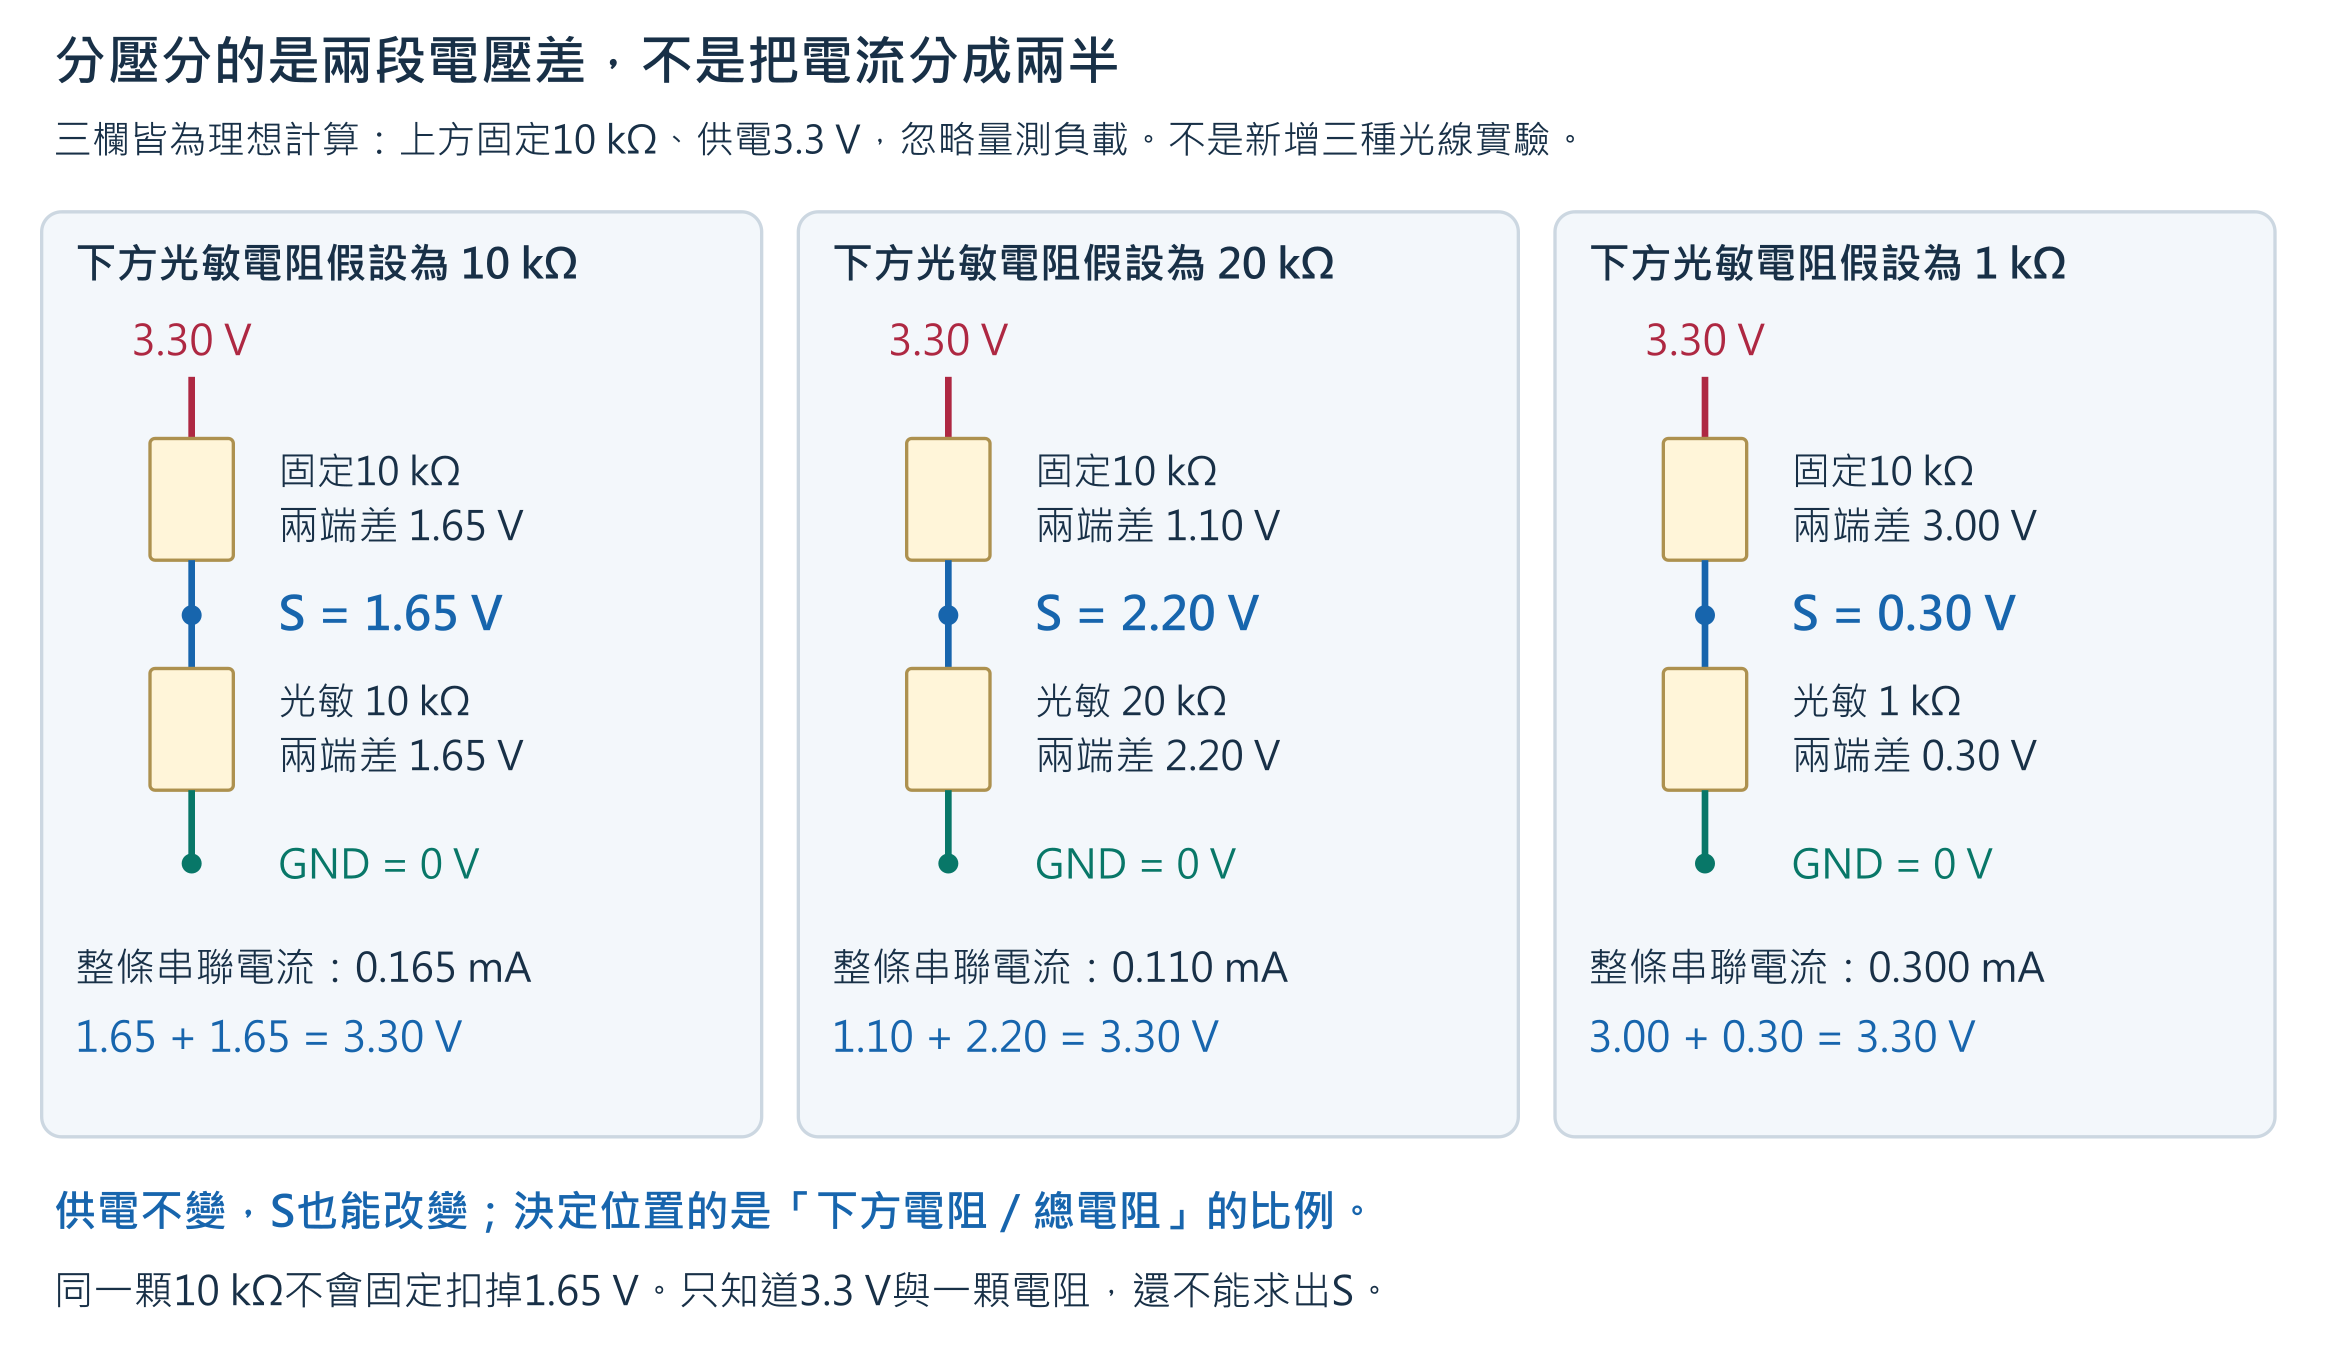

圖中三欄都假設供電3.3 V，圖上的數字是理想計算，不是三次新實驗。
先看每欄S旁的電位，再看兩顆電阻各自的電壓差；兩段相加都回到3.3 V，
但S不一定在一半。這也回答「供電固定，訊號為什麼還會改變」。

### 10.5 反例：10 kΩ不是固定減掉1.65 V的元件

同一顆10 kΩ固定電阻，在前三例兩端的電壓差分別是1.65 V、1.10 V與3.00 V。
因此不能說「10 kΩ會固定降掉1.65 V」；必須知道完整電路與流過的電流。

再作一個紙上比較：把上下兩顆都改成20 kΩ，總電阻變為40 kΩ：

```text
電流 = 3.3 ÷ 40,000 = 0.0000825 A
每顆兩端差 = 0.0000825 × 20,000 = 1.65 V
```

電流變小，但兩顆仍相同，所以依舊各分一半。決定分壓比例的是兩顆電阻的比值，
不是10 kΩ這個數字有特殊能力；不必為此例另外購買或更換實物電阻。
若只有一顆10 kΩ直接跨在理想3.3 V與GND之間，它兩端就是3.3 V，
不會自動變成1.65 V。這同樣是紙上反例，不是新增接線任務。

### 10.6 計算示例：光敏電阻變成5 kΩ

沿用供電3.3 V、上方固定電阻10 kΩ，但假設下方光敏電阻為5 kΩ。
這是理解分壓的紙上示例，完整推導在第13.6節；不必買5 kΩ，也不另交一份同類紙上作業。
學生必做實作在第13.7節，使用材料包已有的1 kΩ與10 kΩ各一顆。


1. 先預測S電壓比兩顆10 kΩ時高還是低，寫出理由。
2. 依「總電阻、電流、每顆兩端電壓差」列出完整計算與單位。
3. 在紙上標出供電端、S與GND的電位，再核對兩段電壓差相加是否回到3.3 V。
4. 檢查串聯電流是否相同，且電壓差比例是否與電阻比例一致；若不符，先查
   kΩ轉Ω、是否漏算另一顆電阻，以及測量點究竟相對哪個參考點。

### 10.7 理論分壓與實際量測的界線

這些例子先假設直流穩定、供電與阻值恰好符合數字、S沒有其他負載分流。
實際量電壓時，電表高內阻會形成很小的額外路徑，供電、阻值、光線與接觸也可能
有差異；不能把計算值寫成已測得值，或只因不同就直接判定故障。

模組正確接入兩顆電阻的供電路徑，不等於用普通導線把3V3短接到GND。
但仍須先斷電核對模組腳位與接線，不能因為模組「有電阻」就省略安全檢查。
電壓量測必須先切到直流V檔，不能在USB供電時沿用Ω檔。

S的1.65 V、2.20 V或0.30 V是**相對GND的類比電壓**，不是ADC raw、光照度lux，
也不在這個實驗中直接當成GPIO的HIGH／LOW。接著先用電表看S的實際變化，
第十一節才說明如何把這個訊號交給ADC。

### 10.8 供電、中間腳、−與S，分別負責什麼

先分清楚「讓模組工作」與「讀取模組結果」：

- **中間排針M**：在本課已核對的這片模組上，接3V3，為整條分壓路徑提供電力。
  M只是本課為未標示排針取的紀錄名稱，不能從「中間」兩字猜成訊號腳。
- **−排針**：接ESP32的GND，提供共同0 V參考與回到供電電路的路徑。
  此處的負號不是−3.3 V，也不是要另外找一個負電源。
- **S排針**：S取自Signal（訊號），把兩顆電阻交接處的電位引到板外，供電表或ADC讀取。
  它是被觀察的訊號，不是另一個供電端。

所以先接中間腳與−，不是只研究電源而忽略S，而是先讓S能產生可觀察的電壓。
模組內部已經有「供電端→固定電阻→S→光敏電阻→GND」的完整路徑；
即使S還沒有接ESP32的GPIO，分壓電路仍可工作。此時用電表比較S與GND，
下一階段再讓ESP32讀同一個S，兩階段研究的是同一個訊號。

例如，在第10.2節的兩顆10 kΩ模型中，接好供電與GND後，S相對GND約為1.65 V。
**不必先接GPIO，才會出現這個分壓電壓。** 電表不是用來補上模組缺少的供電回路，
它在電壓檔以高內阻讀取兩點差異。

如果只接供電與S、把−留空，就少了原本經光敏電阻回到GND的路徑；
可能出現的其他讀值不能套用原來的分壓模型。如果把S接到GND來取代−，
S又會被接近0 V的低阻抗路徑拉住，失去原本要觀察的變化。這些是錯誤接法的
概念比較，不要為了看結果而帶電改接。

### 10.9 先建立供電與GND，S暫時不接ESP32

開始前拔除USB、確認PWR熄滅、電表OFF。先拆除上一個GPIO實驗的TPO導線，
包括ESP32 GPIO端至a12的公對母線，以及e12的公對公延長線；
第12列恢復空置，只留下P3V3與PGND供電測點。
若仍留有先前用來辨認5Vin的線，也在斷電時拆除，不把它當成模組電源。

下表延續第七、八節的座標。線色只方便本範例追線；自己的線色不同，仍以
「一端接哪裡、另一端接哪裡」判定。所有a～e座標都在麵包板同一側，
不跨到中央凹槽另一側的f～j。

| 起點 | 本範例線色 | 終點 | 作用 |
|---|---|---|---|
| ESP32的3V3 | 紅色公對母 | a6 | 建立第6列3V3供電點 |
| 模組中間排針M | 橘色公對母 | c6 | 透過同列接上3V3 |
| e6 | 白色公對公 | 另一端金屬測點保持分開 | 3V3電源量測延長端，不是S |
| ESP32的GND | 棕色公對母 | a3 | 建立第3列共同參考點 |
| 模組−排針 | 綠色公對母 | c3 | 透過同列接上GND |
| e3 | 黑色公對公 | 另一端金屬測點保持分開 | 電表黑表筆的GND測點 |
| 模組S排針 | 黃色公對母 | 公頭暫不插GPIO或其他孔 | 電表紅表筆的訊號測點 |

a6、c6與e6在同一個五孔組內，透過麵包板金屬片相連；可把它們想成同一個
電氣節點的三個入口。不是3.3 V經過a6、c6、e6就會逐段被扣掉。
第3列同理，但第3列與第6列不能用普通導線直接相接。
原本若用b6、b3，斷電後改用c6、c3仍是同一個五孔組；這只是讓接頭較好安放，
不是改變電路。這個等效關係只限同一列的a～e，不能跨中央凹槽套用到f～j。

先沿供電線從3V3追到a6、c6與M，再沿GND線從GND追到a3、c3與−，
最後確認S只接黃色延長線。確認每個母頭只套住一根排針、每個公頭插在正確孔位、
沒有裸露金屬互碰。若任一條線追不回起點，保持斷電，先修正而不猜測。
未使用的白色3V3延長端也要獨立安置，不能碰到黑色GND或黃色S端。

### 10.10 電表要碰哪裡；一個人如何操作

這次量的是「S相對GND」，不是重做「3V3相對GND」。先在斷電狀態下核對：

| 電表部位 | 本次設定或接觸位置 | 理由 |
|---|---|---|
| 黑表筆插頭 | 電表COM孔 | 量測的參考端 |
| 紅表筆插頭 | 電表VΩmA孔 | 使用電壓量測電路；10A孔保持空置 |
| 旋鈕 | 直流V⎓的20 V量程 | 顯示數伏特的兩點差；不是輸出20 V |
| 黑表筆尖端 | 黑色e3延長線的外露金屬端 | 此端已追線確認為GND |
| 紅表筆尖端 | 黃色S延長線的外露金屬端 | 此端才是要觀察的訊號 |

白線來自e6／3V3；黑線來自e3／GND；黃線來自S。不要只用
「黑碰白、紅碰黑」記憶動作，要先說出那樣量的是哪兩個電氣位置。

例如假設供電為3.3 V，紅表筆碰GND黑線、黑表筆碰3V3白線，
電表比較的是「0 V − 3.3 V」，所以預期約−3.3 V。這是**供電電壓的反向量測**，
不是S訊號，也不代表要交換模組的供電線。要改量S，先移開表筆，
改為黑表筆碰GND黑線、紅表筆碰S黃線；模組接線不變。

若沒有夾具，將以下動作分開進行，不必一邊捏線、一邊按表筆、一邊遮光：

1. USB仍拔除。在乾燥、不導電桌面上分開安置三個外露延長端。
   可用現有膠帶固定導線的塑膠絕緣處；金屬測點保持可碰觸且彼此不相碰。
   這是安置方法，不要求購買新工具。
2. 先放下兩支表筆，再接回ESP32背面標示COM的USB接頭。
   確認PWR亮且沒有發熱、焦味等異常；有異常立即拔USB。
3. 一手握一支表筆的絕緣握柄，手指留在護指擋片後方。
   黑表筆輕碰GND延長端，紅表筆輕碰S延長端；不要用手捏裸金屬，
   不把尖端硬插進麵包板孔，也不直接擠在ESP32相鄰排針間量測。
4. 先在室內光下讀取並記錄穩定的電壓與完整測點。若讀值一直跳，
   先移開表筆、拔USB，再檢查接觸與固定方式；不要直接判定光線在變。
5. 移開兩支表筆並放下，才安放不導電、不透光的紙或布。遮光物須能自行保持位置，
   不碰裸露接點、不壓彎光敏電阻引腳、不拉動導線，再拿起表筆量相同兩點。
   若安放遮光物需要搬動模組或線路，先拔USB；重新確認後才供電量測。
6. 再放下表筆、移開遮光物，以相同方法量第三次。記錄「室內光→遮光→恢復室內光」，
   不把遮光同時造成的接觸改變當成感測結果。
7. 記完後移開兩支表筆、拔除USB、確認PWR熄滅，電表轉OFF。
   S維持不接GPIO；第十一、十二節才建立ADC連線。

「恢復室內光」是回到第一種條件，並不是第三種光線；不另加手機手電筒測試。

正常預期是：在本課已核對的分壓接法下，遮光使S電壓升高，移開遮光物後下降；
數字不必恰好1.65 V。若是負值、明顯高於3.3 V或始終無法穩定接觸，
先移開表筆、拔USB，核對量程、表筆方向與三個端點，不改用電流檔。

完成條件是三筆附有光線條件、測點、量程與V單位的紀錄，以及一句有根據的
變化方向說明；不以「有數字」或「剛好接近例子」取代判讀。

### 10.11 實際觀察案例：0.62 V、1.75 V與0.55 V

以下是本課KY018-T01在上述接法下，依直流20 V、紅表筆碰S、黑表筆碰GND的
引導，以手持表筆回報的觀察案例。它不是官方標準值，也不是學生練習的答案；
讀值來自操作者文字回報，沒有同時拍攝表面刻度或自動記錄供電。

| 先後 | 光線條件 | 回報的S相對GND電壓 | 可觀察的變化 |
|---|---|---:|---|
| 1 | 一般室內光 | 0.62 V | 作為這一輪的起點 |
| 2 | 遮光後 | 1.75 V | 比起點升高 |
| 3 | 移開遮光物 | 0.55 V | 比遮光時降低 |

以第二筆為例，意思是「紅表筆所在的S，比黑表筆所在的GND高1.75 V」。
不是光敏電阻變成1.75 Ω，不是75%亮度，也還沒有ESP32的ADC讀值。
這個升高再降低的過程，支持**這片模組在此接法中有基本明暗電壓反應**。

第三筆比第一筆低0.07 V。光照位置或手持接觸改變是可能原因，但這三筆不能證明
是哪一個原因，也不能自行訂一個容許差就宣稱精度通過。接著應在固定條件下比較，
保留原始值，不把0.55改成0.62來讓結果整齊。

這三筆也不能證明實際照度lux、所有同型模組都相同，或之前20k／200k電阻檔
的差異已經解決。它們只建立S電壓的觀察基礎；下一步才由ESP32讀取它。


<a id="w3-adc-concept"></a>

## 十一、ADC：讓ESP32讀取剛才的S電壓

### 11.1 電表的兩個測量位置，在ADC中分別在哪裡

前一階段是人看電表，知道遮光使S電壓改變。接下來讓ESP32也能取得這個變化，
之後程式才有資料可以使用。這不是再找一個新的感測器，也不是重新供應另一種電壓。

ADC是Analog-to-Digital Converter（類比數位轉換器）。本次使用ESP32-S3晶片內建的
ADC，不用另買一個轉換器。它將輸入腳相對GND的類比電壓，轉成程式可處理的整數。
類比電壓可以在範圍內連續變化；ADC則用有限個數字階級表示它。

#### 先從已經做過的電表量測理解

回想第10.11節的室內光案例：紅表筆碰S、黑表筆碰GND，電表顯示0.62 V。
這個數字是在說「S比GND高0.62 V」，不是S自己帶著一個不需要參考點的數字。

```text
電表讀值 = 紅表筆所在位置的電位 − 黑表筆所在位置的電位
         = S的電位 − GND的電位
本例以GND為0 V：0.62 V − 0 V = 0.62 V
```

延續「尺」的比喻：GND是尺的零點，S是要量的位置。只知道紅表筆在S，
卻不知道黑表筆在哪裡，便不能完整描述這次量的電壓差。

#### 換成ADC，並不是少量了GND

下面把原本分開畫的兩條外部線，放回同一個量測關係。**上半部是電表，下半部是
ESP32內部ADC的功能示意；兩者是對照，不是要求另外搭出一個電表電路。**

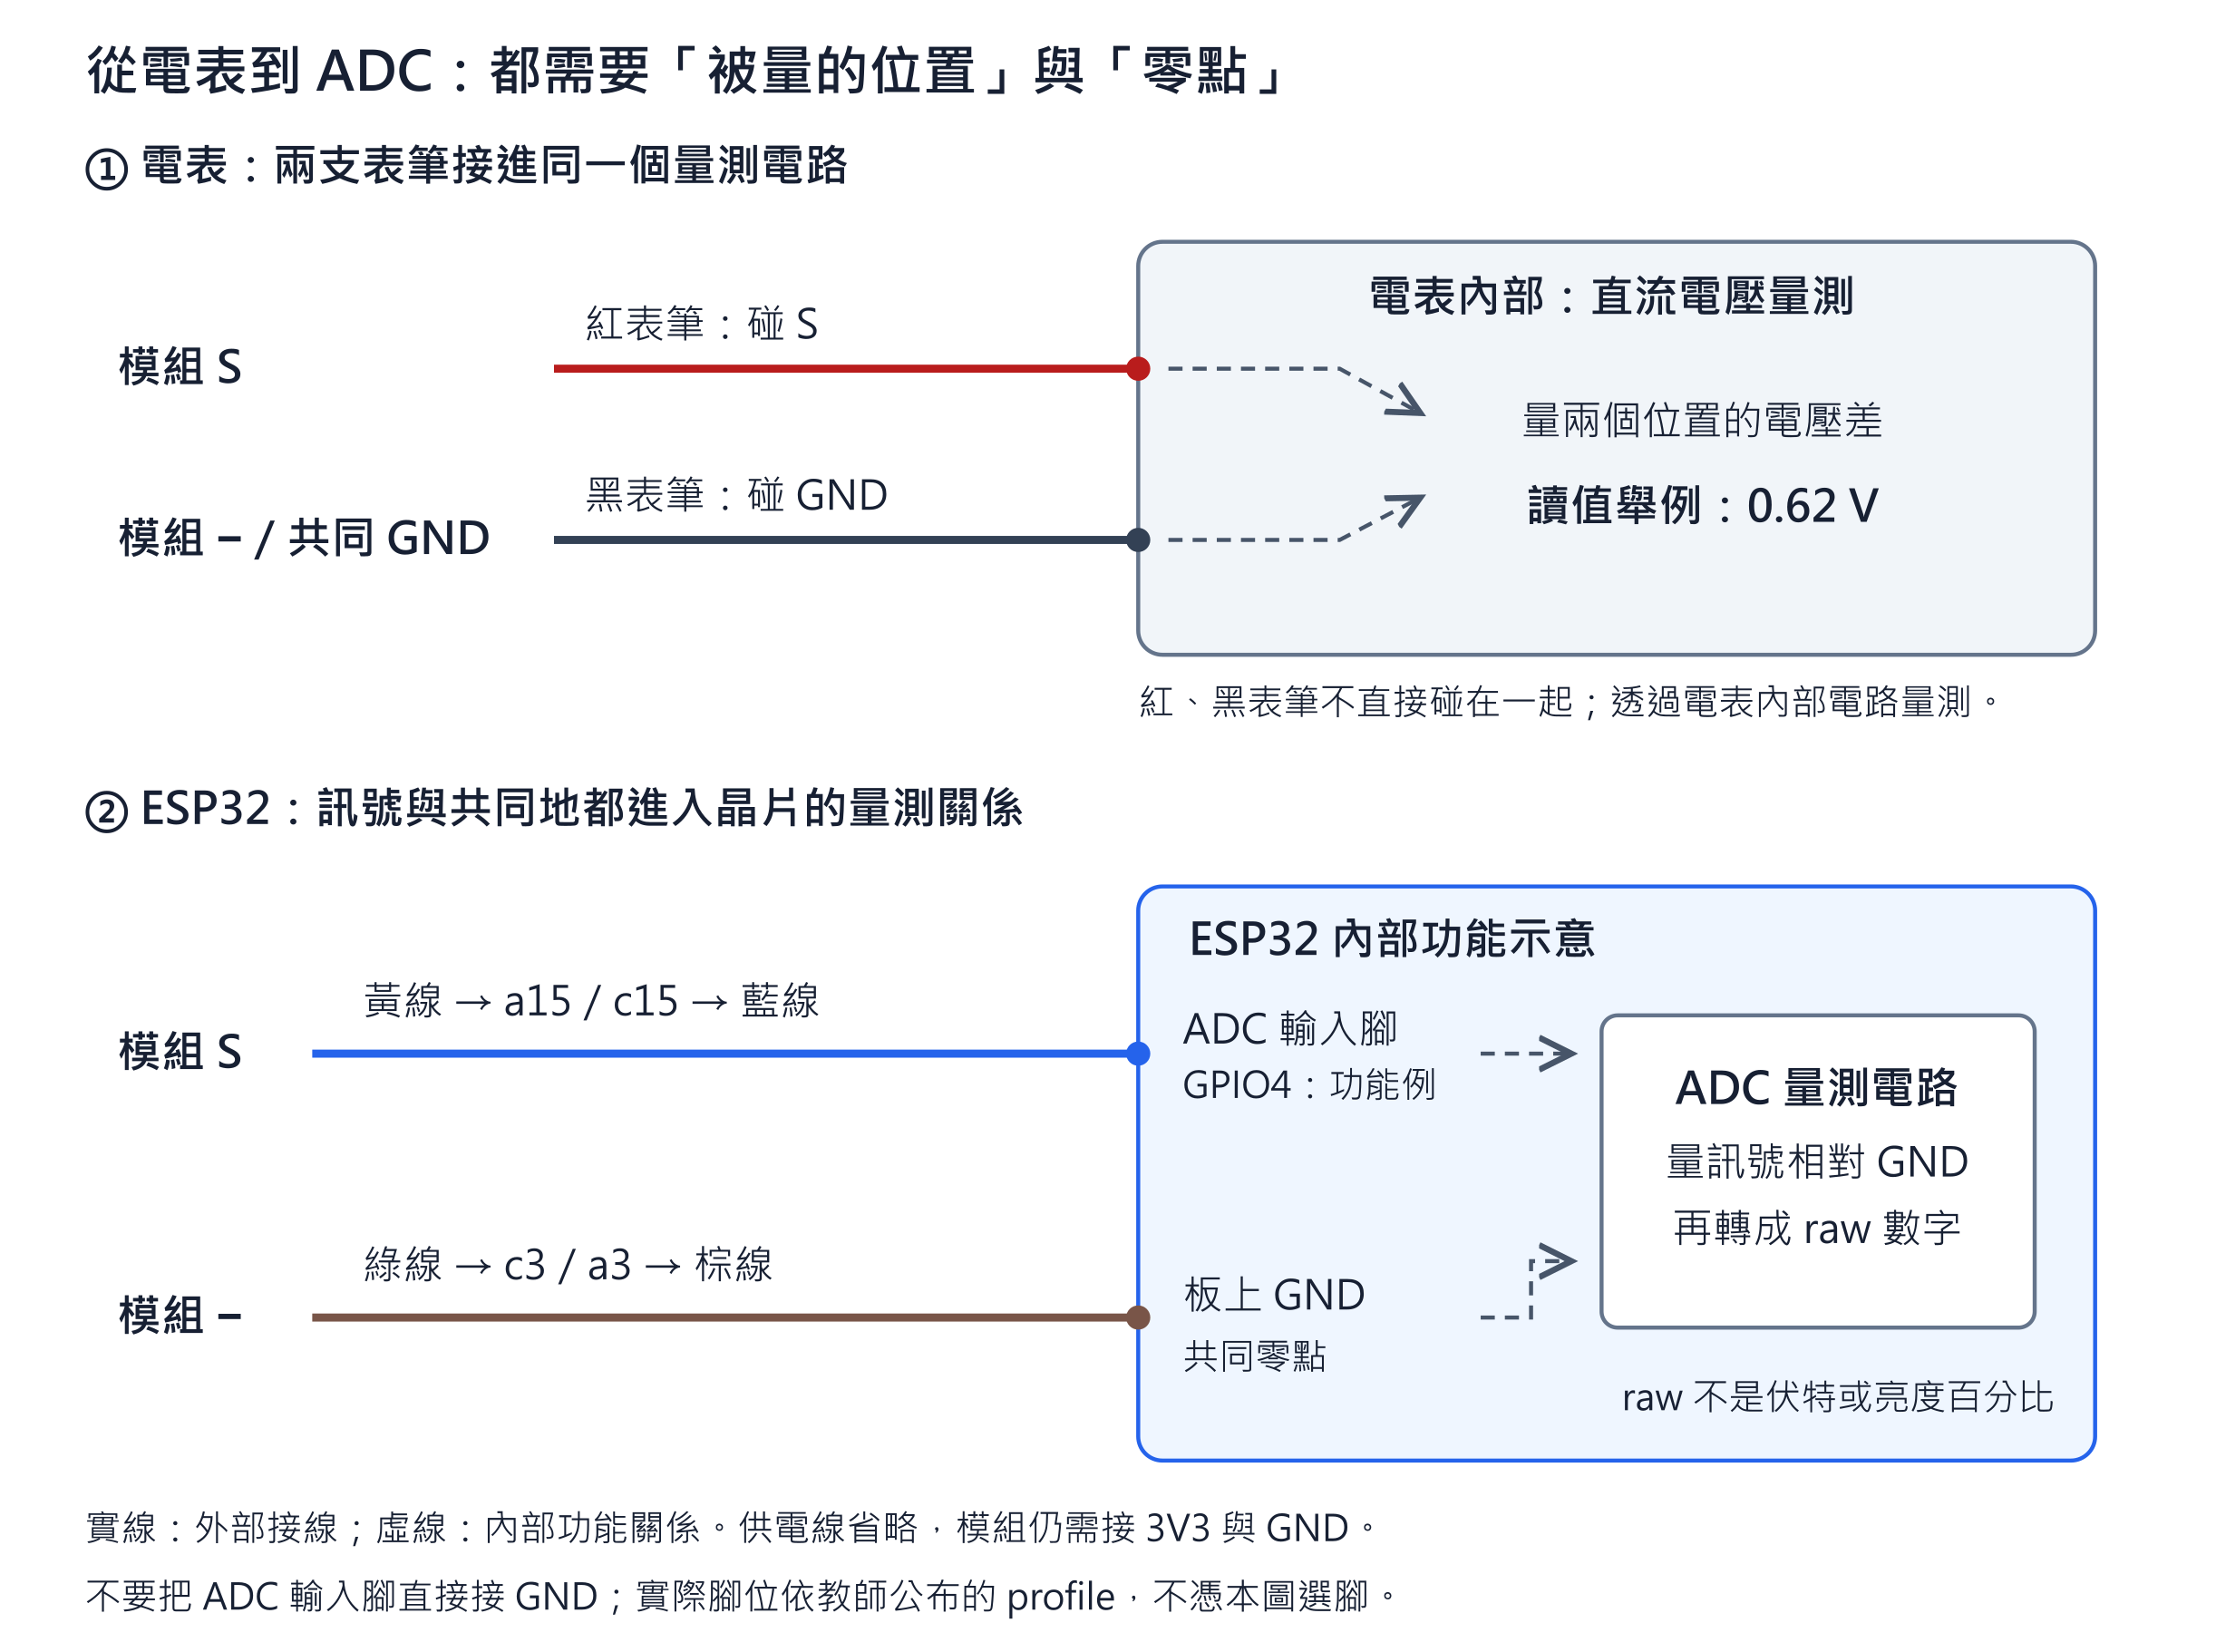

| 原本使用電表 | 改由ESP32的ADC讀取 | 本次作用 |
|---|---|---|
| 紅表筆接S | S接到已設定的ADC輸入GPIO | 提供要觀察的訊號位置 |
| 黑表筆接GND | 模組−與ESP32 GND相連；晶片內部已有GND連接 | 讓模組與ADC使用共同的0 V基準 |
| 電表顯示V | 程式取得ADC raw整數 | 將觀察結果交給人或程式；單位與處理方式不同 |

這是**功能上的類比**：ADC不是把一支完整萬用電表藏進晶片，也不是已校準的精密
電表。這裡稱GND為「共同零點」，不表示ADC內部用來決定轉換刻度的參考電壓就是0 V。

#### 外部的兩條線，究竟在哪裡一起作用

以圖中的GPIO4功能例子追線：

1. 模組S經「黃線→a15／c15→藍線」，把S訊號帶到GPIO4。
2. 模組−經「綠線→c3／a3→棕線」，與ESP32的GND形成共同零點。
3. 程式使用這個ADC通道取樣時，**晶片內部的ADC量測電路**讀取輸入相對晶片GND
   的電壓，再轉成raw。這部分在晶片內已經做好，不需要學生另外接一條線。

因此「串在一起」不是指把兩根外部導線的自由端接在一起，而是指**同一個ADC
量測功能同時用到訊號位置與共同零點**。看不到晶片內部連線，不等於GND沒有參與。
GPIO4在本圖是晶片功能例子；實際接哪根GPIO，仍須通過第11.3節的課程profile條件。

#### 量測不是把S直接接到GND

電表在直流V檔，是透過內部高電阻量測電路比較兩個位置；ADC則透過內部取樣與
轉換電路取得讀值。兩者都不能畫成一條普通導線，直接把輸入短接到GND。
這也不表示工具完全不影響電路；ADC取樣與電表量測都有各自的輸入特性與限制。

假如用普通導線把S直接接GND，S會被低阻抗路徑拉到接近0 V，原本的分壓條件
也被改變。此時不再是正常觀察光線變化。這是紙上反例，**不要實際短接測試**。

模組原本的「供電端→固定電阻→S→光敏電阻→GND」路徑仍保留。
ADC是來觀察S，不是靠GPIO4為整片模組供電；不能省略模組的3V3或GND接線。

#### 用0.62 V與1.75 V再看一次

在室內光0.62 V的案例，ADC要觀察的是S相對共同GND的0.62 V差值；
遮光後電表回報1.75 V，表示這個差值變大。只要在可量測範圍內且設定與接線正確，
預期raw也往較大的方向變化，但**實際raw是多少，必須從Serial取得**。

不能把0.62或1.75直接寫進raw紀錄，也不能在沒有ADC輸出的情況下宣稱已驗證。
下一節先認識raw的意義，再操作程式。

閱讀檢查：在圖中指出「被量的位置」與「共同零點」，並說明為什麼不需要、
也不應另用普通導線把GPIO4與GND直接相接。

### 11.2 raw、12-bit與0～4095各是什麼

[Espressif Arduino-ESP32 ADC官方API](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/adc.html)
說明了本次使用的方法：

| 名稱或程式 | 本次作用 | 不能誤解成 |
|---|---|---|
| `analogRead(pin)` | 讀指定ADC腳，回傳尚未校準的raw value（原始值） | 直接回傳精確伏特數 |
| `analogReadResolution(12)` | 設定12-bit解析度；2的12次方為4096個整數階級，編號0～4095 | 輸入可接12 V |
| `ADC_11db` | 設定ADC輸入衰減，調整可量測範圍；S3官方表列約0～3100 mV | 可輸入11 V，或保護GPIO免受過壓 |
| `light_raw` | 本程式替這次讀值取的欄位名稱 | 光照度、電阻或亮度百分比 |

bit是二進位位元；此處只需知道位元數決定可表示多少個階級。
例如`light_raw=2048`是格式與單位辨識的例子，不是本次實測值。
它不代表2048 V、2048 Ω、2048 lux，也不能直接寫成「50%亮」。

前面量到的0.62 V、1.75 V與0.55 V不應直接乘一個比例，填成「已取得的ADC raw」。
本週先比較**電表電壓升高時，raw是否也往較大的方向變化**；
實際raw必須由目前板卡、輸入設定與光線條件下的Serial取得。

**飽和**是輸入到達可辨識範圍端點後，數字已無法繼續表示更大的變化。
在這個設定下，S若靠近3.3 V，已超過官方表列約3.1 V的量測範圍，
raw可能靠近4095。這不表示4095能反推出精確3.3 V；
「GPIO允許的輸入電壓」與「ADC可準確分辨的量測範圍」是不同限制。

### 11.3 不把所有GPIO當成ADC輸入

ESP32-S3的[官方datasheet](https://www.espressif.com/sites/default/files/documentation/esp32-s3_datasheet_en.pdf)
把GPIO4列為`ADC1_CH3`：ADC1是轉換器名稱，CH3是其通道編號。
但官方晶片具備功能，不等於本課每片開發板、接線與程式都已實測。

Week 2用GPIO4讀按鈕時，使用的是數位輸入與`INPUT_PULLUP`。
本實驗需要ADC類比讀取，不沿用按鈕程式，也不額外啟用按鈕的內部上拉電阻，
以免改變原本的分壓條件。按鈕測試成功不能當成ADC測試成功。

學生只使用教師公布的`PIN_LIGHT`；未公布時程式保留`-1`，
不把GPIO4這個官方功能例子直接當作接線答案。教師候選腳位驗證與正式學生操作
是兩種不同狀態；尚未取得指定板卡ADC驗證與公布值時，不開始學生端GPIO接線。

### 11.4 保留S測點，再準備ADC訊號線

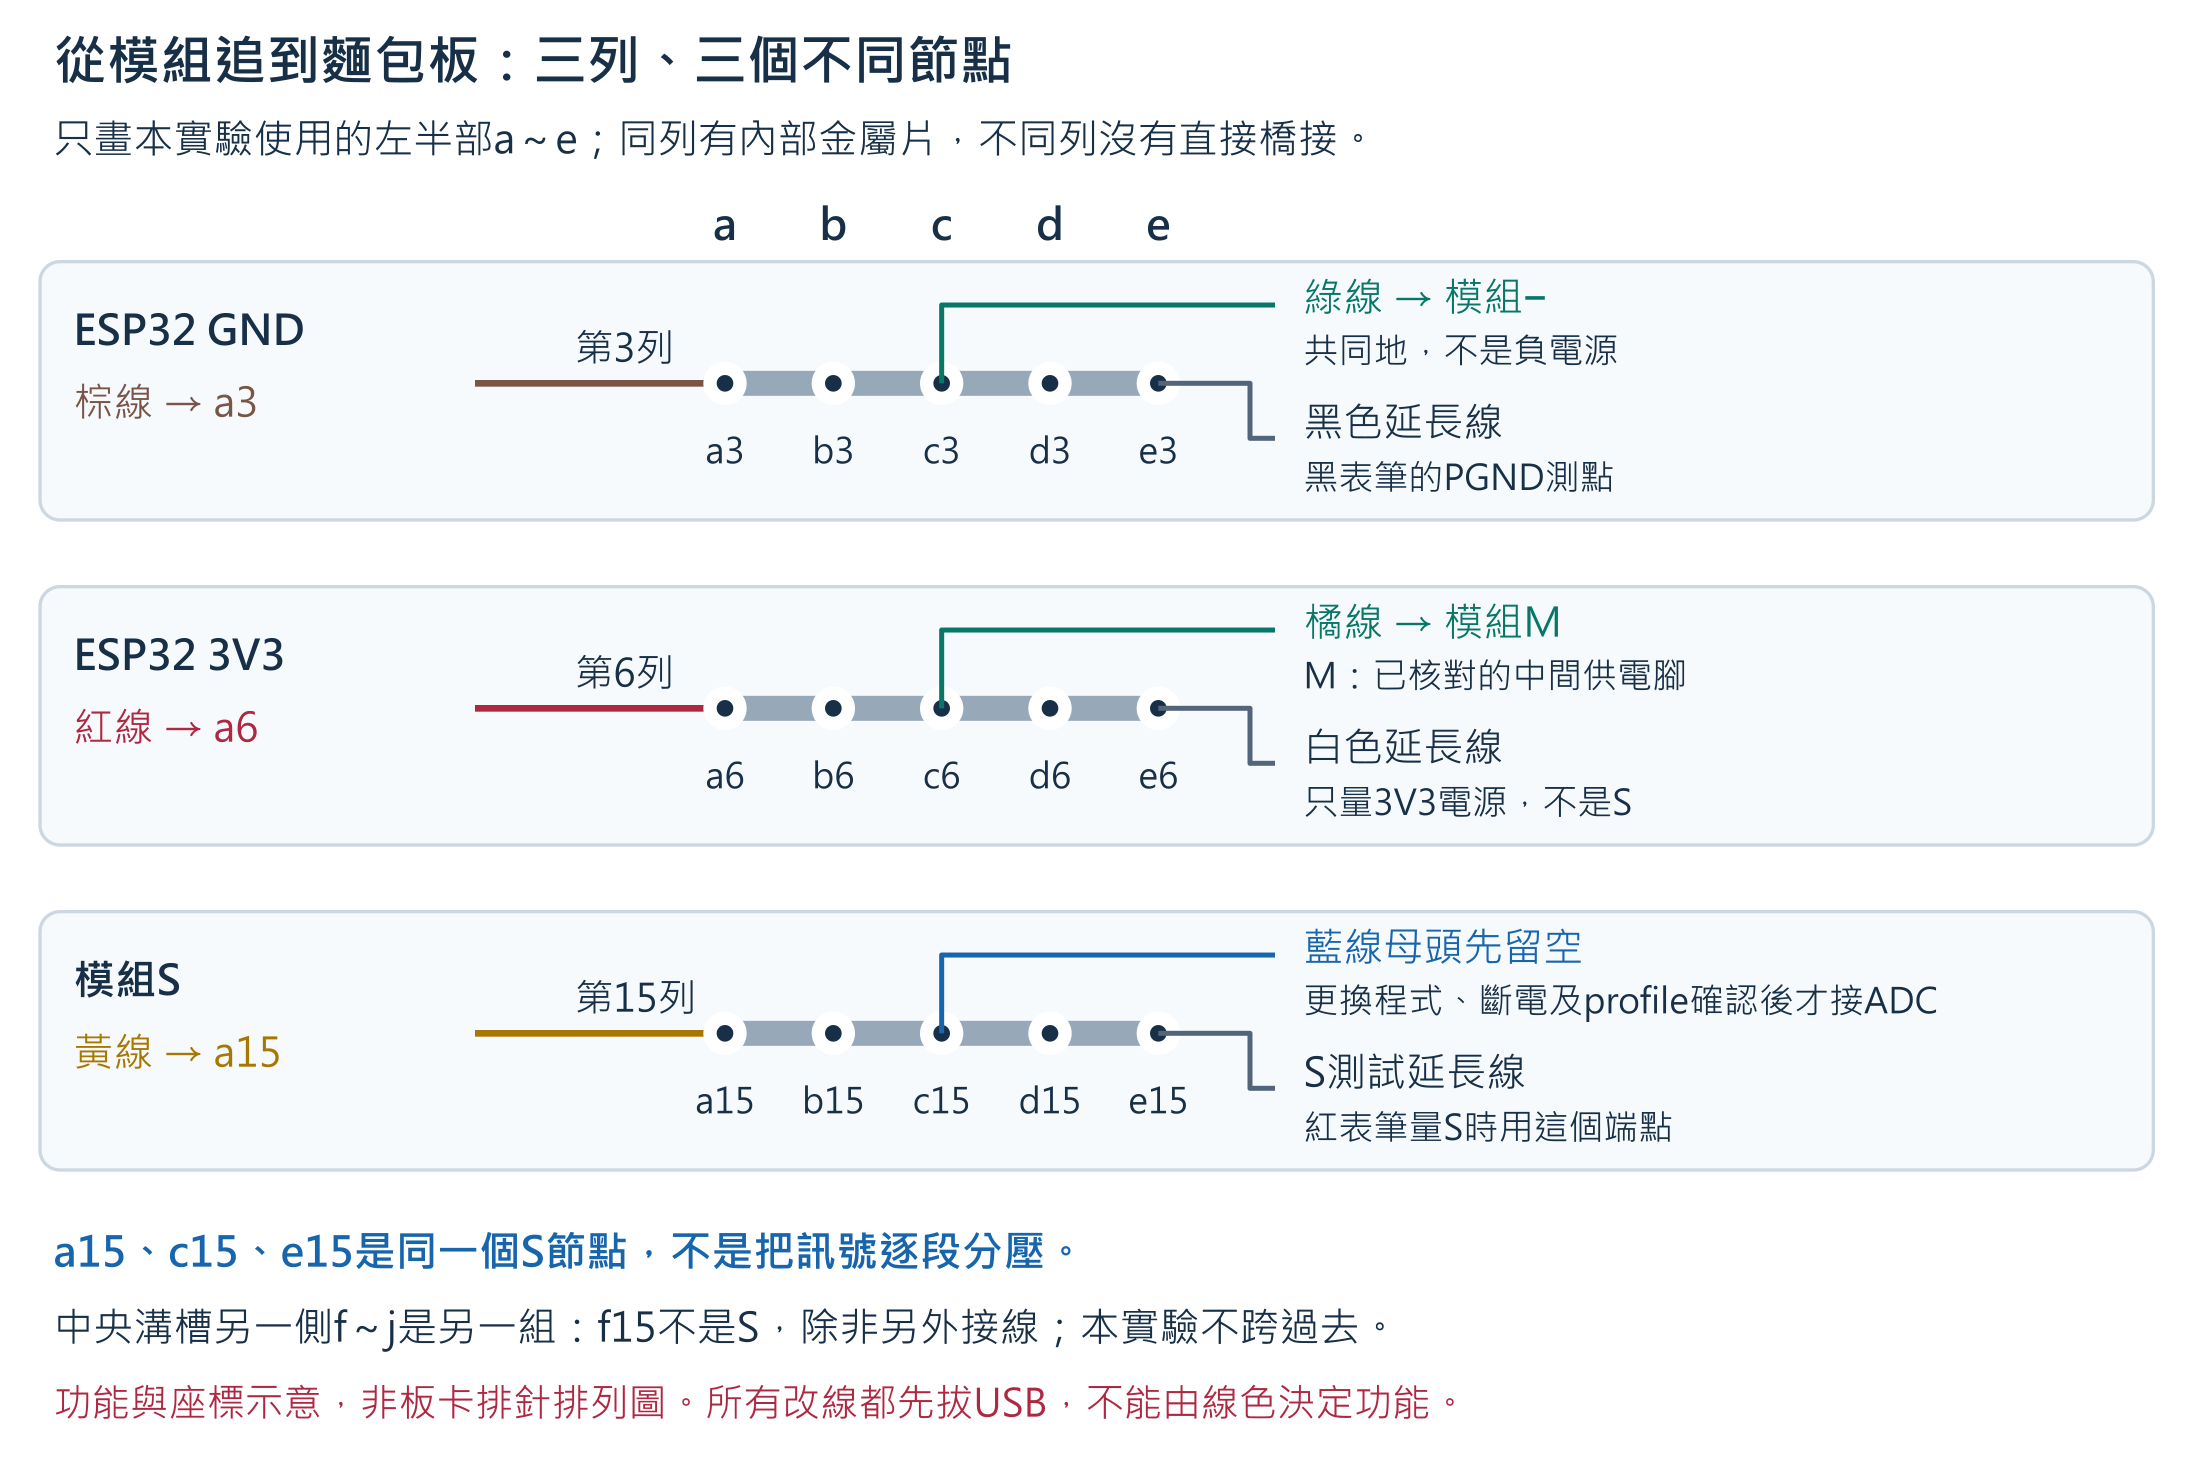

這是第11.4節完成後的**孔位示意**，不是板卡照片，也不表示現在就能接ADC。
圖中ESP32名稱只標功能，不代表排針的實際左右排列。藍線母頭先留空；
第十二節更換程式、再次斷電並確認profile後，才接公布的ADC腳。
中間排針M是本課的紀錄名稱，不是保證實物印有+或VCC。

讀圖時先找列號，再找字母，最後沿線回到實物絲印：
第6列只分配3V3，第3列只分配GND，第15列只分接S。
`a15→c15→e15`不是三個分壓階段，而是同一金屬接點的三個入口。

**公頭**有外露金屬針，可插麵包板孔；**母頭**有插孔，可套住模組或ESP32排針。
母對母線的兩端都有孔，因此可以直接連接兩根排針；但若兩端都套住，
不容易再安全地用表筆量S。本實驗要比較電表與ADC，因此主要接法使用現有
麵包板五孔組，保留獨立的S量測延長端，不必添購分接器。

開始前：已完成第10.10節，USB拔除、PWR熄滅、電表OFF；供電與GND接線保留。
不要把GPIO5的舊第12列輸出測點當成S。先確認第15列a～e全部空置：

| 端點 | 接法 | 本步驟的狀態 |
|---|---|---|
| 模組S上的原公對母延長線 | 原本懸空的公頭插a15 | 將S引到獨立五孔組 |
| 另一條公對母線（本例藍色） | 公頭插c15；母頭暫留空、保持分開 | 預備通往`PIN_LIGHT`，先不套ESP32 |
| 一條公對公線 | 一端插e15；另一端獨立安置作表筆測點 | 延長S，方便量電壓 |
| 第6列供電與第3列GND | 維持第10.9節接法 | 不接5Vin，不更換電源 |

a15、c15與e15是同一個S節點的三個入口：一個來自模組，一個預備給ADC，
一個給電表。不是把訊號依序分成三份；電表與ADC都相對共同GND觀察這個節點。

1. 先逐線追查「S→黃線→a15／c15→藍色預備線」及「S→a15→e15測點」。
   確認第15列沒有其他電源、GPIO輸出或按鈕線，且與第3、6列沒有普通導線直連。
2. 在完全斷電時，以通斷檔確認S延長測點與模組S相通；這兩點本來就應相連。
   若不通，保持斷電，先核對孔位與接觸。此檢查只確認連線，不代表ADC驗證通過。
3. 移開表筆、電表OFF。先讓通往ESP32的母頭留空；下一節先更換程式，
   再斷電接上已公布的ADC腳，避免舊程式的GPIO設定影響S。
4. 在自己的紀錄中寫出S測點為第15列、GND為第3列，及每條線的實際端點與線色。

<a id="w3-adc-practice"></a>

## 十二、實驗五：取得KY-018原始ADC資料

目的不是再證明遮光會改變S，而是讓ESP32以數字記下同一個S節點，並與電表的V值比較。
先保留室內光與遮光兩種條件的預測：電表讀值改變時，raw預期如何改變？
接著看程式如何設定取樣並留下證據；raw不是電壓單位，也不會自行代表亮或暗。

### 先讀懂程式

- `PIN_LIGHT`是KY-018訊號所接的ADC GPIO；正式profile未公布時保持`-1`。
  這個名字讓程式表達「讀光敏訊號」，不是另一根實體排針。`-1`表示尚未設定，
  不是板上有一根負數腳；若獲准設定為4，4指GPIO編號，不是4 V或從旁邊數第4根腳。
- `DEVICE_ID`是資料來源代碼。把`CHANGE_ME`改成課堂指定的非個資代碼，不使用姓名
  或學號。這樣將來合併多片板的紀錄，仍能辨認來源。
- `profileReady()`只檢查`PIN_LIGHT`是否大於或等於0；保留`-1`時就印出阻擋訊息，
  不呼叫ADC讀取。通過這個檢查不保證該數字是可用ADC腳，也不會自行驗證接線，
  因此仍須使用教師公布的profile。
- `analogReadResolution(12)`將`analogRead()`輸出設定為12-bit的0～4095。
- `analogSetPinAttenuation(..., ADC_11db)`設定本次ADC輸入範圍；它不會把GPIO變成
  11 V耐壓腳，也不允許輸入超過3.3 V。
- `SAMPLE_INTERVAL_MS=500`表示約每500 ms取一筆，也就是約每秒兩筆。
  程式用`millis()`取得開機後經過的毫秒，等間隔到了才取下一筆，
  不把每一次執行`loop()`都算成一個樣本。
- `analogRead(PIN_LIGHT)`把當下讀值存入`lightRaw`，再用`Serial.printf(...)`
  按固定欄位印出；取樣不等於已校正，也不等於已判定環境明暗。

**資料怎麼填進log？** `Serial.printf`先給含空位的格式文字，再按順序填入值：
`%s`放裝置代碼文字，兩個`%lu`分別放無號長整數`sampleNumber`與`now`，
最後的`%d`放整數`lightRaw`。因此Serial顯示的`light_raw`和程式變數`lightRaw`
是同一次讀值的兩種命名位置，不是另外讀了一次感測器。
`sampleNumber++`每次實際取樣才加1，不是每跑一次loop就加1。

每行保留device、sample、uptime與light_raw，尚未加入DARK／NORMAL／BRIGHT分類、
`valid`或`reason`；那些是Week 4校正後的內容。

### 完整ADC取樣程式

下方是Arduino C++完整程式，保留`-1`安全閘門。先讀完程式，再依第十二節步驟1
開啟對應sketch、更換程式，最後斷電接入已公布的ADC腳；不要跳過這個順序。


In [ ]:
// Fill in only the ADC GPIO published in the verified course hardware profile.
// Keep -1 when no verified profile is available.
const int PIN_LIGHT = -1;
const unsigned long SAMPLE_INTERVAL_MS = 500;
const char* DEVICE_ID = "CHANGE_ME";

unsigned long lastSampleMs = 0;
unsigned long sampleNumber = 0;

bool profileReady() {
  return PIN_LIGHT >= 0;
}

void setup() {
  Serial.begin(115200);
  delay(500);

  if (!profileReady()) {
    Serial.println("week=3 sensor=ky018 status=blocked reason=gpio_profile_missing");
    return;
  }

  analogReadResolution(12);
  analogSetPinAttenuation(PIN_LIGHT, ADC_11db);
  Serial.printf(
    "week=3 sensor=ky018 status=ready device=%s pin_light=%d "
    "adc_bits=12 interval_ms=%lu\n",
    DEVICE_ID,
    PIN_LIGHT,
    SAMPLE_INTERVAL_MS
  );
}

void loop() {
  if (!profileReady()) return;

  unsigned long now = millis();
  if (now - lastSampleMs < SAMPLE_INTERVAL_MS) return;
  lastSampleMs = now;
  sampleNumber++;

  int lightRaw = analogRead(PIN_LIGHT);
  Serial.printf(
    "device=%s sample=%lu uptime_ms=%lu light_raw=%d\n",
    DEVICE_ID,
    sampleNumber,
    now,
    lightRaw
  );
}


### Verify的21%與6%，各自在算什麼

Verify是先在電腦上編譯程式，不會把程式寫入ESP32，也不能確認目前接線是否正確。
例如一次編譯曾出現以下摘要；它是解讀格式的案例，不要求學生得到相同大小：

```text
Sketch uses 286973 bytes (21%) of program storage space. Maximum is 1310720 bytes.
Global variables use 21936 bytes (6%) of dynamic memory, leaving 305744 bytes for local variables. Maximum is 327680 bytes.
```

**第一行看程式儲存空間。** `Sketch uses 286973 bytes`表示編譯結果計入的程式
儲存用量為286,973 bytes。`Maximum is 1310720 bytes`是目前編譯設定給這個程式的
容量上限；21%是IDE相對這個上限顯示的整數百分比，不是整片16 MB Flash的21%。

Flash會依partition table（分割表）分配不同用途的區域。可以把16 MB Flash想成
整棟倉庫，程式分割區是其中分配給這支程式的一間房間。摘要是在看這間房間用了多少，
不是所有房間合計用了多少。上限改變可能來自編譯設定，不代表實體Flash突然變小。
詳見[Espressif分割表說明](https://docs.espressif.com/projects/arduino-esp32/en/latest/tutorials/partition_table.html)。

**第二行看RAM的編譯時配置。** `Global variables use 21936 bytes`表示摘要計入的
靜態RAM用量為21,936 bytes；6%是相對報告中的327,680 bytes上限。
RAM像程式執行時的工作桌，與Flash的程式儲藏空間不同。

`leaving 305744 bytes`是此階段算出的剩餘容量：
327,680 − 21,936 = 305,744。之後程式執行還會使用函式呼叫、暫存資料與動態配置等
空間，因此這不是「程式跑起來永遠只用6%RAM」的保證，也不是8 MB PSRAM的6%。

這兩個百分比的分母不同，不能相加成「整片板子用了27%」。
比較兩次摘要前，先確認程式版本、Board與分割設定是否相同，不只比較百分比大小。
本次依Week 2已核對的板卡設定操作，不為了讓百分比下降而任意更換分割方式。

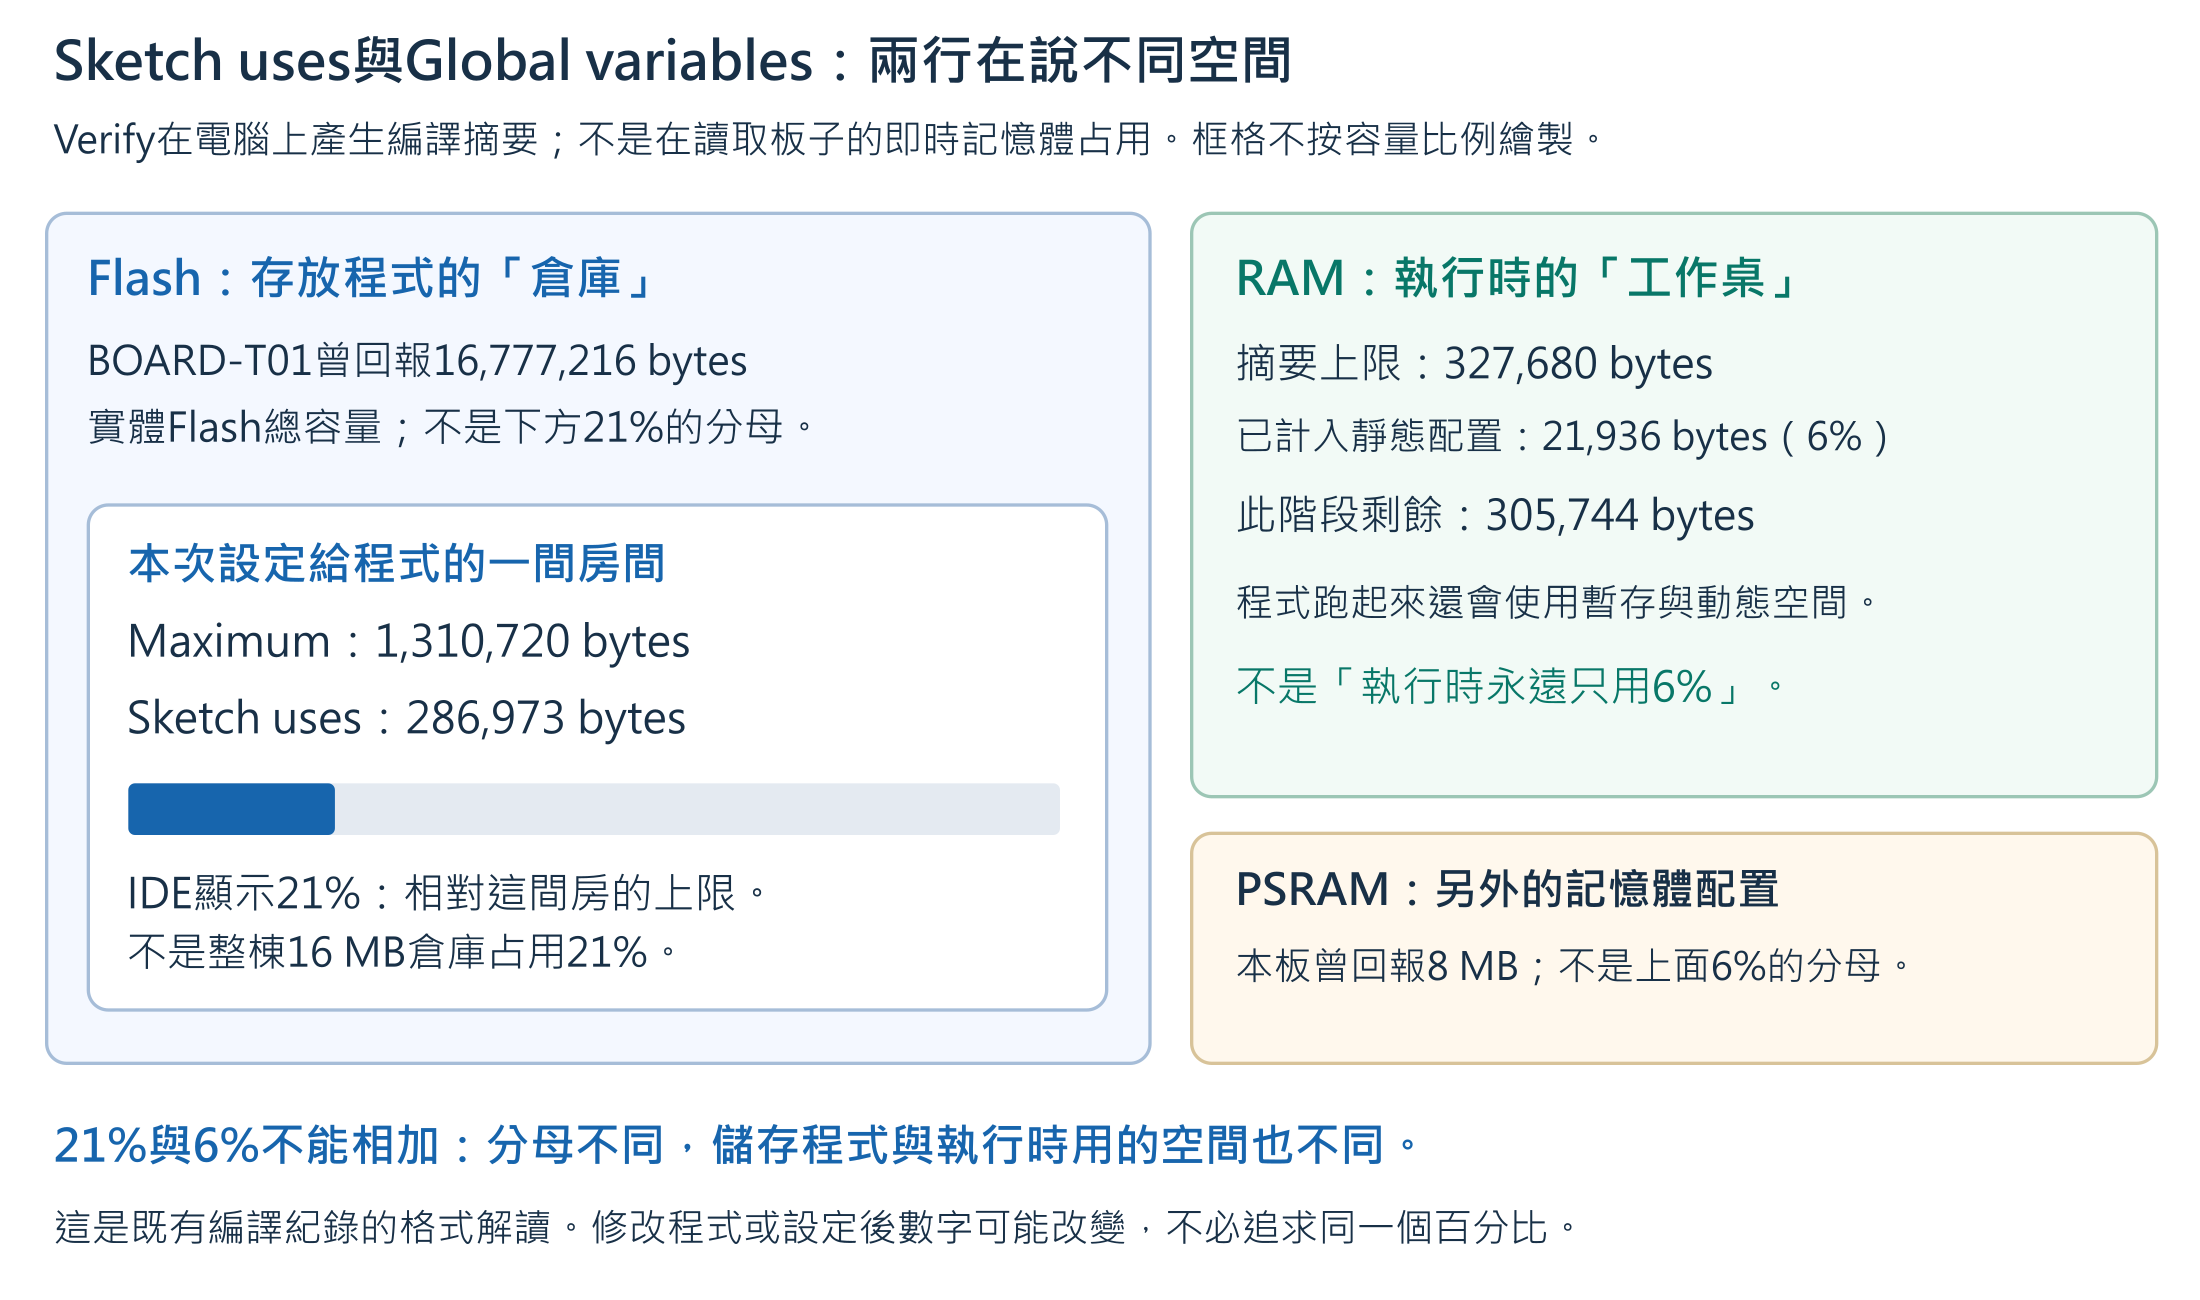

圖中的兩行摘要來自本節既有編譯紀錄，不是現在讀取板子得到的即時占用率。
可以把正確說法說完整：「這次編譯的程式占所選程式區上限的21%，
摘要列出的靜態RAM配置占其報告上限的6%。」這與ESP32記憶體有關，
但不是整片Flash用了21%、也不是全部RAM執行時只用6%。
[Arduino記憶體說明](https://docs.arduino.cc/learn/programming/memory-guide/)

### 步驟1：先更換程式，再斷電接入S

1. 保持第11.4節的ADC預備線母頭未接ESP32，確認沒有其他模組線接GPIO。
   模組供電與GND可保留；電表表筆移開、旋鈕OFF，所有外露測點保持分開。
   未公布ADC profile時停在閱讀與Verify，不往下接電Upload。
2. 在Arduino IDE以`File → Open`開啟
   [`week03_ky018_raw.ino`](../../examples/week03_ky018_raw/week03_ky018_raw.ino)。
   將`PIN_LIGHT=-1`改成教師公布值，修改`DEVICE_ID`，以`File → Save`儲存。
   完整程式與前一格相同，不只複製一個`analogRead()`片段。
   若要保留原版，使用`File → Save As`另存到自己的實驗程式資料夾，並記錄新檔名；
   不把不同版本的Upload結果混成同一支程式。
   開啟或另存sketch後，確認上方Board選擇不是空白的`Select Board`。
   在`Tools → Board`選擇ESP32套件內的`ESP32S3 Dev Module`；此時只做Verify，
   不必為了選板卡先接USB。Board是編譯目標，不是電腦已驗證實物型號的證明。
   依Week 2已確認設定核對`Tools → Flash Size`為16 MB、`PSRAM`為OPI PSRAM，
   COM接頭路徑使用`USB CDC On Boot: Disabled`，Upload Speed為115200。
   選單說明見[Espressif Tools Menu](https://docs.espressif.com/projects/arduino-esp32/en/latest/guides/tools_menu.html)。
3. 點左上角勾號`Verify`，等待編譯結束。出現`Sketch uses...`與
   `Global variables use...`等容量摘要且沒有編譯錯誤，才往下。
   這只證明程式可編譯，不代表接線或ADC讀值正確。
4. 接回板背COM接頭的USB，確認PWR亮、沒有異常。
   在`Tools → Port`選擇本次插入板卡後出現的實際COM埠。
   COM編號依本台電腦當下辨識，不固定為COM8；僅顯示COM編號也不等於連線失敗。
5. 關閉Serial Monitor，點左上角右箭頭`Upload`。
   等待寫入完成、資料校驗成功及reset訊息；若失敗，先確認埠、板卡與USB，
   不把舊程式仍在執行的現象當成新程式結果。
   `Hash of data verified`表示寫入資料通過校驗；`Hard resetting via RTS pin...`
   表示上傳工具發出重設命令。這些都不是ADC已正確讀到S的證據，還要完成下列接線
   與Serial觀察。Upload列出的寫入／壓縮位元組也不是ADC測量值。
6. 上傳成功後先拔除USB、確認PWR熄滅，才把c15藍色預備線的母頭套到
   教師公布的`PIN_LIGHT`排針。正向追線「S→黃線→a15／c15→藍線→ADC腳」，
   再反向追一次；供電仍是3V3，−仍是GND。
7. 拍攝能辨認模組絲印、ESP32腳位與麵包板座標的接線照片；再次確認外露測點分開，
   再接USB。開啟`Tools → Serial Monitor`，設定115200 baud。
   若錯過開場文字，可按板上RST重新觀察。

正常開場**格式**為：

```text
week=3 sensor=ky018 status=ready device=<代碼> pin_light=<profile> adc_bits=12 interval_ms=500
```

接著應約每500 ms出現一行：

```text
device=<代碼> sample=<遞增編號> uptime_ms=<遞增毫秒> light_raw=<0至4095實測值>
```

角括號表示格式位置，不是讓學生照抄的實測數字。各欄位判讀如下：

| 欄位 | 要看什麼 | 能知道什麼 |
|---|---|---|
| `device` | 是否為自己設定的代碼 | 這份資料聲稱來自哪個裝置 |
| `sample` | 是否逐筆加1 | 這次程式執行中的樣本順序 |
| `uptime_ms` | 是否持續增加、相鄰差約500 | 本次開機後的取樣時間，不是日期時間 |
| `light_raw` | 在固定光線下的範圍，及換光線後的變化 | ADC原始反應，尚非伏特或照度 |

上傳後、S尚未接ADC時的浮接資料不能用來判斷光線；只保留第6、7步完成後的資料。
若只有`gpio_profile_missing`，代表安全阻擋正常工作，不用任意GPIO繞過。
`status=ready`也只表示程式完成設定，仍須用接下來的電壓與raw比較確認感測反應。

### 先看一行log：哪個是時間，哪個才是感測值？

用本週已有的資料解讀，不再增加一次量測：

```text
device=BOARD-T01 sample=376 uptime_ms=188007 light_raw=696
device=BOARD-T01 sample=377 uptime_ms=188507 light_raw=696
```

- `sample=376`是這次開機後的第376筆；不是GPIO376，也不是376秒。
- `uptime_ms=188007`是188.007秒；1秒等於1000毫秒。
  下一筆相差188507−188007＝500 ms＝0.5秒，所以本段是每半秒一筆。
- 兩筆都是696表示這兩次ADC整數恰好相同，不表示程式卡住；樣本序號與時間仍前進。
- `light_raw=696`不等於0.696 V。本輪電表曾先讀約0.52 V；
  兩種工具的輸出單位與取得時刻不同，不能把raw的小數點往左移三位就當成電壓。

五筆等間隔資料只有四個首尾間隔；十筆有九個，500 ms間隔時首尾約跨4.5秒。
保存完整log才能看出中間是否缺筆；不要只抄第一筆和最後一筆。
Reset會讓樣本序號與uptime重新開始，合併紀錄時要保留每次開場與重新啟動的界線。
本輪完整五筆與比較限制放在第13.5節，不把不同開機或不同光線的片段拼成連續十筆。

### 步驟2：只比較遮光與室內光

先寫下預測：在這個已核對的分壓接法中，從室內光改為遮光，S電壓與raw
應上升還是下降？
使用第10.3、10.4節的電阻比例作理由，不先抄看見的結果。

只使用下面兩種條件；不增加手機手電筒或第三種亮光條件。
每種條件先固定，再量訊號電壓並保存10筆raw：

1. **室內光**：使用原本室內照明，不加遮光物；固定模組方向與桌面位置。
2. **遮光**：在同一位置，使用不導電、不碰排針的遮光物固定遮住光敏元件，
   不同時關燈、搬動模組或改變供電。

每種條件的操作順序：

1. 表筆先移開，安放或移開遮光物；保持接線不動。需要移動模組或導線時先拔USB。
   放妥後維持條件，等待2秒；等待是統一操作，不保證所有模組此時都已穩定。
2. 依第10.10節的手持方法，黑表筆碰e3的GND延長端，
   紅表筆碰e15的S延長端，以`V⎓ 20`記錄一筆電壓。
   黃色S線現在已接a15，不再是原本懸空的測點。
3. 移開兩支表筆並放下，不改線、不改光線，從Serial原封不動保存連續10筆raw。
   一個人可先讀電表記數字，再操作電腦；不要手持表筆時同時整理log。
4. 記錄10筆raw的最小值、最大值，保留完整原始log而不是只抄範圍。
   換下一種光線前重做第1～3步，共取得20筆raw。
5. 比較兩筆電壓與兩組raw的變化方向。電表與Serial不是同一瞬間取得，
   因此要維持相同條件；不要求十筆完全相同，也不自行把異常值刪掉。

若電壓小於0 V、明顯高於3.3 V或接觸不穩，先移開表筆、拔USB，核對表筆方向、
量程與S／供電／GND測點。如果raw永遠是0或4095，先看相同條件的訊號電壓：
若電壓也靠近量測範圍端點，可能是光線、分壓或ADC飽和；若電壓改變但raw完全
不變，拔USB後核對signal、profile及上傳版本。這些是檢查方向，不是單靠一個值
就能確診的原因。不要拔訊號線作故障注入；浮接ADC沒有單一可預測的錯誤數字。

完成條件：遮光與室內光各有條件描述、訊號電壓、10筆原始log與raw範圍，
並能解釋兩種讀值之間的關係與限制。本週不建立threshold（分類門檻），
不把這20筆直接變成永久的明暗判斷規則。


<a id="w3-discussion"></a>

## 十三、Week 3 Discussion：數字變大，就代表光比較亮嗎？

本週收尾聚焦「分壓電路如何形成我們讀到的數字」。
前四題使用第十二節已取得的室內光與遮光資料，不增加第三種光線，也不故意製造故障。
第13.7節再用必買電阻包中的兩顆電阻實作，檢查自己能否將同一分壓概念用在新接法，
不重收光敏或ADC資料。先保存自己的預測與結果，再對照參考解答。

解答位置：Discussion四題在13.5；5 kΩ計算在13.6；固定電阻實作各小題在13.8；
其餘課中預測、閱讀檢查與紀錄的預期回答在13.9。皆在本冊，不另開答案檔。

### 13.1 先說明數字從哪裡來，再提出預測

先回看第10.1節的分壓接法與第11.2節的ADC說明。
電表顯示S相對GND的電壓差；ADC將輸入電壓轉成raw。
這兩種數字與「光照度」不是同一個物理量，不能只看到數字大就直接命名為比較亮。

**題目一：從室內光改成遮光，哪些量會跟著改變？**

1. 畫出本模組的供電端、固定電阻、S、光敏電阻與GND，不能只畫三條線色。
2. 依實際電路，預測遮光後光敏電阻、S相對GND電壓及ADC raw各會增加、減少，
   或暫時無法判定，分別寫出理由。這是第十二節實作前的預測，保留原稿，
   不為了符合結果而事後改寫。
3. 說明供電保持約3.3 V時，S為什麼仍可能改變；指出是哪個元件或比例改變，
   不只寫「因為變暗了」。

檢查方式：圖中的S要與自己量測的端點相同，理由要能連接前後兩個量；
只列三個箭頭卻未解釋電路關係，仍需要補充。

### 13.2 用兩組實測檢查自己的預測

**題目二：你的結果支持「數字越大，光越亮」嗎？**

直接使用附錄E的兩筆S電壓與兩組各10筆raw，回答：

1. 室內光與遮光，哪一種的S電壓較高？列出兩個實測數字、V單位，以及紅、黑表筆測點。
2. 哪一種的raw範圍較高？列出兩組各自的最小值與最大值，並指出範圍是否重疊。
   範圍重疊是指兩組的最小值到最大值之間有共用區間；不要只挑一筆最好看的數字。
3. 電壓與raw的變化方向是否一致？與題目一的預測相符嗎？
   若不同，保留原始資料，說明現在能支持的結論，而不是直接刪除不合預期的數字。
4. 用這一片模組的接法與資料回答題目，不把結論擴大成「所有光敏模組一定如此」。

檢查方式：別人應能由原始log重算你寫出的範圍；結論必須引用兩種條件，
不能只引用遮光的一筆數字或教材的示範數字。

### 13.3 如果電壓會變，raw卻沒有明顯改變

**題目三：遇到以下假設情境，應先檢查什麼？**

假設在兩種光線下，電表顯示S電壓有所改變，但Serial的raw沒有明顯改變。
這只是紙上排查題，不表示你的模組已出現故障，也不要求拔線製造這個現象。

1. 寫出兩個要核對的項目，例如電表與ADC是否看同一個S、是否在相同條件下取樣、
   程式和profile是否正確，或是否接近ADC量測端點。
2. 每一項都寫出「怎麼安全檢查」及「哪種觀察支持／不支持這個可能原因」，
   不只列出名詞。
3. 標出哪些檢查需要先拔USB、哪些只讀已保存的log；不得用帶電拔插訊號線
   或改用電流檔來嘗試修正。

檢查方式：使用第十一、十二及十四節已教過的方法；一個現象可能有多個原因，
沒有實際核對就不能寫成原因已確認。

### 13.4 用一句結論區分「數值大小」與「光線意義」

**題目四：你會如何向第一次操作的人解釋這個感測結果？**

用一段文字回答「數字變大，就代表光比較亮嗎？」，包含：

- 自己這片模組在室內光與遮光下的電壓及raw變化方向。
- 由分壓接法支持的原因，而不是線色或數字大小的直覺。
- 一項這次仍不能證明的事，例如精確照度、長期穩定度或其他模組的行為。

若資料不足以分辨，寫出不足之處與下一個安全核對動作；這比填入猜測值完整。
本題不設定明暗分類門檻，校正與分類留到Week 4。

### 13.5 Discussion完整參考答案

以下對應題目一至題目四，包含原因、判讀方式與可接受的結論範圍。
這是本版明確包含的參考解答，不是要求學生量到的標準數字。
實際資料不符合預測時，應說明限制，不能把結果改成答案中的數字。
本節只使用既有紀錄與紙上推理，不新增接線、重測或故障注入。

#### 題目一參考答案：變暗時，哪些量會改變，為什麼？

先畫出本課KY018-T01採用的電路關係：

```text
M：供電端，接3V3
        │
     固定電阻R1
        │
        S ──→ ADC輸入；電表紅表筆也量這個訊號節點
        │
     光敏電阻
        │
−：接ESP32 GND；電表黑表筆的共同參考
```

箭頭表示訊號交給ADC觀察，不是說ADC為模組供電。S是兩顆電阻的交接點；
M雖然是外觀上居中的排針，卻是供電端，不能把兩種「中間」混為一談。

**第一個改變的是光敏電阻的阻值。**
光敏電阻受光較弱時，阻值通常增加；受光較強時，阻值通常減少。
這項元件特性可由[Joy-IT KY-018官方說明](https://sensorkit.joy-it.net/en/sensors/ky-018)
查核。官方參考設計不能直接替代每片相容模組的腳位辨識。

**第二個改變的是S相對GND的電壓。**
在上圖的接法中，上方是固定電阻，下方是光敏電阻；S量到的是下方光敏電阻
兩端的電壓差。直流穩定且忽略量測負載時：

```text
S相對GND的電壓
= 供電電壓 × 光敏電阻 ÷（固定電阻＋光敏電阻）
```

假設上方10 kΩ保持不變，下方由10 kΩ增加成20 kΩ，
下方所占比例就由10／20＝1／2，變成20／30＝2／3。
供電仍是3.3 V，但S便由理想的1.65 V升到2.20 V。
完整串聯電流與各段電壓推導見第10.2、10.3節；這裡的數字是計算，不是這次實測。

供電沒有變高，不代表每個中間節點都不能變。
可以用先前「地面、平台與尺」的教學比喻理解：
GND仍是0 V地面，供電平台仍在3.3 V，改變的是S在兩者之間的位置。
位置由電阻比例決定，不能說光敏電阻自己產生了更多電力。

**第三個預期改變的是ADC raw。**
若ADC接到同一個S、使用共同GND、設定不變且未超出量測範圍，
S電壓明顯升高時，預期raw整體往較大方向變化。
不是每一筆一定都比前一筆大，也不是每增加1 V就保證增加固定數量的raw。
本程式使用的 `analogRead()` 回傳未校準的原始值，
不是直接回傳V或lux。[Espressif ADC API](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/adc.html)

因此，本接法的合理預測是：

```text
光線變暗
→ 光敏電阻阻值增加
→ 下方電阻占總電阻的比例增加
→ S相對GND的電壓升高
→ 在設定與量測條件成立時，ADC raw預期增加
```

固定電阻與光敏電阻的上下位置若相反，分壓式的分子及變化方向也會不同；
「所有光敏模組都是越暗數字越大」不是正確結論。這只是電路比較，不要求實際交換接線。
題目一要求實作前預測；若當時沒有寫下預測，現在應標為「事後解釋」，不能補寫成事前紀錄。

#### 題目二參考答案：實測支持「數字越大，光越亮」嗎？

**不支持。這次操作者回報的位置變暗，電壓與raw卻都增加。**

本輪資料來自BOARD-T01與KY018-T01，依A830L直流20 V操作：
紅表筆量e15的S延長端，黑表筆量e3的GND延長端。
每種條件先讀電表、再讀Serial，並非同步量測。

| 本輪實際條件 | S相對GND的電壓 | raw最小值 | raw最大值 | 本組筆數 |
|---|---:|---:|---:|---:|
| 一般光 | 約+0.52 V | 691 | 701 | 5 |
| 移到陰暗處 | 約+1.14 V | 1007 | 1020 | 5 |

一般光的原始資料：

```text
device=BOARD-T01 sample=376 uptime_ms=188007 light_raw=696
device=BOARD-T01 sample=377 uptime_ms=188507 light_raw=696
device=BOARD-T01 sample=378 uptime_ms=189007 light_raw=691
device=BOARD-T01 sample=379 uptime_ms=189507 light_raw=698
device=BOARD-T01 sample=380 uptime_ms=190007 light_raw=701
```

移到陰暗處的原始資料：

```text
device=BOARD-T01 sample=601 uptime_ms=300507 light_raw=1011
device=BOARD-T01 sample=602 uptime_ms=301007 light_raw=1013
device=BOARD-T01 sample=603 uptime_ms=301507 light_raw=1019
device=BOARD-T01 sample=604 uptime_ms=302007 light_raw=1020
device=BOARD-T01 sample=605 uptime_ms=302507 light_raw=1007
```

**電壓比較：** 1.14 V大於0.52 V，相差0.62 V。
這表示紅表筆所在的S相對黑表筆所在的GND，電位差增加；
不是3V3供電已被證明升高，也不是電阻增加0.62 Ω。

**raw比較：** 一般光最大值701仍小於陰暗處最小值1007，
所以這兩段raw範圍不重疊。每組內四個時間間隔均為500 ms，
五筆從第一筆到最後一筆跨2000 ms；不能把五筆誤算成五個間隔。
組內數字並非完全固定：兩組的最大值減最小值分別是10與13。
這是短片段的散布，不等於已量出儀器誤差或長期穩定度。

**方向比較：** 本輪光線位置變暗時，電表讀值增加，raw範圍也增加，
方向與題目一的分壓模型預測相符。可作「光線條件—訊號電壓—raw方向」
的觀察案例，不可寫成精密換算或校正通過。

本例保留三項必要限制：

1. 題目中的標準操作是固定位置遮光；這次實際回報是「移到陰暗處」，
   不能改寫成位置完全不動的控制實驗。方向、距離或接觸變化未被獨立排除。
2. 每組實際只有上述五筆。可用它們示範判讀，但不把其他輪的五筆拼上去，
   宣稱已取得同一條件下連續十筆；本次討論不要求為湊筆數重測。
3. 電表與ADC先後讀取，量測條件未經同步確認。0.52 V不能直接換算成696，
   也不能由1.14 V精確推算這次每一筆raw。
   不能用 `raw × 3.3 / 4095` 宣稱已得到本板的精確電壓，
   也不能用這兩組資料建立永久明暗門檻。

更早的一般光raw 275～287、另一輪一般燈下2159～2195及遮光1419～1450，
都保留在[原始實驗紀錄](../../docs/lab_notes/2026-09-05-ky018-resistance-and-voltage-divider.md)；
它們不是本表同時期的配對資料，不混算、不刪除，也不由本次結果宣稱差異原因已釐清。
本表是有限觀察的教學案例，不是全班必須量到的答案。

#### 題目三參考答案：電壓會變，raw卻不變，怎麼安全排查？

不能立刻回答「光敏壞了」或「ESP32壞了」。
必須先區分測量位置、取樣時機、程式設定及量測範圍。
下面是紙上排查參考，不表示本次已出現這些故障，也不要求現在重做實驗。

**核對一：電表與ADC是否看同一個S，而且共用GND？**

先放下表筆、拔USB、確認PWR熄滅，再以目視追線：

- 模組S→黃線→a15／c15→藍線→本次候選GPIO4。
- 電表紅表筆所量的e15也在同一個a～e第15列五孔組。
- 模組−→c3／a3→ESP32 GND；電表黑表筆所量的e3在同一個GND節點。

不能因為字母不同就認定a15與c15不相連；也不能因為列號相同，
就把中央溝槽另一側的f15視為同一個節點。
本次GPIO4是教師候選實驗紀錄，不是因此自動公布全班通用profile。

若照片或斷電追線發現藍線其實在其他列、未接到S，便支持「ADC看的不是S」
這個可能原因。若追線一致，只能先排除明顯錯位，仍不能證明接觸與ADC都正常。
如需通斷核對，必須維持完全斷電；不在供電時拔插線路來試運氣。

**核對二：程式是否真的讀取現在接到S的ADC腳？**

先在電腦檢閱目前sketch與已保存的Upload、開場及Serial紀錄，不必碰電路：

- `PIN_LIGHT`與這次候選接線是否一致。
- 程式是否使用 `analogRead(PIN_LIGHT)`，而不是固定常數或其他腳位。
- 是否仍在執行Week 2的按鈕程式，或沿用了 `INPUT_PULLUP`。
- `device`、`sample`及`uptime_ms`是否符合目前裝置與新資料，而非貼錯舊log。
- 解析度與衰減設定是否仍為本次記錄的12-bit與 `ADC_11db`。

例如程式讀GPIO5，S卻接GPIO4，就支持程式與接線不一致。
若只找到編譯成功紀錄、沒有對應Upload及runtime資料，還不能證明該程式已在板上執行。
以上是核對，不是在本題中要求重傳韌體。

**其他可接受的核對方向：**

| 可能情況 | 安全核對方式 | 哪種觀察支持或削弱這個可能原因 |
|---|---|---|
| 電表與raw不是在同一光線條件取得 | 只讀既有紀錄，核對遮光、模組移動與取樣先後 | 若量電表時遮光、看Serial時已移開遮光物，就不能視為同條件；只有「室內光」名稱相同仍不足 |
| ADC接近範圍端點，數字飽和 | 先看已保存的raw與相應S電壓，不再加大輸入或改接5 V | 本12-bit設定若raw持續靠近4095且S接近或超出可量測上端，支持飽和可能；raw離端點很遠會削弱此解釋，但不能獨自確診 |
| 變化太小，或量測時的變動掩蓋差異 | 比較兩組原始範圍、電表量程與紀錄，不只挑兩筆 | 兩組範圍大量重疊時，較合理的結論是目前無法分辨，不能保證訊號完全沒變 |

官方資料將ESP32-S3在 `ADC_11db` 的量測範圍列為約0～3100 mV；
這是量測範圍說明，不是允許任意輸入電壓的保護功能。
接近4095不能反推精確3.3 V。[Espressif ADC API](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/adc.html)

本題完整答案至少提出兩個可能原因，分別交代安全核對動作與判讀依據。
不要只列「接線、程式、電壓」三個名詞，也不要把尚未檢查的假設寫成已找到的原因。

#### 題目四參考答案：給第一次操作的人一段完整解釋

> 數字變大不一定代表光比較亮。在這次KY018-T01的接法中，固定電阻位於供電端與S之間，
> 光敏電阻位於S與GND之間。受光較弱時，光敏電阻通常增加，使它占總電阻的比例增加，
> 因而使S相對GND的電壓升高；在相同ADC設定且未超出量測範圍時，raw預期也增加。
> 本輪一般光回報約0.52 V、raw 691～701；移到陰暗處後回報約1.14 V、raw 1007～1020，
> 觀察方向與這個模型相符。但這些是先後取得的有限樣本，位置與接觸沒有完全控制，
> 所以不能證明精確照度、精密電壓換算、長期穩定度或所有同名模組的行為。

最精簡的版本是：

> 我們讀到的是「光線改變後，分壓電路形成的電壓所對應的ADC數字」，
> 不是ADC直接替我們判斷「現在有多亮」。

### 13.6 分壓計算示例解答：光敏電阻5 kΩ

對應第10.6節的5 kΩ假設，只在紙上計算；真正的固定電阻實作見第13.7節，
使用1 kΩ與10 kΩ，不需要5 kΩ。電流只計算，不使用電流檔。
假設供電恰為3.3 V、上方固定電阻10 kΩ、下方光敏電阻5 kΩ，
S沒有明顯負載，且兩顆電阻串聯。

**先預測：** 下方由10 kΩ變成5 kΩ，占總電阻的比例小於一半，
所以S應低於原本兩顆10 kΩ時的1.65 V。

**第一步：總電阻。**

```text
10 kΩ = 10,000 Ω
5 kΩ = 5,000 Ω
總電阻 = 10,000 Ω + 5,000 Ω = 15,000 Ω
```

**第二步：電流。**

```text
I = 3.3 V ÷ 15,000 Ω
  = 0.00022 A
  = 0.22 mA
```

這是計算值，不是電表實測值。
串聯中沒有其他分流路徑，因此流過兩顆電阻的電流都是0.22 mA，
不是上方0.22 mA、下方只剩0.11 mA。

**第三步：兩顆電阻各自的電壓差。**

```text
上方固定電阻：0.00022 A × 10,000 Ω = 2.20 V
下方光敏電阻：0.00022 A ×  5,000 Ω = 1.10 V
```

下方光敏電阻的一端是GND（0 V），另一端是S，因此S相對GND為1.10 V。
固定電阻跨的是供電端與S，所以它的2.20 V不是S相對GND的電壓。

```text
供電端：3.30 V
   │
固定電阻兩端差：3.30 − 1.10 = 2.20 V
   │
S：1.10 V
   │
光敏電阻兩端差：1.10 − 0 = 1.10 V
   │
GND：0 V
```

**最後檢查：**

- 兩段電壓差總和：2.20 V＋1.10 V＝3.30 V。
- 電壓差比例：2.20：1.10＝2：1，與電阻10：5的比例相同。
- 分壓簡式：3.3 V×5／(10＋5)＝1.10 V。
- S的1.10 V低於1.65 V，與最初預測一致。

這解釋了為什麼不能說「10 kΩ固定減掉1.65 V」：
同一顆10 kΩ在本題的電壓差是2.20 V，取決於整條電路的電流。
計算所得1.10 V與本次陰暗處實測1.14 V數字接近，
也不能據此宣布當時的光敏電阻恰好是5 kΩ；供電、實際阻值與量測條件尚未同時核對。

<a id="w3-resistor-practice"></a>

### 13.7 學生實作：同樣兩顆電阻，交換位置會改變電壓嗎？

**本題要回答：** 同一個3V3電源、同一顆1 kΩ與同一顆10 kΩ，
只交換兩顆電阻在電路中的上下位置，中間測點相對GND的電壓會不會改變？為什麼？

分壓就是讓兩顆串聯電阻共同承受供電電壓，中間接點的電壓由兩顆阻值的比例決定；
原理可參考[Analog Devices的分壓說明](https://www.analog.com/en/resources/glossary/voltage-divider.html)。
以下數值與麵包板配置是本課設計，不是原廠公布的實測結果。

這次用兩顆固定電阻取代「固定電阻＋光敏電阻」來檢查概念；
**不改裝KY-018，不接GPIO，不上傳新程式，也不用電流檔。**
本題的中間接點命名為`S_R`，只是本練習的標籤，不是ESP32上的腳位名稱，
也不是已拆除的KY-018訊號腳。

#### 步驟一：斷電，從舊電路切換到本題

1. 保存前面的log與照片，放下表筆、關閉Serial Monitor，拔除ESP32端USB，確認PWR熄滅，電表轉OFF。
2. 拆除KY-018的供電、S與GND三條線，將模組分開收好。
   拆除GPIO4藍線、GPIO5測試線及第15列所有訊號延長線。
3. 麵包板只保留已核對的「ESP32 3V3→a6」與「ESP32 GND→a3」兩條公對母線；
   拆下其他舊測試延長線，讓第20、25、30列空出。ESP32仍放在板旁，不壓在這三列上。
4. 本題不使用5Vin、外部電池或左右紅藍電源軌。先指認3V3與GND的板端絲印，
   不只依紅、棕線色判斷。

完成時USB仍拔除，麵包板上只有兩條來自3V3／GND的線，
沒有感測器、GPIO或裸露測試線連到第20、25、30列。

#### 步驟二：從自己的材料包找出兩顆電阻

固定電阻本身沒有正負極；但「接在供電端那一顆」和「接在GND端那一顆」的阻值會影響分壓。
先依包裝標示找出1 kΩ與10 kΩ各一顆；不要只憑外觀大小猜，也不要改拿220 Ω或330 Ω。

在未連到供電的空白區量阻值，避免其他電路形成額外路徑：
[Fluke電阻量測說明](https://www.fluke.com/en-ie/learn/blog/digital-multimeters/how-to-measure-resistance)。

1. 確認USB拔除、電阻尚未連到a6或a3。把第一顆電阻兩端插在b20與b25；
   同一字母不代表相通，這兩個不同列的五孔組原本分開。
2. 用兩條公對公線分別從e20、e25延伸為測點，兩個自由端分開擺放。
   電阻腳輕彎到可插入的間距，不拉扯本體或硬壓；不用剪腳或焊接。
3. 黑表筆仍插電表COM，紅表筆插VΩmA。A830L轉到藍色Ω區的20k；
   自動量程電表選Ω，並讀清畫面單位。兩支表筆各碰一個延伸測點的金屬端，
   握塑膠絕緣部，不以手指同時碰兩個裸露測點。
4. 在A830L的20kΩ檔，約1.00表示約1.00 kΩ＝1,000 Ω，
   約10.00表示約10.00 kΩ＝10,000 Ω。這些只是辨認時的近似預期，不是實測填答。
   記下自己的完整畫面、檔位與換算值。
5. 若數字跳動，先移開表筆，確認元件、導線與接觸；若持續顯示超量程或阻值不符，
   暫停並核對包裝和元件，不直接拿去上電。
6. 移開表筆，電表OFF，取下第一顆並保留對應標示；
   第二顆放到同一對孔，重複量測。完成後移開表筆、OFF，取下第二顆及e20、e25測試線。

完成時兩顆電阻均已獨立量過，且能分清哪一顆接近1 kΩ、哪一顆接近10 kΩ。
這次量的是Ω，不是電壓；未上電不是「什麼都量不到」，電表會以自己的測試電路量電阻。

#### 步驟三：先畫圖並預測，暫不看第13.8節答案

「上方」指靠3V3的一顆，「下方」指靠GND的一顆；不是照片朝向，也不是把單顆電阻轉180度。

```text
接法A                         接法B
3V3                           3V3
 │                             │
上方10 kΩ                    上方1 kΩ
 │                             │
 S_R ← 紅表筆                  S_R ← 紅表筆
 │                             │
下方1 kΩ                     下方10 kΩ
 │                             │
GND ← 黑表筆                  GND ← 黑表筆
```

先假設供電為3.3 V、阻值等於標示、電表的負載影響很小，分別寫出：

- 兩種接法的總電阻及計算電流是否相同？
- 紅表筆碰`S_R`、黑表筆碰GND，量到的是哪一顆電阻兩端的電壓差？
- 用第10節的分壓方法算出A、B的預期值，並預測哪一個較大。
- 哪些量保持不變？這次刻意改變的是什麼？

保留原始預測，接線後不要為符合結果而改寫。

#### 步驟四：依表建立接法A

USB仍拔除、電表OFF；先接電阻與測試線，最後接兩條供電分配線。

| 物件 | 第一端 | 第二端 | 作用 |
|---|---|---|---|
| 上方10 kΩ | b20 | b25 | 接在供電端與中間點之間 |
| 下方1 kΩ | d25 | d30 | 接在中間點與GND之間 |
| 中間點公對公延長線 | e25 | 自由端，標為S_R | 稍後紅表筆的測點 |
| GND公對公延長線 | e3 | 自由端，標為PGND | 稍後黑表筆的測點 |
| 供電分配公對公線 | b6 | a20 | 將已確認的3V3引到第20列 |
| 共地分配公對公線 | b3 | a30 | 將GND引到第30列 |

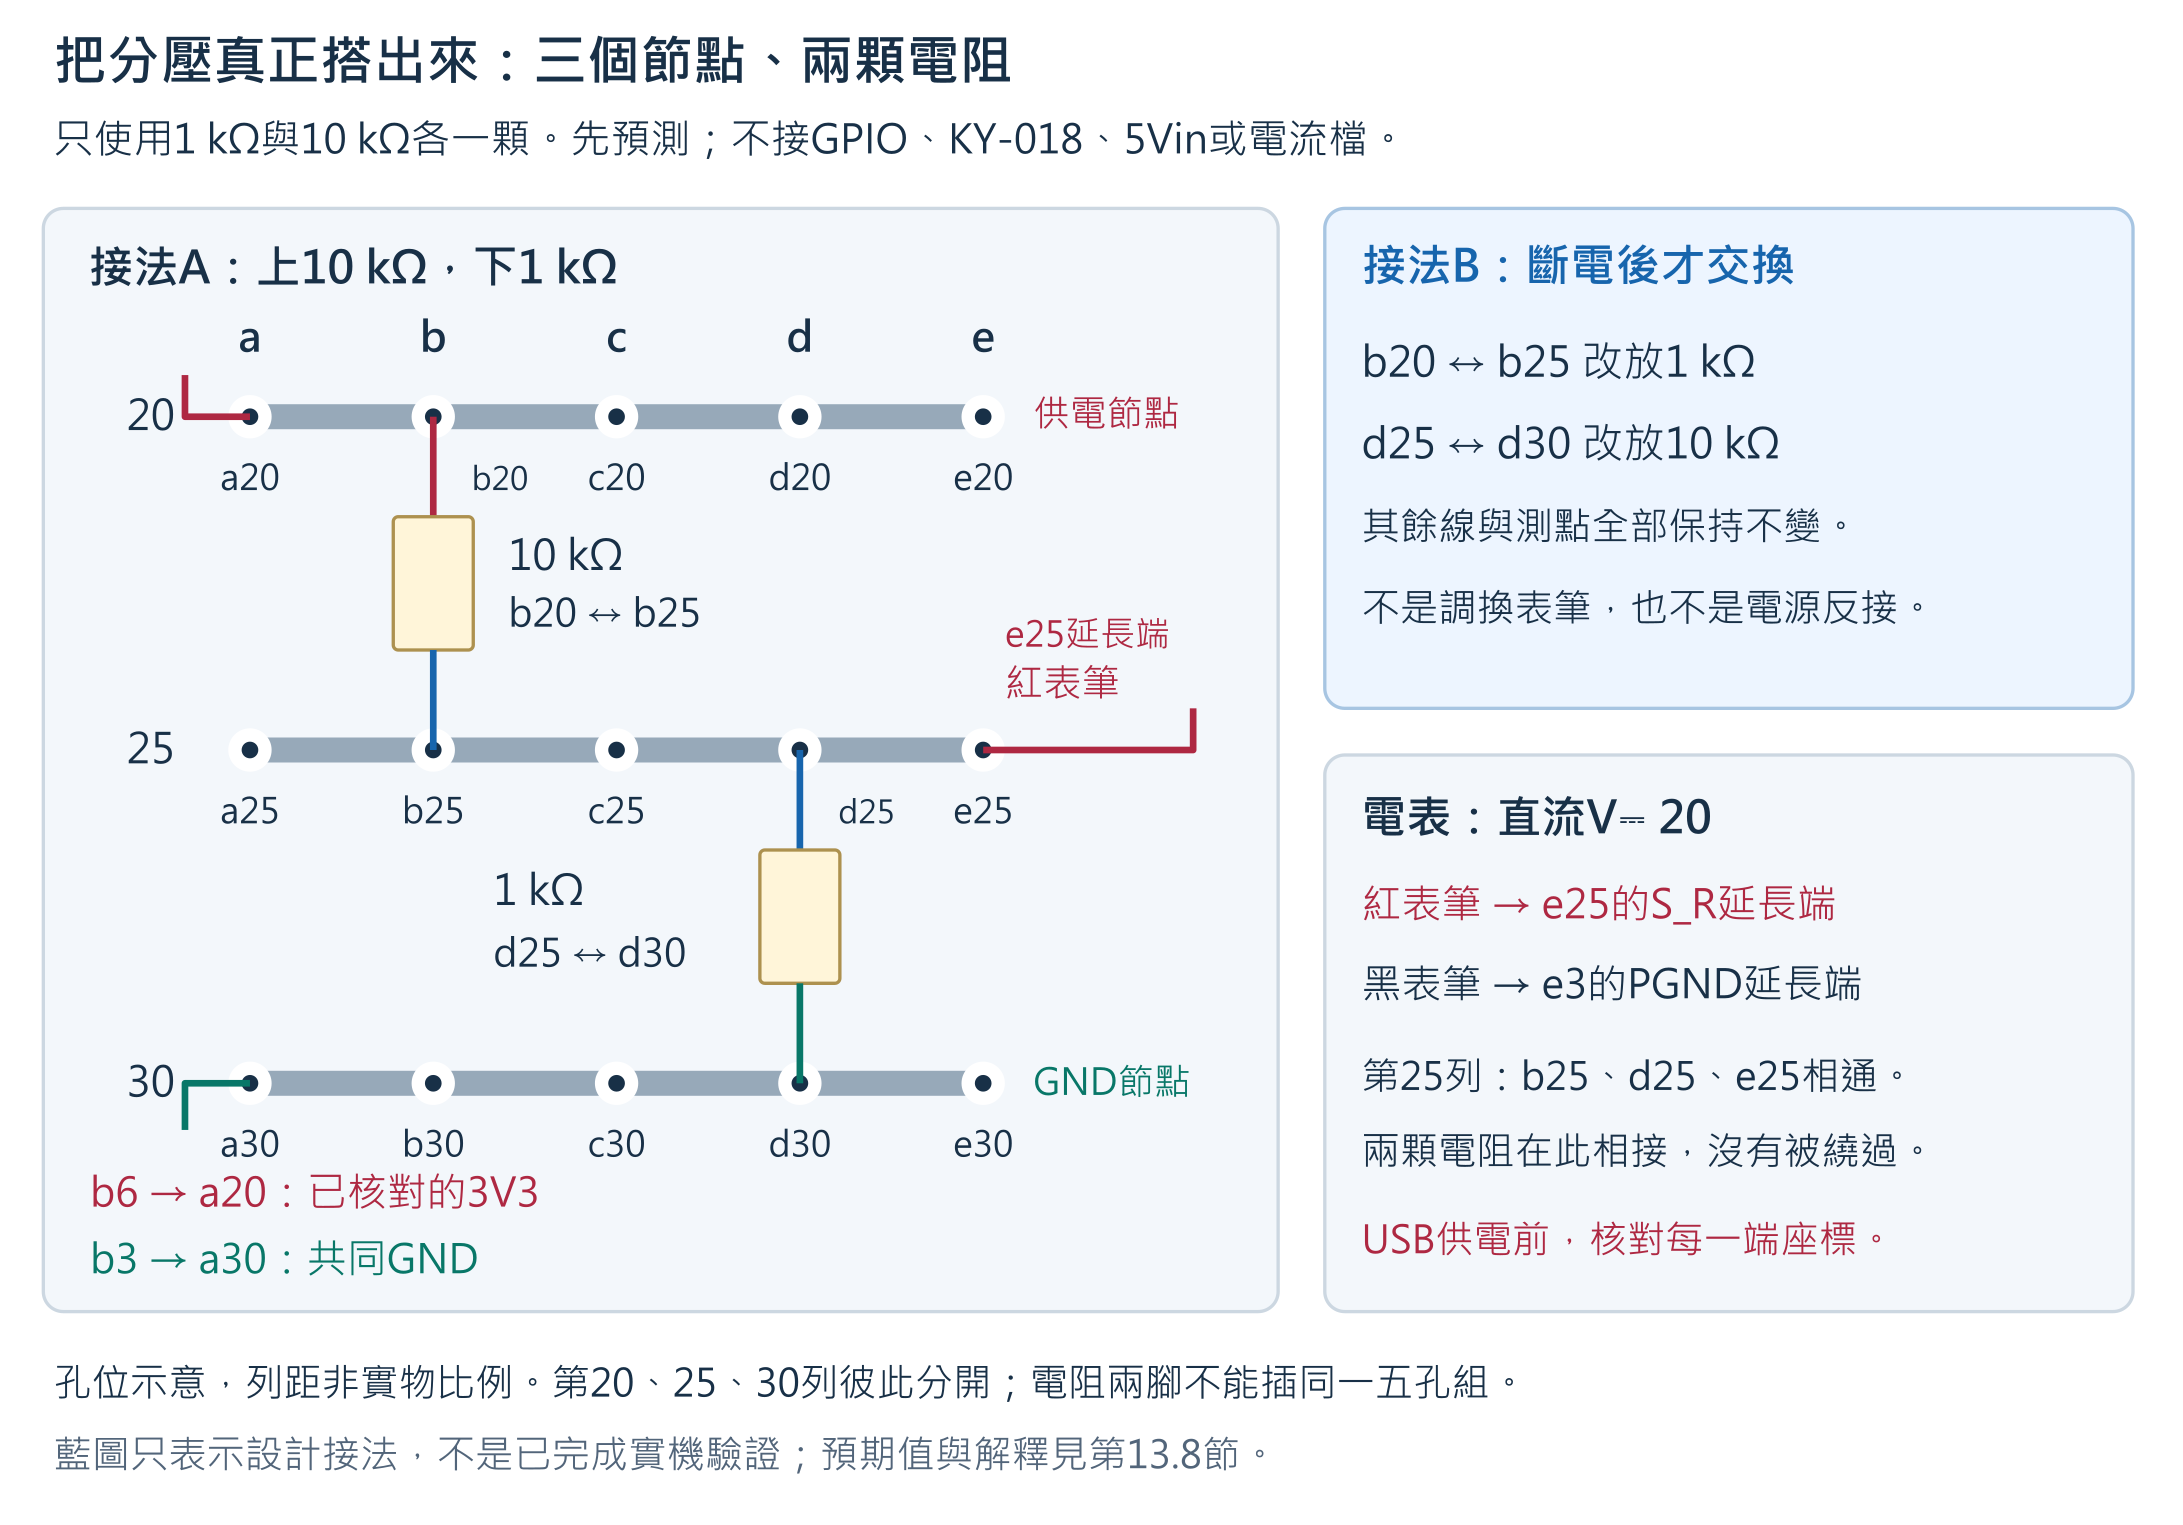

圖中第20、25、30列刻意畫開以利追線，不是實物孔距比例；
電阻長腳需輕彎到合適間距，不得為了符合圖形硬拉。
圖中沒有用導線從第20列直接接第30列，兩顆電阻都必須在路徑中。
先沿圖找b25、d25與e25：它們在同一列，所以共同形成S_R。

現在左半邊a～e形成三個不同接點：第20列是供電、第25列是`S_R`、第30列是GND。
b25、d25、e25同列，所以兩顆電阻與紅表筆測點在這裡相連；
b20和b25不是同一列，不能把電阻兩腳都插在同一個五孔組。

追一次主要電流路徑：

```text
ESP32 3V3 → a6／b6 → a20／b20
          → 10 kΩ → b25／d25
          →  1 kΩ → d30／a30 → b3／a3 → ESP32 GND
```

電流經過兩顆電阻；不是用普通導線把3V3直接短接到GND。
電表則跨在`S_R`與GND之間，量下方電阻的電壓差，不串入主要電流路徑。

上電前依表逐端核對，確認兩顆電阻都在路徑中、沒有裸腳互碰或導線跨接兩個不同接點，
且S_R與PGND自由端分開。若要用電表重新量阻值，須保持斷電並先將元件與其他路徑分離；
不能在仍接著ESP32的3V3／GND之間量Ω，就把讀值直接當成兩顆電阻的總和。

#### 步驟五：上電量接法A

1. 黑表筆插COM、紅表筆插VΩmA，不插10A。A830L轉黑色直流`V⎓ 20`，
   不是Ω 20k，也不是交流V～。
2. 確認沒有手或金屬物碰接點後，接回已驗證的COM側USB。PWR應亮；
   若有異味、發熱、煙或不正常重啟，立刻拔USB，不繼續量。
3. 黑表筆碰PGND延長線的金屬端，紅表筆碰S_R延長線的金屬端。
   只握表筆絕緣處，不移動麵包板接線；單人可先把兩條延長線分開安置再量。
4. 讀值穩定後記下接法A電壓、單位、測點及接觸情況，與自己的預測比較。
   正常極性下，S_R應在GND與實際3V3供電電位之間；參考算式見第13.8節。
5. 若顯示負值，先移開表筆、拔USB，再核對紅／黑測點；不要為了消除負號而交換電源。
   若接近供電端或0 V且不符預測，先同樣斷電查座標、阻值和有無繞過電阻，
   不能直接認定元件壞掉。

Serial可能仍是之前的ADC程式；現在ADC線已拆除，其raw不屬於本題證據，
不用開Monitor，也不要為數字變動而把S_R再接上GPIO。

#### 步驟六：斷電交換兩顆的位置，再量接法B

移開表筆、拔USB、確認PWR熄滅、電表OFF後，才把1 kΩ改插b20／b25，
把10 kΩ改插d25／d30。其他線、電表測點與供電方式保持相同。

這是交換兩顆在電路中的位置，不是交換3V3與GND，也不是只調換表筆。
重新依步驟四核對，依步驟五上電量一次接法B並保存讀值。
不需要再做遮光、收ADC log或重複GPIO LOW／HIGH。

#### 步驟七：用證據解釋，而不是只交兩個數字

完成附錄F2，附上A、B各一張能辨認接線的照片，回答：

1. 實測的大小方向是否符合預測？各引用一筆自己的電壓，不抄參考值。
2. 總電阻相同，為什麼中間點電壓不同？用「下方電阻占總電阻的比例」解釋。
3. 理想3.3 V不一定就是當下的實際供電；阻值有誤差，接觸與電表也會影響讀值。
   用自己的阻值紀錄與先前3V3紀錄討論可能差異，不為追求小數點一致反覆重做。
   若不是同時量得的資料，要保留這項限制。
4. 回到KY-018：本題靠交換位置改變分壓比例，光敏模組則靠什麼改變比例？
   兩者都是直接「量到光」嗎？

完成條件：有兩顆獨立阻值、A／B事前預測、兩筆實測與接線證據，
並能說明比例和至少一項限制。最後移開表筆、拔USB、確認PWR熄滅、電表OFF；
先拆b6→a20供電線，再拆其餘分壓線和兩顆電阻，依標示收納，接續第十五節完整復原。

### 13.8 固定電阻分壓實作參考答案

下列是**理想計算值，不是已完成的實機量測**。
假設供電3.3 V，兩顆恰為1,000 Ω與10,000 Ω，並忽略電表造成的小幅負載影響。

```text
兩種接法的總電阻都是：
R總 = 1,000 Ω + 10,000 Ω = 11,000 Ω

兩種接法的理想電流都是：
I = 3.3 V ÷ 11,000 Ω = 0.0003 A = 0.30 mA
```

不是電阻交換位置後電流就「少掉」；在相同供電、總電阻和可忽略負載的模型下，
整條串聯路徑的電流相同。本題電流由公式計算，沒有用電流檔實測。

| 接法 | 上方電阻 | 下方電阻 | S_R相對GND的計算 | 理想值 |
|---|---:|---:|---|---:|
| A | 10 kΩ | 1 kΩ | 3.3 V × 1／(10＋1) | 0.30 V |
| B | 1 kΩ | 10 kΩ | 3.3 V × 10／(1＋10) | 3.00 V |

從電流再核對一次：A的下方是1,000 Ω，因此0.0003 A × 1,000 Ω＝0.30 V；
B的下方是10,000 Ω，因此0.0003 A × 10,000 Ω＝3.00 V。
紅表筆碰的是下方電阻上端S_R，黑表筆碰下端GND，所以量到這一段的電壓差。

A中，上方10 kΩ兩端是3.30 − 0.30＝3.00 V；B中，上方1 kΩ兩端是3.30 − 3.00＝0.30 V。
兩段電壓差都加回3.30 V，但中間位置相對GND的電位不同。
這也再次說明電阻不是「固定扣掉某個伏特數」的元件。

**為什麼不用把量測硬調成0.30 V與3.00 V？**
例如若實際供電是3.20 V、阻值比例仍為10：1，預期便是約0.291 V與2.909 V；
這只是帶入另一個供電值的計算例子，不是學生實測資料。
更細的比較可代入兩顆獨立量到的阻值，使用
`V_S_R = V供電 × R下／(R上＋R下)`。先前量過的供電不等於本題同時監測的供電，
不能把小差異全部歸因於某一個元件。

**與KY-018的關係：** 本題刻意交換固定阻值的位置；KY-018不交換元件，
而是光敏電阻受光改變，進而改變它占總電阻的比例。
兩者都先形成電壓，電表量電壓差；只有後續接到適當ADC輸入時，才會再得到raw。
本題沒有ADC實測，不能拿0.30 V與3.00 V直接宣稱得到哪個精確raw，更不是lux。

電表的輸入電阻不是無限大，接上後會有負載影響；本題只用電表觀察、以高輸入阻抗近似。
不要把S_R當成可給舵機或模組供電的穩壓電源。
計算與接線文件檢查不能取代實機驗證；新分壓配置的待驗項目保留在硬體狀態紀錄。

#### 步驟三：四個預測小題的預期回答

下表對應第13.7節步驟三，不是另外四題作業。計算假設與本節開頭相同，
都忽略電表的負載影響；實際接觸與供電變化則在實測後討論。

| 原小題 | 預期回答與理由 |
|---|---|
| 總電阻與計算電流是否相同？ | 相同。兩種接法仍由同一顆1 kΩ與同一顆10 kΩ串聯，總和都是11 kΩ；理想3.3 V下都為0.30 mA。交換順序不改變總和。 |
| 紅表筆量S_R、黑表筆量GND，是量哪一顆？ | 量下方電阻兩端。A的下方為1 kΩ，B的下方為10 kΩ；不是量上方，也不是量兩顆的總電壓。 |
| 哪種接法的S_R較高？ | B較高。A的下方占1／11，B占10／11；理想值分別為0.30 V及3.00 V。兩者都低於3.3 V供電。 |
| 哪些不變，刻意改變什麼？ | 保持同兩顆電阻、供電來源、量測檔位、紅表筆量S_R與黑表筆量GND的方式不變；刻意改變兩顆電阻的上下位置。改變後的S_R電壓是要觀察的結果，不是預先調成指定值。 |

這裡的「供電不變」是實驗想控制的條件，不代表已證明USB供電在兩次量測時毫無波動。
同樣地，理想電流相同是模型推論，不是本題已用電流檔證實。

#### 步驟七：四個觀察小題的預期回答

**第1題：實測是否符合預測？**

合理的預期是B的S_R高於A。完整回答須同時有方向、自己的兩筆電壓和比較依據，
不能只填「符合」。可以這樣寫，但空格必須填自己的實測：

> 我在直流20 V檔，以紅表筆量e25的S_R、黑表筆量e3的GND，量到A為____ V、
> B為____ V。在相同測點和供電條件下，B比A____，與原先預測____。
> 我比較的是中間點對GND的電壓，不是電流或ADC raw。

若尚未量測，就寫「理論上預期B較高，實測尚未完成」，不要拿0.30 V與3.00 V代填。
若A、B相近或方向相反，也保留原值，依下方紙上排查表核對，不改寫成符合預期。

**第2題：總電阻相同，為什麼中間電壓不同？**

> 總電阻決定在理想固定供電下的整條串聯電流，但S_R量的是下方那一顆的電壓差。
> 交換後，下方由1 kΩ換成10 kΩ；在相同電流下，`V = I × R`中的R變大，
> 下方分得的電壓就變大。總電壓仍分給兩顆，沒有額外產生電力。

注意分清「兩顆合計」和「紅、黑表筆跨到的那一段」。完整算式就在本節開頭，
不需要再背一套新公式。

**第3題：為何不要求數字剛好等於理想值？**

預期回答至少連到自己的一項紀錄。例如：

- 先前3V3量得約3.20 V，不是理想3.30 V；若阻值比例不變，計算會跟著變成約
  0.291 V與2.909 V。這是前述計算例子，不是新實測。
- 兩顆電阻的獨立實測值若不恰好等於標示，應以實測的上／下阻值代入比例，
  而不是先宣稱電阻壞了。
- 手持測點、表筆接觸、儀表負載或先後量測的條件可能影響結果；
  沒有逐項核對，不能指定其中一個就是已確認原因。

不能自行給所有儀表與材料訂一個未經依據的「差±某個V都算過」規則。
先確認方向與接線；若差異明顯，應提出可追溯的核對，不用反覆調整直到畫面像答案。

**第4題：與KY-018的關係是什麼？**

> 本題是用手把兩個固定阻值交換位置，改變下方占總電阻的比例。
> KY-018不交換位置，而是光敏電阻受光改變阻值，使分壓比例改變。
> 兩者的電表都是量電壓；KY-018接到ADC後才得到raw。不能因此說電表或ADC已直接量得照度。

以上兩種改變方式不同，但「先有電路形成的電壓，再量測」的邏輯相同。

#### 結果不符合預期時，可以怎麼回答

這是第13.7節的判讀參考，**不是要求學生故意搭出故障**。
所有需要碰接線的檢查，都先移開表筆、拔USB、確認PWR熄滅、電表OFF。

| 假設結果 | 可以提出的解釋與安全核對 | 不能直接下的結論 |
|---|---|---|
| A、B幾乎相同 | 斷電確認是否真的把兩顆在電路中的位置互換，而非只把同一顆轉180度；再追紅表筆是否仍量S_R | 不能直接宣布分壓原理不成立 |
| 讀值接近0 V且明顯低於本接法預測 | 斷電查紅、黑測點是否誤接同一節點，S_R是否被導線繞接到GND，以及供電與接觸是否正確 | 不能只憑0 V說整片板子完全沒電或電阻壞掉 |
| 讀值幾乎等於供電且明顯不符預測 | 斷電查是否誤量3V3而非S_R、上方電阻是否被同列接點繞過、下方電阻是否接好；B約3.00 V本身是理想預期，不算此項異常 | 不能先拿更大電阻或改接5Vin試運氣 |
| 出現負值 | 斷電沿線確認紅表筆在S_R、黑表筆在GND；只修正被確認的測點錯置 | 不能交換板上3V3與GND來消除負號 |

#### 附錄F2的預期完成內容

F2應有兩顆獨立阻值、原先A／B預測、兩筆**自己的**實測電壓、
紅黑測點與檔位、兩張實際接線照片，以及上述四題的理由。
照片要能追到3V3、兩顆電阻、S_R與GND；不能用本冊示意圖冒充自己接線的照片。
若還沒拿到電阻或尚未實作，保留「未完成」，不要用參考數字填滿實測欄。

### 13.9 其他課中練習與閱讀檢查的預期回答

本節對應前面已出現的預測、辨認與解釋要求，不增加新實驗、題數或繳交項目。
先回答原題，再依下面的理由自我檢查；完整Discussion四題仍以第13.5節為唯一完整解答，
5 kΩ逐步計算見第13.6節，固定電阻實作見第13.8節。

#### A. 電表功能、量程與數字（對應第三、五節）

預期能回答：「我先決定量什麼，才選檔位；旋鈕印刷顏色不是正負電。」

- 量電阻：被測元件斷電並與其他路徑分離，選Ω檔；讀值帶Ω、kΩ等單位。
- 做通斷檢查：電路斷電，先確認表筆相碰會蜂鳴，再量應連或應分開的點。
  聲音代表符合儀表的導通條件，不代表精確0 Ω。
- 量本週直流電壓：先在斷電時準備線路，選直流V檔；安全上電後，紅表筆量目標、
  黑表筆量GND。Ω檔、直流V檔與電流檔不能互換。

例如同一個20kΩ量程，完整畫面4.80應解讀為4.80 kΩ；200kΩ檔的0.1則是
0.1 kΩ＝100 Ω，兩者不同。最左側單獨的1可能是超量程或開路，
不是一般的1 Ω。若只知道「有聲音、61」，缺少檔位與完整畫面，正確答案是
**目前不足以換算精確電阻**，而不是猜一個單位。各量程範例表保留在第五節。

#### B. 三組KY-018電阻路徑的預測（對應第6.3節）

以第6.3節的`M—固定電阻—S—光敏電阻—−`模型作預測；
自己的模組是否符合此模型，仍須由辨認與斷電量測核對。此模型的預期是：

- M到S大致固定，因為量到固定電阻。
- S到−在遮光時通常增加，因為這段是光敏電阻。
- M到−經過兩顆，應隨光敏路徑改變；相同條件且無額外路徑時，
  其值接近前兩段的和。

理由是元件與路徑，不是「黃色固定、橘色光敏」這類線色對應。
不能把本例直接當作未辨認模組的接線許可。實際三組記錄不精確相加時，
先指出量測先後、光線及接觸的限制；第6.5節就是保留差異、沒有宣稱精密驗證的案例。

#### C. 麵包板節點、電壓方向與5Vin（對應第七、八節）

| 要解釋的事情 | 預期回答 |
|---|---|
| a6換成c6會改變電壓嗎？ | 在已核對的本麵包板，同列a～e相連，換入口仍是同一節點；前提是接觸正常、沒有另接錯線。a6與a3不同列，不能這樣互換。 |
| a15、c15、e15是三個不同訊號嗎？ | 不是。它們是同一S節點的三個入口；f15在中央溝槽另一側，不能因列號相同就當成相通。 |
| 有蜂鳴就一定短路嗎？ | 不一定。同列本來該通；原本應分開的供電與GND若持續蜂鳴，才需要維持斷電追查異常路徑。 |
| 為什麼紅表筆碰3V3、黑表筆碰GND預期是正值？ | 顯示紅點電位減黑點電位。以理想值計算是3.3−0＝+3.3 V；交換測點則0−3.3＝−3.3 V。這是量測方向，不是讓學生反接供電。 |
| 如果兩表筆都碰同一列3V3呢？ | 理想差值3.3−3.3＝0 V；兩點等電位不等於整片板子沒電，也不代表GPIO已執行LOW命令。 |
| USB有供電，就能把本板5Vin當5 V輸出嗎？ | 不能。這片板的5Vin／IN-OUT條件以第八節為準；本週將它辨認為外部輸入，不拿來替模組供電，也不把約0.5 V寫成5 V通過。 |

這些電壓數字是解釋方向的理想例子；實際3V3、測點座標與通斷結果仍填自己的觀察。

#### D. GPIO電壓、Serial與程式（對應第九節）

預期回答是：「程式先發命令，電表再檢查實體電壓；兩者不是同一份證據。」

- `outputHigh=false`選LOW，反轉為true才選HIGH；下一次再反轉則回LOW。
- LOW與HIGH各維持約10秒，是比較毫秒時間差的結果；不是看到`loop()`就每次切換。
- LOW時電表預期接近0 V，HIGH時預期接近3.3 V，但必須同時記錄自己的cycle、
  phase、數值、單位和測點。不能把`expected_voltage`當成電表已讀到的值。
- HIGH若讀到約−3.2 V、LOW為0 V，要先查紅黑測點方向；0 V本身無法區分
  0−0與反向的0−0。不交換ESP32供電線。
- Reset後看到`startup=LOW`，只支持程式進入setup後送出LOW命令；
  無法證明Reset瞬間到setup之前從沒有短脈衝。這項限制也是答案的一部分。

若兩支公開例程仍是`-1`，預期只到安全阻擋，不應填入任何猜測的GPIO答案。

#### E. ADC共同零點閱讀檢查（對應第11.1節）

可以用一句完整的話回答原圖上的兩個位置：

> 被量的位置是S經訊號線送到的ADC輸入；共同零點是模組−與ESP32 GND。
> 晶片內部ADC以這個共同基準讀取輸入，不需要我再拿導線把訊號腳和GND接成同一點。

在圖上指出S→a15／c15→ADC輸入的路徑，以及模組−→c3／a3→ESP32 GND的路徑。
這兩條路徑是在ADC量測功能中一起作用，不是要把它們的自由端短接。
直接用普通導線把S接GND會改變原本分壓，不能再當作正常的光敏訊號量測；
這只作紙上解釋，不實際製造短接。

#### F. raw、時間與Verify摘要的判讀（對應第十二節）

預期能把三種數字分開：

- `sample`是樣本序號，`uptime_ms`是時間，`light_raw`才是ADC整數。
  既有例子兩筆時間188507−188007＝500 ms，也就是0.5秒。
  在每500 ms取樣的設定下，十筆等間隔資料有九段間隔，首尾約4.5秒，不是5秒。
- 12-bit共4096個階級，編號0～4095；raw=696不是0.696 V，也不是696 lux。
  數值變化方向可和電表比較，不能任意移小數點當成精確電壓。
  原理見[Espressif ADC API](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/adc.html)。
- 舊Verify案例的21%相對的是1,310,720-byte程式區上限，不是整顆16 MB Flash；
  6%相對摘要的327,680-byte RAM上限，不是8 MB PSRAM，也不是執行時永遠只用6%。
  兩種百分比不能相加。

兩種光線的升降預測與實測判讀，直接對照第13.5節題目一、二；不另造第二份答案資料。
如果自己的原始範圍重疊，應回答「這批資料不足以清楚分開兩種條件」並說明限制，
不能照抄示範的不重疊結論，也不自行建立Week 4才要處理的門檻。

#### G. 開放式紀錄的答案界線（對應第十五、十六節）

Lab Note沒有一份所有人都應填成相同數字的答案。完整的預期形式是：
**條件與測點 → 原始數據 → 比較結果 → 原因與限制 → 安全復原狀態**。
其中檔位、座標、自己的數值、照片及是否拔USB都必須按實際情況填寫。
沒有完成的欄位寫「尚未量測／尚未確認」，不是用理論值、教材照片或別人的log代替。



<a id="w3-troubleshooting"></a>

## 十四、依症狀排查

| 現象 | 第一個安全檢查 | 接著檢查 | 不要做 |
|---|---|---|---|
| 電阻檔固定顯示`1` | 確認被測物完全斷電 | 表筆接觸、插孔及更高Ω量程 | 把`1`記成1Ω |
| Ω換檔後換算值差很多 | 保持斷電，不更動供電接線 | 相同測點與光線、完整小數點、插孔及接觸 | 把不同單位的數字混算或直接宣稱通過 |
| 表筆相碰仍不接近0Ω | 將電表與電路分開 | 表筆、插孔、旋鈕與電池 | 用未知狀態繼續量板子 |
| 不同測試點持續蜂鳴 | 保持USB拔除 | 逐線拆除並重查五孔組 | 接電看看會不會正常 |
| P3V3接近0V | 移開紅表筆、拔USB | PWR、PGND、實物絲印與導線 | 帶電移線 |
| 電壓出現負號 | 先移開紅表筆 | 黑表筆是否在PGND | 交換板上電源線 |
| GPIO電壓不隨phase改變 | 移開表筆、拔USB | TPO、PGND、profile與上傳版本 | 改用電流檔 |
| 只看到`gpio_profile_missing` | 保持目前接線不變並斷電 | 教師是否已公布profile | 任填一個正整數GPIO |
| KY-018腳位看不清楚 | 不接USB | 補拍絲印近照 | 依照片左右順序猜 |
| 想量S卻一直量到電源電壓 | 移開表筆，改線前先拔USB | 紅表筆是否誤碰e6的3V3白線，而不是S測點 | 因線色而交換模組供電 |
| 手持量測一直跳動 | 移開表筆，需整理導線時先拔USB | 延長端固定、接觸、光線是否同時改變 | 一邊捏裸金屬一邊帶電調線 |
| KY-018 raw固定0或4095 | 先看同條件的訊號電壓 | 斷電後核對signal、3V3、GND | 帶電重插訊號線 |
| raw變化方向與預測不同 | 保留原始log | 光線是否真正固定及測點是否一致 | 交換標籤或改數字 |
| ESP32重啟、發熱或有焦味 | 立即拔ESP32端USB | 拆除模組後回到空板檢查 | 反覆復電 |


<a id="w3-finish"></a>

## 十五、繳交內容、完成檢核與復原

### 繳交內容

1. KY-018三組腳位路徑的量程、畫面、換算值、單位與光線條件。
   第10.6節5 kΩ為計算示例，不另交同類紙上作業。
2. PGND、P3V3與TPO的實際麵包板座標及斷電檢查結果，以及5Vin與IN-OUT絲印辨識。
3. P3V3、三筆GPIO LOW及三筆GPIO HIGH的完整電壓紀錄。
4. GPIO程式版本、Reset後`startup=LOW`在內的完整Serial片段，以及
   「命令／實體電壓」判讀。
5. KY-018可辨認絲印的照片與完整接線俯視照。
6. S未接ADC時的「室內光→遮光→恢復室內光」三筆電壓與判讀；
   接ADC後遮光與室內光的控制方式、訊號電壓、各10筆raw與範圍，共20筆raw。
7. Week 3 Discussion四題的預測、資料比較、紙上排查與最終結論；引用自己的兩組資料及限制。
8. 兩個sketch及Lab Note；不得包含姓名、學號、秘密或無法追溯的GPIO答案。
9. 第13.7節固定電阻分壓的獨立阻值、A／B預測、各一筆電壓、兩張接線照片與比例解釋。

### 完成檢核

- [ ] 能說明通斷、電阻與直流電壓三種量測何時需要斷電或上電。
- [ ] 能用實際電路解釋V、I、R、GND、封閉迴路與短路。
- [ ] 每一筆電表紀錄都有量程、測點、數值與單位，沒有把單獨的1當成一般電阻值。
- [ ] 能解釋兩顆相同串聯電阻為何各分一半電壓，以及10 kΩ為何不固定減掉1.65 V。
- [ ] 能說明BOARD-T01的5Vin是外部輸入，且IN-OUT開路時不是USB 5V輸出。
- [ ] GPIO LOW／HIGH都有電表證據，Reset後啟動命令有Serial證據，且沒有把兩者混為一談。
- [ ] 能說明GPIO命令、實體電壓與ADC raw是不同證據。
- [ ] 能說明中間供電腳、−與S的差別，腳位有絲印、電路與量測依據，不由線色猜。
- [ ] 能正確選擇S及GND測點，分清楚供電反向電壓、S電壓與ADC raw。
- [ ] 能用電表與ADC對照圖指出訊號位置及共同零點，且不把量測誤解成普通導線短接。
- [ ] 能分清Verify的程式分割區用量、靜態RAM摘要，以及Upload成功與實機感測成功。
- [ ] 遮光與室內光各有10筆原始資料，未將單次明暗反應宣稱為精度或校正通過。
- [ ] 沒有把ADC raw寫成V、Ω、lux或永久光線分類。
- [ ] Discussion能以自己的分壓接法、數值與限制，回答數字大小和光線意義的關係。
- [ ] 能安全建立1 kΩ／10 kΩ分壓並斷電交換上下位置，用A／B的實測解釋分壓比例。
- [ ] 所有改線、通斷與電阻量測都在USB拔除後進行。

### 復原順序

1. 儲存sketch、原始log、量測表與照片。
2. 先移開兩支表筆並放下；關閉Serial Monitor，從ESP32端拔除USB，確認`PWR`熄滅。
3. 電表轉`OFF`，才開始拆線。
4. 若固定電阻實作線尚未拆除，先拆b6→a20供電線，再拆其餘分壓線與兩顆電阻；
   若停留在KY-018階段，則先拆模組3V3線，再拆訊號與GND。已拆除者不用重新接回。
5. 拆除仍在板上的P3V3、PGND與其他測試線，依種類收納杜邦線。
6. 電阻依1 kΩ／10 kΩ標示分開收納；分開收納KY-018、ESP32與萬用電表，確認沒有彎針或裸露導線。


<a id="w3-records"></a>

## 十六、附錄：Week 3量測紀錄

### A. 環境與profile

| 項目 | 紀錄 |
|---|---|
| 日期／組別代碼 |  |
| ESP32實物PCB／模組絲印 |  |
| Arduino IDE／ESP32 board package版本 |  |
| Board／Port／Flash／PSRAM設定 |  |
| `PIN_TEST_OUTPUT`及來源 |  |
| `PIN_LIGHT`及來源 |  |
| 萬用電表型號 |  |

### B. 測試點

| 標籤 | 麵包板五孔組座標 | ESP32或模組端點 | 斷電通斷結果 |
|---|---|---|---|
| PGND |  | GND |  |
| P3V3 |  | 3V3 |  |
| 5Vin辨識 | 不建立測試點 | 外部5 V輸入；USB供電時不作5 V輸出 | 不適用 |
| TPO |  | GPIO測試輸出；改做KY-018前拆除 |  |
| S |  | 光敏模組訊號；ADC階段使用第15列 |  |

三組不同節點的斷電檢查（第七節）：
PGND↔P3V3：________；PGND↔TPO：________；P3V3↔TPO：________。
記錄的是有無持續蜂鳴及接觸狀態，不由聲音直接填入未量過的Ω值。

### C. KY-018斷電電阻

M是第六節對未標示中間排針的暫稱；依自己的實物記錄，不由位置猜成電源腳。

| 測點 | 光線條件 | Ω量程 | 完整畫面 | 換算值與單位或狀態 | 判讀 |
|---|---|---|---:|---|---|
| S與− | 室內光 |  |  |  |  |
| S與− | 遮光 |  |  |  |  |
| S與− | 恢復室內光 |  |  |  |  |
| S與M | 室內光 |  |  |  |  |
| S與M | 遮光 |  |  |  |  |
| S與M | 恢復室內光 |  |  |  |  |
| M與− | 室內光 |  |  |  |  |
| M與− | 遮光 |  |  |  |  |
| M與− | 恢復室內光 |  |  |  |  |

量測順序、模組方向與遮光方式：____________________________________________

阻值相加的預測、實際差異與限制：__________________________________________

跨量程或接觸異常及安全核對結果：__________________________________________

### C2. 分壓計算示例筆記（不另交作業）

供電3.3 V、固定電阻10 kΩ、光敏電阻5 kΩ；維持第10.6節的上下位置。

S電壓升高／降低的事前預測與理由：________________________________________

總電阻、電流、兩顆電阻的電壓差及各自單位：________________________________

供電端、S與GND的電位；總和與比例檢查：____________________________________

以上是計算，不能填入下方的實測電壓欄。

### D. 直流電壓

| 項目 | 供電／phase | 黑表筆 | 紅表筆 | 檔位 | 實測值與單位 |
|---|---|---|---|---|---:|
| P3V3 | USB供電 | PGND | P3V3 | `V⎓ 20` |  |
| GPIO LOW 1 |  | PGND | TPO | `V⎓ 20` |  |
| GPIO HIGH 1 |  | PGND | TPO | `V⎓ 20` |  |
| GPIO LOW 2 |  | PGND | TPO | `V⎓ 20` |  |
| GPIO HIGH 2 |  | PGND | TPO | `V⎓ 20` |  |
| GPIO LOW 3 |  | PGND | TPO | `V⎓ 20` |  |
| GPIO HIGH 3 |  | PGND | TPO | `V⎓ 20` |  |

Reset後Serial啟動文字：__________________________________________________

### D2. S尚未接ADC時的電壓

USB供電、電表直流20 V；先寫出表筆實際測點，填自己的讀值，不抄第10.11節案例。

黑表筆接：________________　紅表筆接：________________

| 先後 | 光線條件 | 實測V | 接觸或光線限制 |
|---|---|---:|---|
| 1 | 室內光 |  |  |
| 2 | 遮光 |  |  |
| 3 | 恢復室內光 |  |  |

升高／降低的觀察與能支持的結論：__________________________________________

### E. KY-018原始資料

| 光線條件 | 固定方式 | 訊號電壓 | 10筆raw原始範圍 | raw上升／下降／不確定 |
|---|---|---:|---|---|
| 遮光 |  |  |  |  |
| 室內光 |  |  |  |  |

兩種光線各10筆，共20筆原始log直接貼在下方，不只抄min與max：

```text
遮光：

室內光：
```

### F. Discussion結論

題目一：分壓接法圖、事前預測與理由：______________________________________

題目二：引用附錄E兩組數據的比較與判讀：__________________________________

題目三：假設情境的兩項安全核對與判斷依據：________________________________

題目四：數字變大是否代表較亮；本片結果、原因與限制：______________________

### F2. 固定電阻分壓實作

| 元件包裝標示 | 獨立量測檔位 | 完整畫面 | 換算值與單位 |
|---|---|---|---|
| 1 kΩ |  |  |  |
| 10 kΩ |  |  |  |

| 接法 | 事前預測V與理由 | 實測S_R相對GND／V | 檔位、紅／黑測點 | 接線照片位置 |
|---|---|---|---|---|
| A：上10 kΩ、下1 kΩ |  |  |  |  |
| B：上1 kΩ、下10 kΩ |  |  |  |  |

總電阻與計算電流是否相同；S_R為何不同：____________________________________

與KY-018的相同概念、不同變因及本次限制：__________________________________

交換前斷電／完成後復原紀錄：______________________________________________

### G. Lab Note摘要

| 欄位 | 紀錄 |
|---|---|
| 已完成的文件／compile／target／physical test層級 |  |
| 實際電壓與ADC範圍 |  |
| 異常、第一個安全檢查與結果 |  |
| 尚未驗證的項目 |  |
| Git commit |  |


## 參考資料

- [Espressif Arduino-ESP32 ADC API](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/adc.html)
- [Espressif ESP32-S3 datasheet](https://www.espressif.com/sites/default/files/documentation/esp32-s3_datasheet_en.pdf)
- [Fluke：通斷測試原則與依機型判讀](https://www.fluke.com/en-us/learn/blog/digital-multimeters/how-to-test-for-continuity)
- [Arduino：Memory Guide](https://docs.arduino.cc/learn/programming/memory-guide/)
- [Fluke：歐姆定律與電壓、電流、電阻的關係](https://www.fluke.com/en-us/learn/blog/electrical/what-is-ohms-law)
- [Fluke：電阻量測與斷電、隔離注意事項](https://www.fluke.com/en-ie/learn/blog/digital-multimeters/how-to-measure-resistance)
- [Analog Devices：Voltage Divider](https://www.analog.com/en/resources/glossary/voltage-divider.html)
- [Joy-IT KY-018 Photoresistor：功能、工作電壓與腳位](https://sensorkit.joy-it.net/en/sensors/ky-018)
- [YD-ESP32-S3 exact-board IN-OUT說明與pinout](https://github.com/profharris/YD-ESP32-S3_ESP32-S3-WROOM-1_Dev#notes-in-out-usb-otg-solder-jumper-pads)
- [Week 2～6硬體教材藍圖](../../docs/course_materials/hardware_course_material_plan.md)
- [跨電腦硬體狀態](../../docs/hardware/hardware_state.md)

Espressif官方文件支持ADC API、解析度、量測範圍與GPIO類比功能；exact-board資料與
BOARD-T01實物支持5Vin／IN-OUT判讀。本教材的PGND、P3V3、TPO名稱、操作順序、
Discussion及紀錄表是本課為初學者設計的教學改寫。分壓計算例子由歐姆定律與
所述串聯電路條件推導，不是官方公布的固定實測值；第六節及第10.11節的實際觀察
案例分別保留電阻與S電壓回報的限制，不能當成尚未執行的ADC或校正結果。
